# UCKG Knowledge Graph Analysis
* Peyton Bubert
* CID: 81409641
* Email: pbubert@angelo.edu

The following notebook contains an indepth analysis of the UCKG knowledge graph. THe UCKG knowledge graph is a neo4j created graph that contains multiple databases related to cybersecurity and attacks and connects them in a series of node sets. Each different node type contains data from valuable datasets that help to explain vulnerabilities, affected publishers, weaknesses, attacks, and more. This workbook will walk through the knowledge graph and peform individual analysis on specific nodes and their properties along with describing relationships with other nodes and how their datasets can connect.

Below is an outline of the structure of this workbook:

- Workbook Setup
- Knowledge Graph Overview
- CVEs Analysis 
- - CVE Properties 
- - CVE Relationships 
- CPEs 
- - CPE Properties 
- - CPE Relationships 
- CWEs 
- - CWE Properties 
- - CWE Relationships 
- CAPECs 
- - CAPEC Properties 
- - CAPEC Relationships 
- Mitre Nodes 
- - Mitre Nodes Overview 
- - UcoexMITREATTACK 
- - UcoexMITREDEFEND 
- - UcoexSOFTWARE 
- - UcoexTACTICS 
- - UcoexMITIGATIONS
- - UcoexGROUPS 
- - UcoexCAMPIGNES 
- - UcoexTACTICS
- - MITRE EXTENSIVE ANALYSIS
- UCKG Data Science Analysis: Trends of Operating System Vulnerabilities
- - Raw Data and Data Cleanup
- - Exploration
- - Regression
- - Evaulate
- - Learning
- - Decision Trees
- - Conclusion

Important note is that this Analysis uses version 2.0 of the knowledge graph.

# <a id="#workbook-setup"></a>Workbook Setup

The following section focuses on setting up the notebook to be used for analysis. This involves connecting to the neo4j knowledge graph, importing vital libraries, and creating any functions that will be utilized for the workbook.

This workbook requires a series of libraries to work, including matplotlib for creating graphs and pandas for storing knowledge graph data into dataframes.

It then Creates a connection to the database through the local host. This section performs a test on the connection to make sure that the connection both works and is stable.

Finally, the main function that will run the queries is created. This function takes the driver that has connected to the databases and is called any time a cypher query is executed.

In [1]:
#install needed libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
from neo4j import GraphDatabase

#connect to the database and estabilish that connection was successful
URI = "bolt://localhost:7687"
AUTH = ("neo4j","abcd90909090")

try:
    with GraphDatabase.driver(URI, auth=AUTH) as driver:
        driver.verify_connectivity()
        print("Connection established.")
except Exception as e:
    print("Error connecting to neo4j")
    print(e)

#define functions to use
#run_query attempts to run any query given to it
def run_query(query, parameters= None):
    try:
        with driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]
    except Exception as e:
        print(f"Error running query: {e}")
        return []

Connection established.


# Knowledge Graph Overview

The knowledge graph is a complex structure that is made up of various types of nodes, with each providing specific information. This section will breatdown the overall structure and relationship of the graph as a whole.

The following information is also listed in the following schema. It lists the properties of each node and all relationships currently present in the graph. The overview below references this schema in its analysis:
[schema_cache](https://github.com/edogdu/UCKG/blob/qa-engine/qa-engine/shared/schema_cache.txt)

In total there exists 14 different types of nodes in the graph. Each of these nodes provide specific information about vulnerabilities, weaknesses, attacks, and more. Several of these nodes will be investigated in depth later into this analysis


In [2]:
#finding the total amount of nodes in the graph
count = """
    MATCH (n)
    WHERE labels(n)[1] CONTAINS 'Uco'
    RETURN labels(n)[1] as Node, COUNT(n) as Node_Count
    ORDER BY Node_Count DESC
"""

params = {}
count = run_query(count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Node,Node_Count
0,UcoCVE,308297
1,UcoVulnerability,308297
2,UcoexCPE,138459
3,UcoexObservedExample,3023
4,UcoExploitTarget,969
5,UcoCWE,969
6,UcoexMITREATTACK,884
7,UcoexSOFTWARE,877
8,UcoexCAPEC,559
9,UcoexMITRED3FEND,248


|         Node         |        Database Origin          | Node Count |
|----------------------|---------------------------------|------------|
| UcoCVE               | National Vulnerability Database | 308297     |
| UcoVulnerability     | National Vulnerability Database | 308297     |
| UcoexCPE             | National Vulnerability Database | 138459     |
| UcoexObservedExample | National Vulnerability Database |   3023     |
| UcoExploitTarget     | National Vulnerability Database |    969     |
| UcoCWE               | MITRE ATT&CK |    969     |
| UcoexMITREATTACK     | MITRE ATT&CK                    |    884     |
| UcoexSOFTWARE        | MITRE ATT&CK                    |    877     |
| UcoexCAPEC           | MITRE CAPEC                     |    559     |
| UcoexMITRED3FEND     | MITRE ATT&CK                    |    248     |
| UcoexGROUPS          | MITRE ATT&CK                    |    170     |
| UcoexMITIGATIONS     | MITRE ATT&CK                    |    108     |
| UcoexCAMPAIGNS       | MITRE ATT&CK                    |     50     |
| UcoexTACTICS         | MITRE ATT&CK                    |     38     |


Each node contains its own set of specific properties that describe the node and any recources it has. Below shows the list of all properties for each node

In [3]:
#finding the total amount of nodes in the graph
count = """
    MATCH (n)
    WHERE labels(n)[1] CONTAINS 'Uco'
    UNWIND keys(n) as Properties
    RETURN DISTINCT Properties, labels(n)[1] as Node
"""

params = {}
count = run_query(count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df = df.groupby('Node')['Properties'].agg(lambda x: ', '.join(x)).reset_index()

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Node,Properties
0,UcoCVE,"embedding, embedding_processed, ucovectorStrin..."
1,UcoCWE,"ucopotentialMitigations, ucocweSummary, ucodes..."
2,UcoExploitTarget,uri
3,UcoVulnerability,"ucopublishedDateTime, embedding, embedding_pro..."
4,UcoexCAMPAIGNS,"ucoexDESCRIPTION, ucoexURL, ucoexDOMAIN, ucoex..."
5,UcoexCAPEC,"ucoexRelatedAttPattern, uri, ucoexMitigations,..."
6,UcoexCPE,"cpeName, dictionary_found, uri, lastModified, ..."
7,UcoexGROUPS,"ucoexDOMAIN, ucoexDESCRIPTION, ucoexNAME, uri,..."
8,UcoexMITIGATIONS,"ucoexURL, ucoexDOMAIN, ucoexDESCRIPTION, ucoex..."
9,UcoexMITREATTACK,"ucoexDESCRIPTION, ucoexNAME, uri, ucoexURL, uc..."


In total, 16 different relationships exist in the knowledge graph. Relationships are what connect the nodes to each other and allow for complex analysis between two or more nodes. Below displays the different types of relationships, the connected nodes, and the total count.

An important thing to note is that only 13 of the 14 available nodes contain relationships. UcoexTACTICS is the only node that does not contain any relationships to any other nodes in the graph, therefore it does not appear below.

In [4]:
#finds the total amount of relationships in the graph
count = """
    MATCH (n)-[r]->(m)
    WHERE labels(n)[1] CONTAINS 'Uco' AND labels(m)[1] CONTAINS 'Uco'
    RETURN labels(n)[1] as Starting_Node, type(r) as Relationship, labels(m)[1] as Related_Node, COUNT(r) as Relationship_Count
    ORDER BY Relationship_Count DESC
"""

params = {}
count = run_query(count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Starting_Node,Relationship,Related_Node,Relationship_Count
0,UcoCVE,UCOEXHASCPE,UcoexCPE,663925
1,UcoVulnerability,UCOHASCVE_ID,UcoCVE,308297
2,UcoExploitTarget,UCOHASVULNERABILITY,UcoVulnerability,244381
3,UcoexSOFTWARE,UCOEXSOFTWAREUSESTECHNIQUE,UcoexMITREATTACK,11514
4,UcoexGROUPS,UCOEXGROUPUSESTECHNIQUE,UcoexMITREATTACK,4095
5,UcoCWE,UCOHASOBSERVEDEXAMPLE,UcoexObservedExample,3023
6,UcoexObservedExample,UCOEXEXAMPLEOBSERVEDIN,UcoCVE,3011
7,UcoexMITIGATIONS,UCOEXMITIGATES,UcoexMITREATTACK,1915
8,UcoexCAPEC,UCOEXHASRELATEDWEAKNESS,UcoCWE,1212
9,UcoexGROUPS,UCOEXGROUPUSESSOFTWARE,UcoexSOFTWARE,1064


In [5]:
count = """
    MATCH (n)-[r]-(m)
    WHERE labels(n)[1] CONTAINS 'Uco' AND labels(m)[1] CONTAINS 'Uco'
    RETURN labels(n)[1] as Node, type(r) as Relationship, labels(m)[1] as Related_Node, COUNT(r) as Relationship_Count
"""

params = {}
count = run_query(count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

feature_matrix = df.pivot_table(index='Related_Node', columns='Node', values='Relationship_Count', aggfunc='sum').fillna(0)
feature_matrix = feature_matrix.fillna(0).astype(int)


node_count = [308297, 969, 969, 308297, 50, 559, 138459, 170, 108, 884, 248, 3023, 877]
feature_matrix['Node_Count'] = node_count
cols = list(feature_matrix.columns)
cols.insert(0, cols.pop(cols.index('Node_Count')))
feature_matrix = feature_matrix[cols]
feature_matrix


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Node,Node_Count,UcoCVE,UcoCWE,UcoExploitTarget,UcoVulnerability,UcoexCAMPAIGNS,UcoexCAPEC,UcoexCPE,UcoexGROUPS,UcoexMITIGATIONS,UcoexMITREATTACK,UcoexMITRED3FEND,UcoexObservedExample,UcoexSOFTWARE
Related_Node,,,,,,,,,,,,,,
UcoCVE,308297,0,0,0,308297,0,0,663925,0,0,0,0,3011,0
UcoCWE,969,0,0,969,0,0,1212,0,0,0,0,0,3023,0
UcoExploitTarget,969,0,969,0,244381,0,0,0,0,0,0,0,0,0
UcoVulnerability,308297,308297,0,244381,0,0,0,0,0,0,0,0,0,0
UcoexCAMPAIGNS,50,0,0,0,0,0,0,0,24,0,1009,0,0,144
UcoexCAPEC,559,0,1212,0,0,0,0,0,0,0,271,0,0,0
UcoexCPE,138459,663925,0,0,0,0,0,0,0,0,0,0,0,0
UcoexGROUPS,170,0,0,0,0,24,0,0,0,0,4095,0,0,1064
UcoexMITIGATIONS,108,0,0,0,0,0,0,0,0,0,1915,0,0,0


# CVEs Analysis

CVEs are basic reports about vulnerabilities, including basic information regarding vulnerabilities including severity, ability ro gain administrator access, needing user interaction, and more. This will be the basic starting point for the analysis.

CVEs contain one of the larger datasets present in the knowledge and its important to have an idea of how many CVE nodes are currently present in the knowledge graph.

In [6]:
#runs a query to see how many CVEs are currently in the knowledge graph
CVE_count = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count
"""

params = {}
count = run_query(CVE_count, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count
0,308297


## CVE Properties

CVE nodes contain several valuable properties that describe each of the CVE entries. This section will analyze the properties individually and together.

| **Property Name**            | **Description**                                                                       |
| ---------------------------- | ------------------------------------------------------------------------------------- |
| `ucoevaluatorSolution`       | Description of solutions or fixes (e.g., patches, workarounds) for the CVE.           |
| `uri`                        | Unique URI identifier (may be used as the resource's RDF URI in linked data).         |
| `ucouserInteractionRequired` | Boolean indicating if user action is required to exploit the vulnerability.           |
| `ucobaseSeverity`            | Qualitative severity rating (e.g., "Low", "Medium", "High") based on CVSS.            |
| `ucovulnStatus`              | Status of the CVE in the disclosure process (e.g., "Analyzed", "Deferred").           |
| `label`                      | General label for the node (could be `CVE-yyyy-xxxx` identifier or node label).       |
| `ucoobtainAllPrivilege`      | Boolean; `true` if exploiting the CVE gives full system/administrator access.         |
| `ucovectorString`            | CVSS vector string (e.g., `AV:N/AC:L/PR:N/...`) describing how the score was derived. |
| `ucoexploitabilityScore`     | Numeric score (0.0–10.0) representing how easy it is to exploit the CVE.              |
| `ucoimpactScore`             | Numeric score (0.0–10.0) representing the potential damage if exploited.              |

The label of the CVE contains important information that can be used to analyze the nodes. The label if the CVE is divided as follows:

CVE - (year) - (id)

Year will give the year the CVE was reported by a four digit number. Using this section of the label, we can see how many CVEs were created each year. Based on the created bar graph, there has been a stark increase in created CVEs per year starting around 2017.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


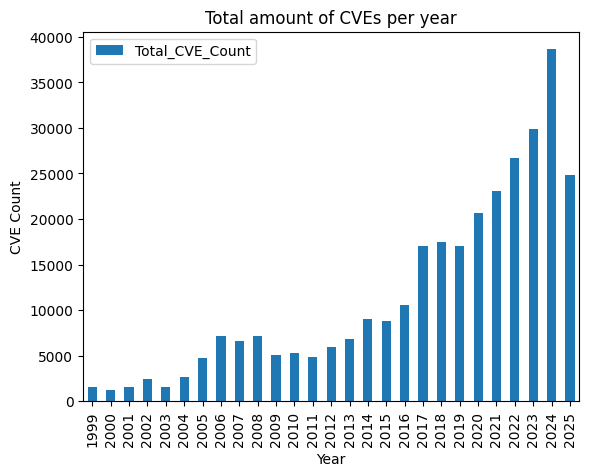

In [7]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df
df.plot(x='Year', y='Total_CVE_Count', kind='bar')
plt.title('Total amount of CVEs per year')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()


something to also note is the severity of each CVEs. CVEs with higher scores in their severity ranking are considered much more dangerous and there is more effort to address those reports.

Overall the severity is important to analyze, but its also important to see how many reports of each severity happened each year. Overall CVEs were usually listed as Medium severity, with High severity following not too far behind. Very rarely were CVEs ranked as low.

It was noticed that in the recent years, severity scores along with impact and expolitability scores were left blank. The following chart visualizes the amount of CVEs each year that have an empty field for severity. This likely reason is that the NVD scoring is being outsourced and it may be possible that they arr not reporting Severity in a different JSON output that the graph is not equipped to handle.

In [8]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, n.ucobaseSeverity as Severity
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count,Severity
0,59373,HIGH
1,109893,MEDIUM
2,19930,LOW
3,119101,


These severity values can be compared to the year of the CVE to find trends with the CVE data. Below shows a bargraph that displays the severity of CVE nodes for each year.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


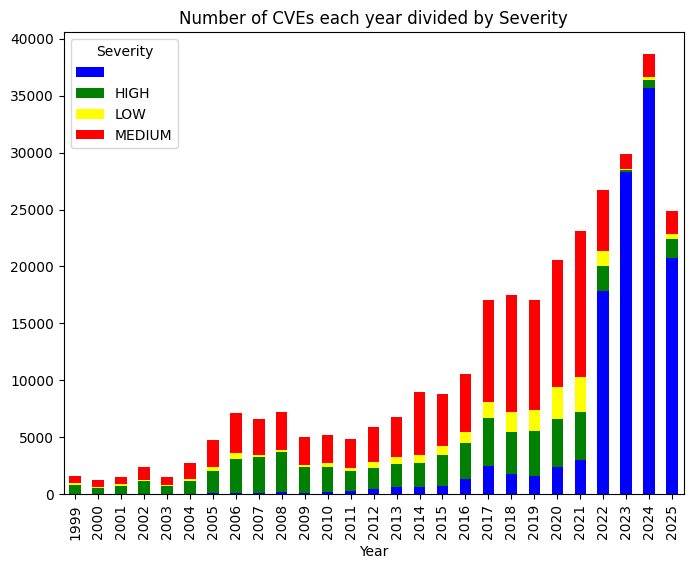

In [9]:
#makes a more detailed bar graph showing the amount of severity counts each year
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Severity', values = 'Total_CVE_Count')
pivot

colors = ['Blue', 'Green', 'Yellow', 'Red']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by Severity')
plt.show()

The severity ranking is calculated using two other properties: UcoImpact and UcoExpolitability. UcoImpact presents how severe the consequences of the vulnerability, if expolited, would be. UcoExpolitability displays how easy it would be for an attacker to exploit the CVE. Below shows the counts of each ranking for both Impact and Expolitability and what their rankings mean. 

In [10]:
query = """
MATCH (n:UcoCVE)
RETURN n.ucoimpactScore AS ImpactScore, count(*) AS Count
ORDER BY ImpactScore DESC
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,ImpactScore,Count
0,9.5,49
1,9.2,496
2,8.5,404
3,7.8,256
4,6.9,7409
5,6.4,60062
6,4.9,9652
7,2.9,79793
8,10.0,31053
9,0.0,22


| **Impact Score Range** | **Severity Category** | **Representative Scores in Data** | **Total Count** |
| ---------------------- | --------------------- | --------------------------------- | --------------- |
| 9.0 – 10.0             | Critical Impact       | 10.0, 9.5, 9.2                    | 31,598          |
| 6.0 – 8.9              | High Impact           | 8.5, 7.8, 6.9, 6.4                | 68,131          |
| 4.0 – 5.9              | Moderate Impact       | 4.9                               | 9,652           |
| 1.0 – 3.9              | Low Impact            | 2.9                               | 79,793          |
| 0.0                    | No Impact             | 0.0                               | 22              |
| *(Missing)*            | Unknown               | `[]`                              | 119,101         |


In [11]:
query = """
MATCH (n:UcoCVE)
RETURN n.ucoexploitabilityScore AS ExploitabilityScore, count(*) AS Count
ORDER BY ExploitabilityScore
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,ExploitabilityScore,Count
0,,119101
1,1.2,13
2,1.5,123
3,1.9,663
4,10.0,67035
5,2.0,4
6,2.2,5
7,2.5,113
8,2.7,161
9,3.1,756


| **Exploitability Score Range** | **Severity Category** | **Representative Scores in Data**         | **Total Count** |
| ------------------------------ | --------------------- | ----------------------------------------- | --------------- |
| `9.0 – 10.0`                   | Very Easy to Exploit  | 10.0, 8.6, 8.0                            | 142,885         |
| `6.0 – 8.9`                    | Easy to Exploit       | 6.8, 6.5, 6.4                             | 11,940          |
| `4.0 – 5.9`                    | Moderate Effort       | 5.5, 5.1, 4.9, 4.4, 4.1                   | 6,898           |
| `1.0 – 3.9`                    | Hard to Exploit       | 3.9, 3.4, 3.2, 3.1, 2.7, 2.5, 2.2, 2.0... | 27,473          |
| `0.0`                          | Not Exploitable       | 0.0                                       | 0 (not shown)   |
| *(Missing)*                    | Unknown               | `[]`                                      | 119,101         |

One of the more important properties is ObtainAllPrivilege. This property allows for an attacker to gain full administrator access to a device or an application. Its important to see if these types of vulnerabilities are becoming more common

Something unusual is that the number of CVEs that allowed for full administrator access has actually increased. The year where the most of theses types of vulnerabilities were reported was in 2007, with 998 total vulnerabilities allowing for admin access. The most recent reports of these types of vulnerabilities was in 2022. Since then there has not been a reported instance of a vulnerability allowing full privilege access. 


In [12]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, n.ucoobtainAllPrivilege as Access
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   Total_CVE_Count Access
0           303072  false
1             5225   true


| **ObtainAllPrivilege** | **Meaning**                                                                                       | **Count** |
| ---------------------- | ------------------------------------------------------------------------------------------------- | --------- |
| `false`                | The vulnerability **does not** allow an attacker to gain **all system privileges**                | 303,072   |
| `true`                 | The vulnerability **does** allow an attacker to obtain **complete privileges** (e.g., root/admin) | 5,225     |

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


    Total_CVE_Count  Year Access
0              1136  1999  false
1               443  1999   true
2               314  2000   true
3               928  2000  false
4              1257  2001  false
5               299  2001   true
6              2080  2002  false
7               313  2002   true
8              1322  2003  false
9               233  2003   true
10              434  2004   true
11             2273  2004  false
12             4515  2005  false
13              254  2005   true
14             6637  2006  false
15              506  2006   true
16              998  2007   true
17             5582  2007  false
18              736  2008   true
19             6441  2008  false
20             4769  2009  false
21              280  2009   true
22             5094  2010  false
23              150  2010   true
24             4873  2011  false
25               13  2011   true
26             5920  2012  false
27               17  2012   true
28             6810  2013  false
29        

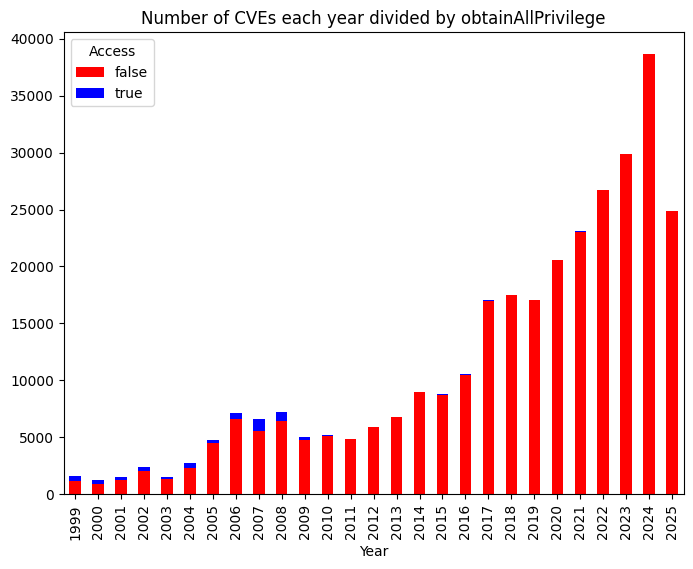

In [13]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucoobtainAllPrivilege as Access
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Access', values = 'Total_CVE_Count')
print(pivot)

colors = ['Red', 'Blue']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by obtainAllPrivilege')
plt.show()

Another important factor that CVEs list is if the vulnerability requires action from the affecter user before an attack can expolit it. Vulnerabilities that do not have this requirement are far more dangerous as it removes a barrier that attackers must break before they can expolit. The query below finds the amount of CVEs each year divided based on user interaction.

A disturbing trend is seen here as the amount of vulnerabilities that are able to expolit without user interaction have been increasing.

In [14]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, n.ucouserInteractionRequired as Interaction
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Total_CVE_Count,Interaction
0,253184,false
1,55113,true


| **Interaction Required** | **Meaning**                                                                                      | **Count** |
| ------------------------ | ------------------------------------------------------------------------------------------------ | --------- |
| `false`                  | **No user action is needed** — the exploit can be triggered automatically                        | 253,184   |
| `true`                   | **User action is required** — the attacker needs the victim to interact (e.g., click, open file) | 55,113    |

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Interaction    false    true
Year                        
1999          1531.0    48.0
2000          1200.0    42.0
2001          1531.0    25.0
2002          2331.0    62.0
2003          1478.0    77.0
2004          2600.0   107.0
2005          4537.0   232.0
2006          6481.0   662.0
2007          5196.0  1384.0
2008          5247.0  1930.0
2009          3330.0  1719.0
2010          3363.0  1881.0
2011          3276.0  1610.0
2012          4237.0  1700.0
2013          5170.0  1649.0
2014          5517.0  3482.0
2015          6150.0  2616.0
2016          7170.0  3390.0
2017         11115.0  5908.0
2018         11541.0  5954.0
2019         11949.0  5085.0
2020         14687.0  5920.0
2021         16307.0  6769.0
2022         23862.0  2861.0
2023         29854.0     NaN
2024         38639.0     NaN
2025         24885.0     NaN


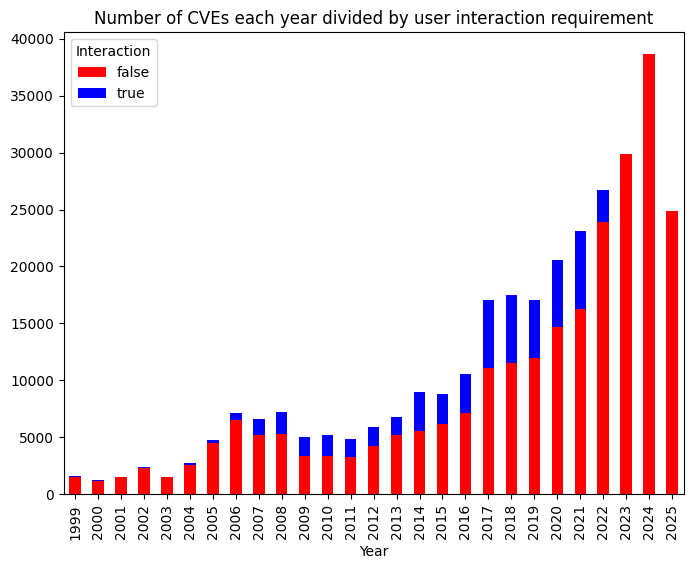

In [15]:
query = """
    MATCH (n:UcoCVE)
    RETURN count(DISTINCT n) as Total_CVE_Count, split(n.label, '-')[1] as Year, n.ucouserInteractionRequired as Interaction
    ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Interaction', values = 'Total_CVE_Count')
print(pivot)

colors = ['Red', 'Blue']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year divided by user interaction requirement')
plt.show()

The status of the CVE is recorded in the property ucovulnStatus. This property records the current state of the CVE as these reports must be recieved, reviewed, and validated. Below divides the CVEs by their current status and further explain what each rank means

In [16]:
query = """
MATCH (n:UcoCVE)
RETURN n.ucovulnStatus AS Status, count(*) AS Count
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Status,Count
0,Deferred,94588
1,Analyzed,36137
2,Modified,135261
3,Awaiting Analysis,25848
4,Rejected,15794
5,Undergoing Analysis,491
6,Received,178


| **Status**            | **Count** | **Meaning**                                                            |
| --------------------- | --------- | ---------------------------------------------------------------------- |
| `Modified`            | 135,261   | The CVE has been reviewed and updated, usually with improved metadata. |
| `Deferred`            | 94,588    | The CVE has been postponed or withheld from public disclosure.         |
| `Analyzed`            | 36,137    | The CVE has been reviewed and validated by analysts.                   |
| `Rejected`            | 15,794    | The CVE ID was issued but later ruled invalid.                         |
| `Awaiting Analysis`   | 25,848    | The report was received but not yet reviewed by analysts.              |
| `Undergoing Analysis` | 491       | The CVE is currently being assessed before publication.                |
| `Received`            | 178       | The CVE was submitted and is waiting in the queue for triage.          |

## CVE Relationships

CVEs are related to three different nodes: UcoexCPE, UcoexObservedExample and UcoVulnerability. UcoVulnerability nodes contain descriptions about the affected CVE and CPE gives information about the affected application or product. UcoexObservedExample displays any notable examples of the vulnerability being expolited. These relationships are vital as they can help display complex connections and trends seen with vulnerabilities.

Below shows the relationships to and from CVE and the total counts

In [17]:
query = """
MATCH (n:UcoCVE) -[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n)-[r]->(m:UcoCVE)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoCVE,UCOEXHASCPE,UcoexCPE,663925
1,UcoVulnerability,UCOHASCVE_ID,UcoCVE,308297
2,UcoexObservedExample,UCOEXEXAMPLEOBSERVEDIN,UcoCVE,3011


|     Source Node     |      Relationship      | Direction | Target Node | Count |
|---------------------|------------------------|-----------|-------------|-------|
| UcoCVE              | UCOEXHASCPE            | Outgoing  | UcoexCPE    | 663925|
| UcoVulnerability    | UCOHASCVE_ID           | Incoming  | UcoCVE      | 308297|
| UcoexObservedExample| UCOEXEXAMPLEOBSERVEDIN | Incoming  | UcoCVE      |   3011|
| UcoCVE              | (all)                  | Undirected| Mixed       | 975233|

The relationships can be further broken down as sometimes CVEs will not contain all three relationships displayed.
All CVEs will have a relationship to UcoVulnerability due to those nodes containing the descriptions of the CVE.
However, not every CVE has a relationship to CPE and Observed Example.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


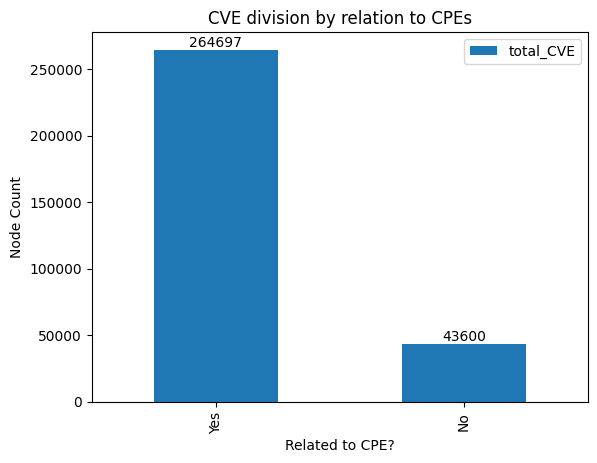

In [18]:
query = """
MATCH (n:UcoCVE)
OPTIONAL MATCH (n)-[UCOEXHASCPE]->(m:UcoexCPE)
RETURN count(DISTINCT n) as total_CVE,
CASE
    WHEN m IS NOT NULL THEN 'Yes'
    ELSE 'No'
END AS Is_related_to_CPE
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

ax = df.plot(x='Is_related_to_CPE', y='total_CVE', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('CVE division by relation to CPEs')
plt.xlabel('Related to CPE?')
plt.ylabel('Node Count')
plt.show()

| Related to CPE | Description | Count |
|----------------|-------------|-------|
| Yes | The CVE has a relationship to CPEs | 264697 |
| No | The CVE does not have a relationship to a CPE | 43600 |

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


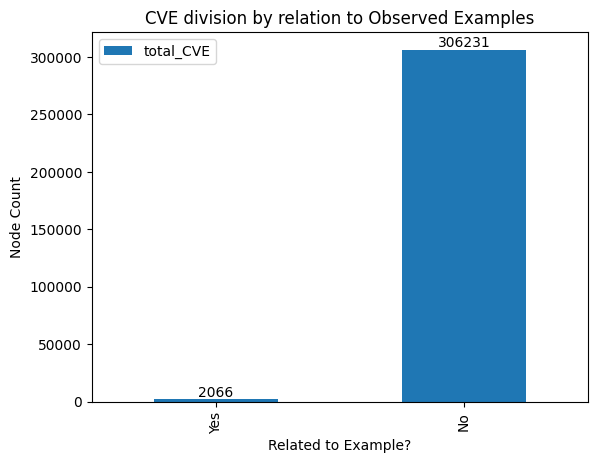

In [19]:
query = """
MATCH (n:UcoCVE)
OPTIONAL MATCH (n)<-[UCOEXEXAMPLEOBSERVEDIN]-(m:UcoexObservedExample)
RETURN count(DISTINCT n) as total_CVE,
CASE
    WHEN m IS NOT NULL THEN 'Yes'
    ELSE 'No'
END AS Is_related_to_Example
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

ax = df.plot(x='Is_related_to_Example', y='total_CVE', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('CVE division by relation to Observed Examples')
plt.xlabel('Related to Example?')
plt.ylabel('Node Count')
plt.show()

| Related to Observed Example | Description | Count |
|----------------|-------------|-------|
| Yes | The CVE has a relationship to an example | 2066 |
| No | The CVE does not have a relationship to an example | 306231 |

# CPEs

CPEs are nodes that describe what the vulnerability affects. This includes information about the affected publisher, the product, and other important information. This information can be analyzed to see what types of vulnerabilities are affected which publishers and products.

First, CPEs must be analyzed by themselves before being observed with CVEs. First a count is gather of the amount of CPE nodes that are present in the knowledge graph.

In [20]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CPE_count
0,138459


## CPE Properties

CPE properties contain important information about the affect product and more. CPE nodes contain far less properties than CVEs, but they still contain valuable information.

The most important property of CPE nodes is the label. The label is a string that is divided to present important information about the node. The string is formatted as follows:

CPE:2.3:(part):(publisher):(product):(version):(update):(edition):(language):(sw_edition):(target software):(target hardware):(other)

| cpeName Section | Description |
|-----------------|-------------|
| part           | A single character descibing the affected object. Either an a(application), o (operating system), or an h(hardware)
| publisher       | Displays the company responsible for the affected product
| product         | Displays the name of the product affected
| version         | If applicable, shows what version of the product was affected
| update          | If applicable, shows what patch of the product was affected
| edition         | If applicable, specifies if a specific edition of the product was affected
| language        | Specifies what languages the product is in
| sw_edition      | Displays what edition of the software was affected (basic, corporate)
| target software | Describes what software hosts the product
| target hardware | Describes what hardware hosts the product
| other           | Lists any other important features available

Previous workbook reports on CPE nodes have analyzed the publishers and the products that are listed in these labels. One of the more important pieces of this string is the part. The part is a single character that describe what exactly was affected in the CPE. The key for this is:

a - application/
o - operating system/
h - hardware

Considering that the part shows exactly was was affected, the CPEs can be analyzed to see how many affected each of the three parts.

As expressed in the graph below, the majority of CPEs were affecting applications. Operating systems were also not too far behind. Hardware was consider rather rare to be affected having barely a thousand entries.


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CPE_count Part
0            80386    a
1            56343    o
2             1730    h


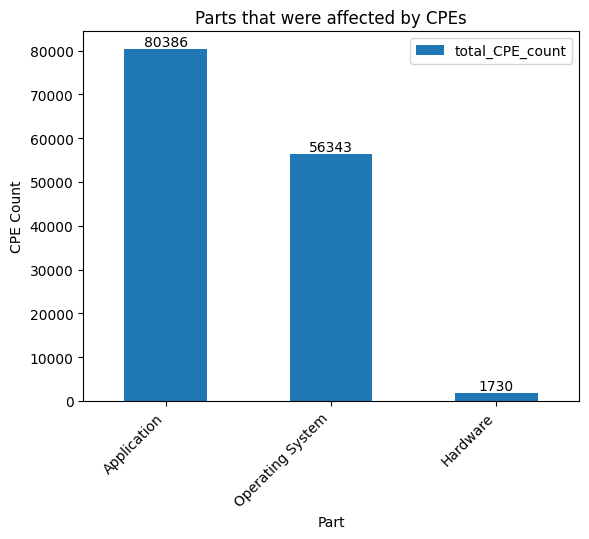

In [21]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[2] as Part
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
df['Part'] = df['Part'].replace(names)

ax = df.plot(x='Part', y='total_CPE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.title('Parts that were affected by CPEs')
plt.xlabel('Part')
plt.ylabel('CPE Count')
plt.show()

Taking this data some important questions can be asked. For example, how many CPEs affect each of the three parts each year? To grab the year the lastModified property was obtained to grab when the CPE was last updated. This date may not be the day the CPE was created, but rather references the last time it was updated. This is likely why there are no entries for CPEs between 1999-2006.

The graph shows that for each year, applications contained the majority of the CPEs for that year. However, starting at 2020, there was a rapid increase in CPEs that affected operating systems that the amount became higher than the CPEs affecting applications. This is especially seen in 2023, with over 11 thousand CPEs affecting operating systems. This data likely shows a shift in what parts attackers are targeting, with more of a focus being placed on operating systems rather than applications

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part  Application  Hardware  Operating System
Year                                         
2007        753.0      60.0             225.0
2008        659.0      61.0             176.0
2009        175.0       2.0              28.0
2010        505.0       1.0              71.0
2011        299.0       7.0              87.0
2012       1531.0      31.0             111.0
2013       1040.0      55.0             111.0
2014       2183.0      29.0             103.0
2015        796.0      32.0             182.0
2016        632.0      52.0             153.0
2017        408.0       1.0             105.0
2018        661.0      10.0             174.0
2019       3892.0      12.0            1090.0
2020       3833.0      35.0            4111.0
2021       3317.0     142.0            7448.0
2022       2355.0      17.0            4341.0
2023       3335.0      72.0           11710.0
2024       1105.0      15.0            1148.0
2025       1119.0       NaN             694.0


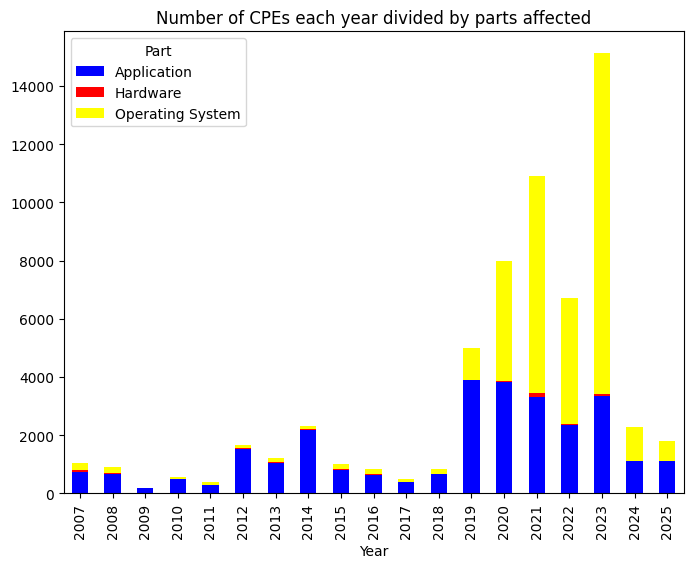

In [22]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, split(n.cpeName, ':')[2] as Part, split(toString(n.lastModified), '-')[0] as Year
ORDER BY Year DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CPE_count')
names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
pivot = pivot.rename(columns=names)
print(pivot)

colors = ['Blue', 'Red', 'Yellow',]

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CPEs each year divided by parts affected')
plt.show()

The CPEName also specifies the affected publishers. The publishers are the companies responsible for the products affected by vulnerabilities. Below shows the top publishers with the most related CPEs. Only the 15 most affected publishers are listed.

The affected publishers are usually names that are relatively familiar: HP, Intel, Microsoft, and Dell are just a few examples. However it also includes publishers may not be attributed to these big names and sometimes only have a few instances of vulnerabilities overall.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


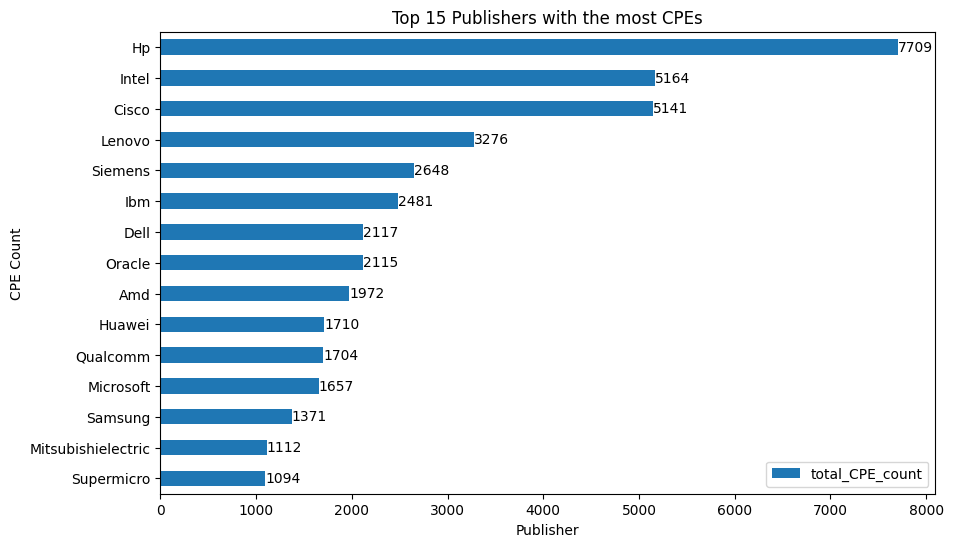

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Publisher
0,33972


In [23]:
#shows the top 15 most affected publishers
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, apoc.text.capitalize(split(n.cpeName, ':')[3]) as Publisher
ORDER BY total_CPE_count DESC
LIMIT 15
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


ax = df.plot(x='Publisher', y='total_CPE_count', kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0])
ax.invert_yaxis()
plt.title('Top 15 Publishers with the most CPEs')
plt.xlabel('Publisher')
plt.ylabel('CPE Count')
plt.show()

#shows the total amount of publishers affected
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(DISTINCT apoc.text.capitalize(split(n.cpeName, ':')[3])) as Publisher
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


While the graph above lists the top 15 most affected publishers, the table below shows the total amount of publishers affected

| Total amount of Publishers affected by CPEs |
|----------------------------|
| 33972 |

The CPEName next shows the exact product that was affected. The products are the exact application that was affected by the vulnerability. The following shows the top 15 products that were affected by the most CPEs

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


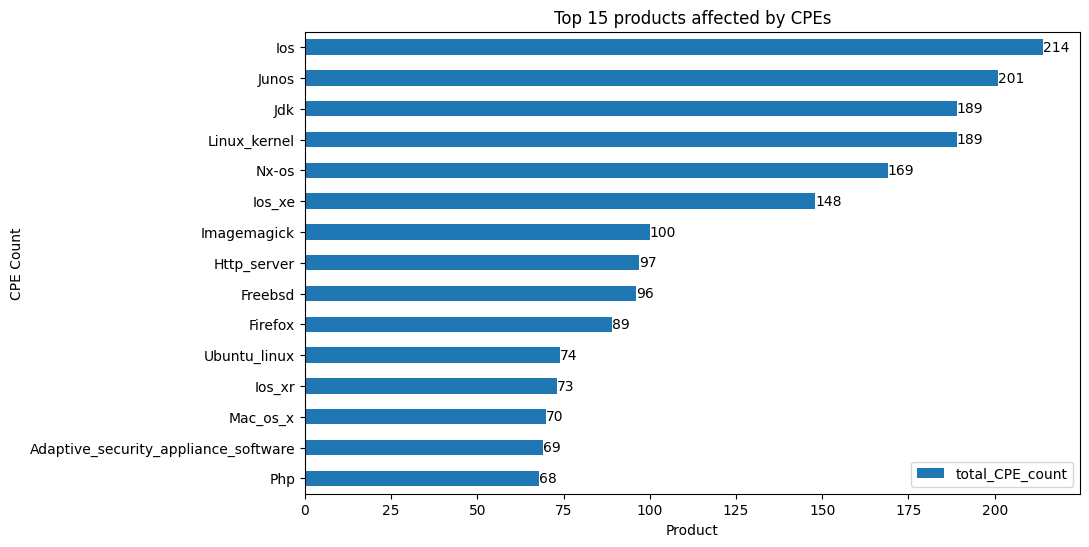

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Product
0,93782


In [24]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, apoc.text.capitalize(split(n.cpeName, ':')[4]) as Product
ORDER BY total_CPE_count DESC
LIMIT 15
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Product', y='total_CPE_count', kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0])
ax.invert_yaxis()
plt.title('Top 15 products affected by CPEs')
plt.xlabel('Product')
plt.ylabel('CPE Count')
plt.show()

#shows the total amount of products affected
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(DISTINCT apoc.text.capitalize(split(n.cpeName, ':')[4])) as Product
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


While the table above only lists the top 15 most affected products, the table below shows the total amount of products affected

|Total amount of Products affected by CPEs |
|-------------------------|
| 93782 |

Oftentimes CPEs only affect a specific version of a product. The version can usually be an older version of a product or a new one. However, somethimes a CPE either does not affect a specific version or does not list it.

CPEName lists the version if the CPE only affected one version of a product. Below shows How many CPEs were specific to one version of a product

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


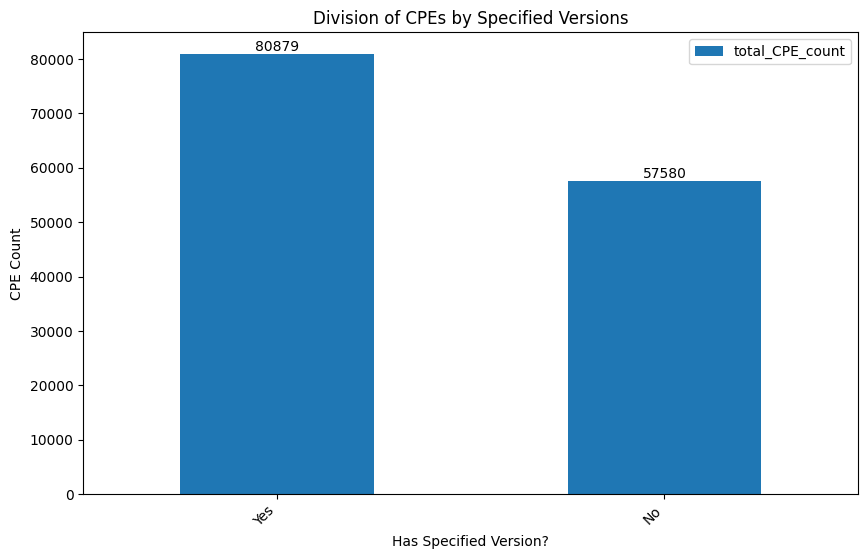

In [25]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, 
CASE
    WHEN split(n.cpeName, ':')[5] = '*' THEN 'No'
    ELSE 'Yes'
END AS Has_Specified_Version
ORDER BY total_CPE_count DESC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Has_Specified_Version', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.title('Division of CPEs by Specified Versions')
plt.xlabel('Has Specified Version?')
plt.ylabel('CPE Count')
plt.show()

The next item listed in CPEName is update. The update shows if the CPE affected a specific patch or update of the product, such as a beta version of a product for example. Below divides the CPEs by update

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


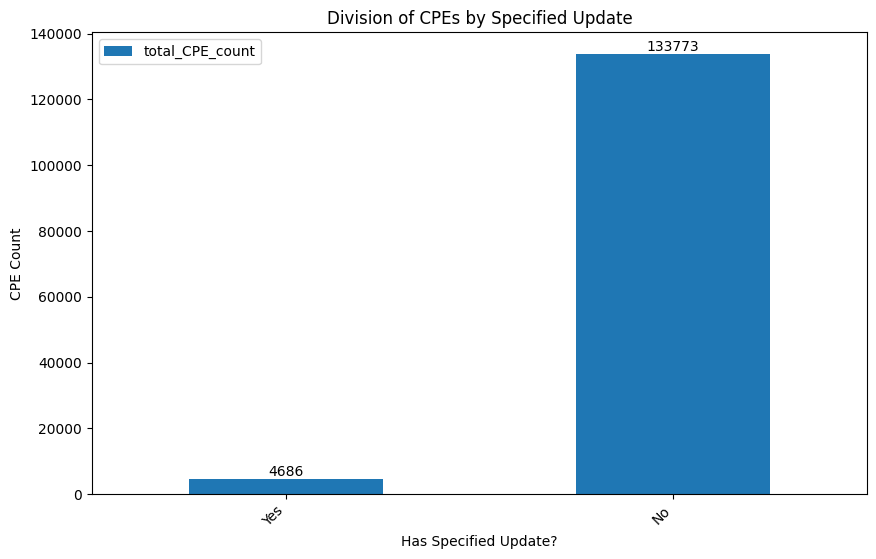

In [26]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, 
CASE
    WHEN split(n.cpeName, ':')[6] = '*' THEN 'No'
    ELSE 'Yes'
END AS Has_Specified_Update
ORDER BY total_CPE_count ASC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Has_Specified_Update', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.title('Division of CPEs by Specified Update')
plt.xlabel('Has Specified Update?')
plt.ylabel('CPE Count')
plt.show()

Next listed is the edition. The edition specifies a version of the product that usually is specified for specific hardware or applications. THis property can be useful in slowing if the product is related to any other important parts that might in turn also be affected. Below shows how many CPEs are specific to an edition.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


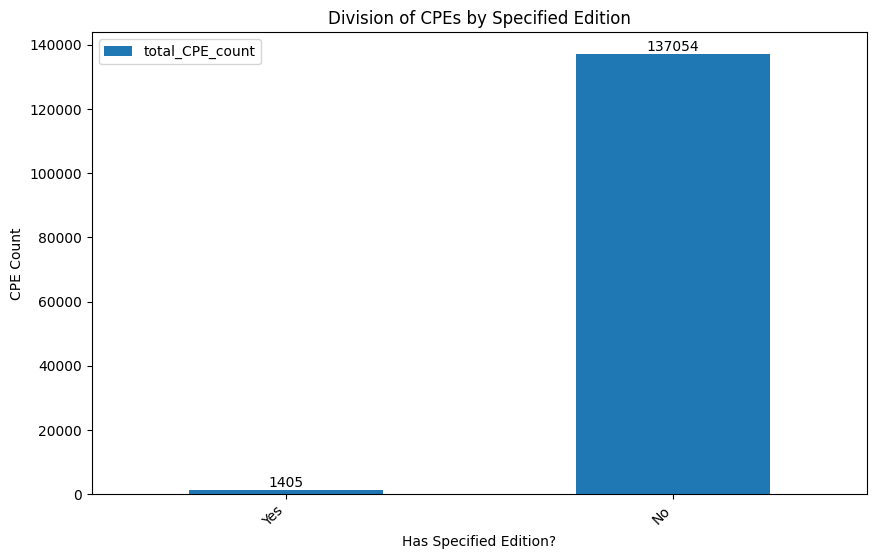

In [27]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, 
CASE
    WHEN split(n.cpeName, ':')[7] = '*' THEN 'No'
    ELSE 'Yes'
END AS Has_Specified_Edition
ORDER BY total_CPE_count ASC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Has_Specified_Edition', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.title('Division of CPEs by Specified Edition')
plt.xlabel('Has Specified Edition?')
plt.ylabel('CPE Count')
plt.show()

One other property is of importance. The dictionary_found property displays if the CPE is found in the local CPE dictionary database. Its a boolean value thats set to true if it exists and false if it does not. Below displays the distribution of CPEs based on this boolean value.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CPE_count  Exists_in_Dictionary
0            77159                 False
1            61300                  True


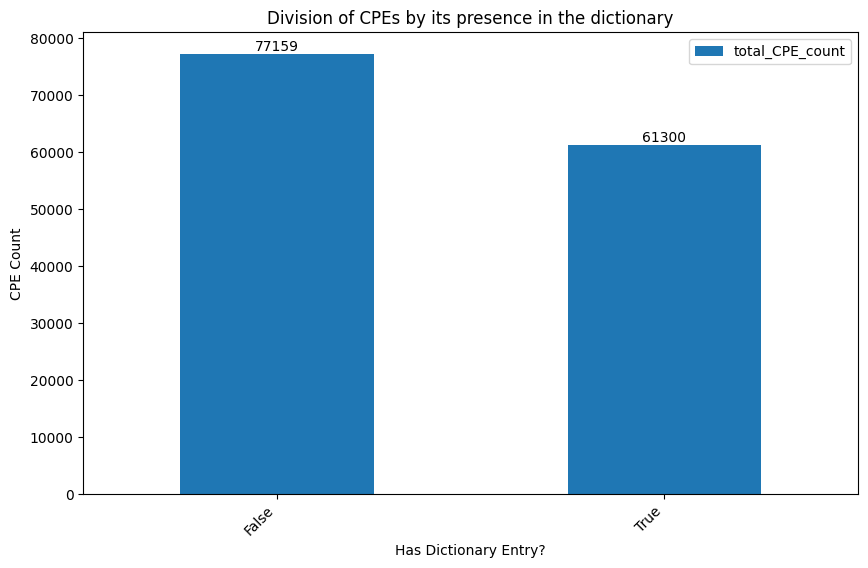

In [28]:
query = """
MATCH (n:UcoexCPE)
RETURN COUNT(n) as total_CPE_count, n.dictionary_found as Exists_in_Dictionary
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

ax = df.plot(x='Exists_in_Dictionary', y='total_CPE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.title('Division of CPEs by its presence in the dictionary')
plt.xlabel('Has Dictionary Entry?')
plt.ylabel('CPE Count')
plt.show()

| Dictionary Entry? |                     Description                   | CPE count |
|-------------------|---------------------------------------------------|-----------|
| Yes               | The CPE was located within the CPE dictionary     | 61300
| No                | The CPE was not located within the CPE dictionary | 77159

## CPEs Relationships

CPEs are only related to one node. CPEs are connected to CVEs through the relationship UCOEXHASCPE. A single CPE can have multiple CVEs connected to it. However some CVEs are not connected to any CPEs at all, however this is likely due to delays in the connection.

Taking the previous information that was gathered through individual analysis on CPEs, this can then be combined with CVEs to further tie it to vulnerabilities.

Taking the fact that CPEs can have several CVEs connected to them through this relationship, there should be a count showing how many CVEs are connected to applications, hardware, or operating systems. This then can also be divided by year to further develop the CVEs

THis further shows that attacks related to operating systems have been increasing. Hardware related CVEs aren't really seen showing that barely any CVEs are not really related to hardware CPEs and that these are still extremely rare. This can help show which parts are more of the target and where security measures likely need to focus on.

In [29]:
query = """
MATCH (n:UcoexCPE) <-[r]-(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoexCPE,UCOEXHASCPE,UcoCVE,663925


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


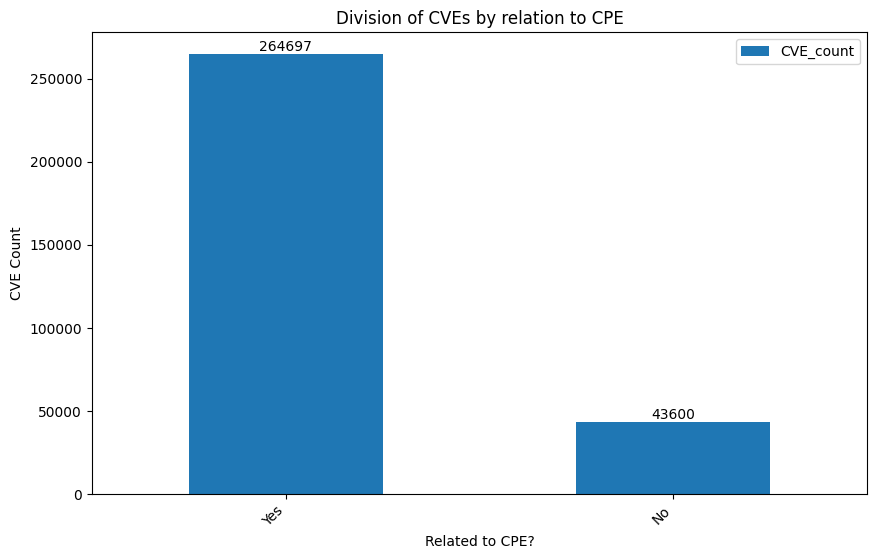

In [30]:
query = """
MATCH (n:UcoCVE)
OPTIONAL MATCH (n)-[UCOEXHASCPE]->(m:UcoexCPE)
RETURN count (DISTINCT n) as CVE_count,
CASE
    WHEN m IS NOT NULL THEN 'Yes'
    ELSE 'No'
END AS related_to_CPE

"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

ax = df.plot(x='related_to_CPE', y='CVE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.title('Division of CVEs by relation to CPE')
plt.xlabel('Related to CPE?')
plt.ylabel('CVE Count')
plt.show()

|     Source Node     |      Relationship      | Direction | Target Node | Count |
|---------------------|------------------------|-----------|-------------|-------|
| UcoexCPE            | UCOEXHASCPE            | Incoming  | UcoCVE      | 663925|


Using the relationships between nodes, connections can be made between the properties of each type of node to reveal hidden trends and answer possible questions.

For example, lets say someone wanted to know the division of parts affected by CVEs each year but also want to know what parts were affected the most by the CPEs related to them. By analyzing the properties through the relationship, this question can be answered like below. As the graph reveals, in recent years CVEs affecting operating systems have seen a rapid increase.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part  Application  Hardware  Operating System
Year                                         
1999        743.0      53.0             732.0
2000        922.0      37.0             320.0
2001       1166.0      75.0             381.0
2002       1937.0     128.0             414.0
2003       1224.0      42.0             306.0
2004       2282.0     116.0             547.0
2005       4049.0     138.0             596.0
2006       6380.0     167.0             602.0
2007       5624.0     236.0             934.0
2008       6418.0     196.0             794.0
2009       4691.0     151.0             792.0
2010       5621.0     110.0            1150.0
2011       5137.0      65.0            1069.0
2012       6370.0     134.0            1220.0
2013       7333.0     181.0            2237.0
2014       8421.0      90.0            3636.0
2015       7885.0      89.0            6430.0
2016       9332.0     238.0            7077.0
2017      12470.0      30.0           14965.0
2018      14584.0     145.0       

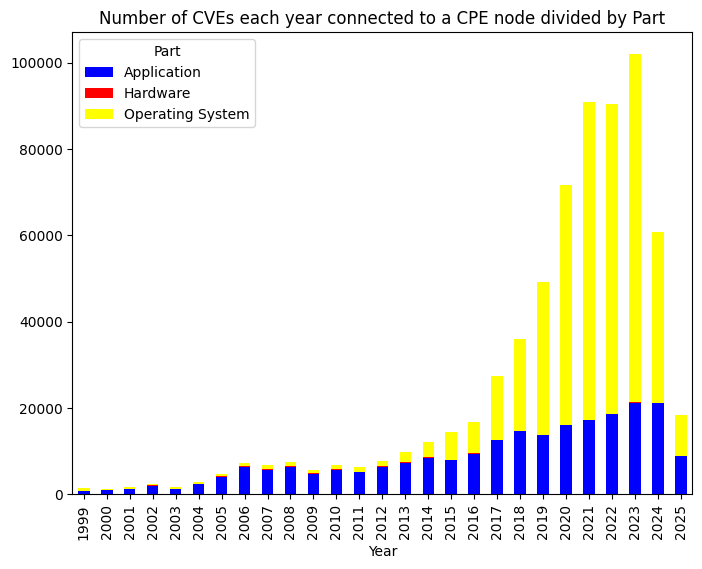

In [31]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
RETURN COUNT(n) as total_CVE_count,split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CVE_count')
names = {'a': 'Application', 'h': 'Hardware', 'o': 'Operating System'}
pivot = pivot.rename(columns=names)
print(pivot)

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs each year connected to a CPE node divided by Part')
plt.show()

Using this chart other questions can be asked. For example, considering that operating system CVEs seem to be more common in recent years, what are their severity rankings. This question can allow for specification of what property values we are wanting and reveal hidden connections between specific pieces of data. Percentages can also be derived from the data to form other types of charts to display results differently.

An important note is that the results here are off due to the previous mentioned issue with the severity ranking.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Severity            HIGH     LOW  MEDIUM
Year                                    
1999         NaN   408.0    86.0   220.0
2000         NaN   159.0    47.0   110.0
2001         NaN   166.0    82.0   125.0
2002         NaN   180.0    63.0   157.0
2003         NaN   153.0    35.0   113.0
2004         NaN   248.0    99.0   186.0
2005         NaN   201.0   145.0   215.0
2006         NaN   196.0    96.0   255.0
2007         NaN   373.0    66.0   340.0
2008         NaN   325.0    43.0   278.0
2009         NaN   263.0    37.0   278.0
2010         NaN   309.0    83.0   343.0
2011         NaN   295.0    90.0   362.0
2012         NaN   352.0   111.0   422.0
2013         NaN   504.0   150.0   873.0
2014         3.0   667.0   173.0   900.0
2015         1.0  1113.0   239.0  1388.0
2016         5.0  1616.0   310.0  1532.0
2017       107.0  1865.0   501.0  2620.0
2018       123.0  1631.0   515.0  2816.0
2019        17.0  1825.0   734.0  3000.0
2020       137.0  1660.0  1034.0  3565.0
2021       993.0

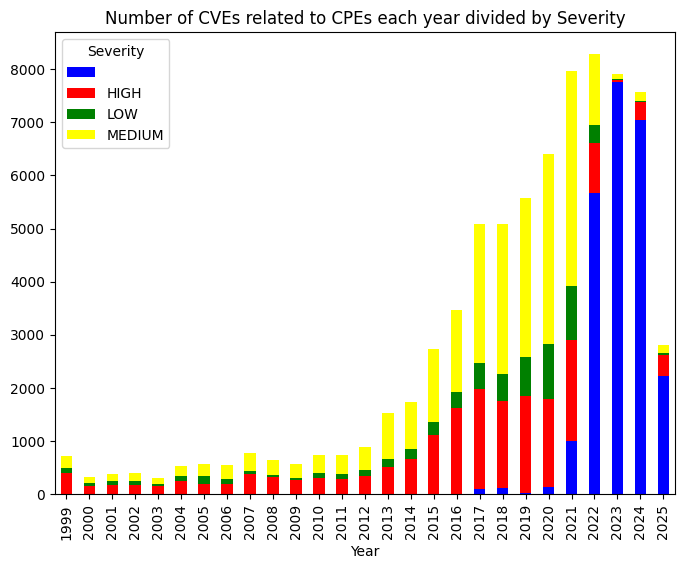

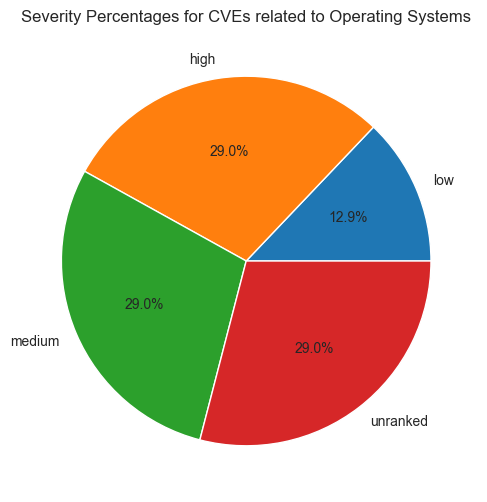

In [32]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE split(c.cpeName, ':')[2] = 'o'
RETURN COUNT(DISTINCT n) as total_CVE_count,split(n.label, '-')[1] as Year, n.ucobaseSeverity as Severity
ORDER BY split(n.label, '-')[1] ASC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Severity', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Green', 'Yellow']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs related to CPEs each year divided by Severity')
plt.show()

Severity_count = df['Severity'].value_counts().sort_values(ascending=True)

sb.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(Severity_count, labels=['low', 'high', 'medium', 'unranked'], autopct='%1.1f%%')
plt.title('Severity Percentages for CVEs related to Operating Systems')
plt.show()

Another question that can be asked is which CPE parts are more connected to CVEs that allow for full administrator access.

The graph shows that CVEs that allow for full administrator access were more tied to applications rather than operating systems. 2021 is a bit of an outlier as the majority of CVEx that cause full admin access did target operating systems. However for the majority of years, Applications were the main target. This shows that applications are likely more vulnerable to full access.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Part      a     h      o
Year                    
1999  162.0   8.0  315.0
2000  194.0   8.0  134.0
2001  205.0   3.0  113.0
2002  230.0  17.0   92.0
2003  164.0   5.0   83.0
2004  355.0  13.0  159.0
2005  177.0   2.0   81.0
2006  402.0  23.0  111.0
2007  774.0  43.0  314.0
2008  624.0  39.0  170.0
2009  284.0  13.0   86.0
2010  209.0   3.0   77.0
2011   16.0   1.0    6.0
2012   16.0   2.0    NaN
2013    4.0   3.0    2.0
2014   32.0   2.0    8.0
2015   22.0   2.0   44.0
2016   45.0   5.0   33.0
2017   28.0   NaN   58.0
2018   18.0   NaN    4.0
2019    1.0   NaN    1.0
2020    2.0   NaN    1.0
2021    4.0   NaN  263.0
2022    2.0   NaN    NaN


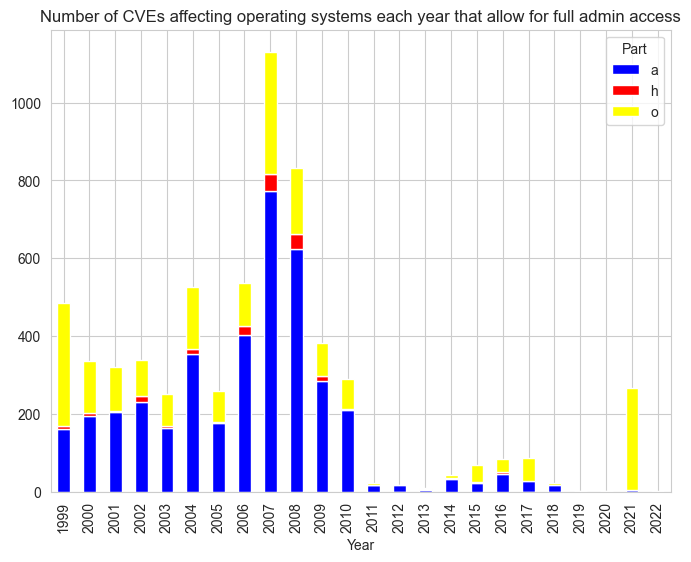

In [33]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucoobtainAllPrivilege = 'true'
RETURN COUNT(n) as total_CVE_count, split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

#pivot the data to prepare to make a stacked bar graph
pivot = df.pivot_table(index = 'Year', columns = 'Part', values = 'total_CVE_count')
print(pivot)

colors = ['Blue', 'Red', 'Yellow']

ax = pivot.plot(kind='bar', stacked=True,color=colors, figsize=(8, 6))
ax.set_title('Number of CVEs affecting operating systems each year that allow for full admin access')
plt.show()

In [34]:
query = """
MATCH (n:UcoCVE)-[UCOEXHASCPE]->(c:UcoexCPE)
WHERE n.ucoobtainAllPrivilege = 'true'
RETURN COUNT(n) as total_CVE_count, split(n.label, '-')[1] as Year, split(c.cpeName, ':')[2] as Part
ORDER BY split(n.label, '-')[1] ASC
"""

# CWEs

CWE nodes discuss common weaknesses that can be found. The amount of CWEs is far less than other nodes in the knowledge graph but are equally as important and contain vital information. This is because sometimes CVEs are tied to specific weaknesses and can help further explain how the vulnerability occured.

Before comparing CWEs to other nodes, CWEs themselves must be understood. Firstly its important to see how many CWEs are present in the knowledge graph

In [35]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count
0,969


## CWE Properties

CWEs contain quiet a few different properties that are used to describe the weakness and possible solutions. These properties are listed below.

|         Property         | Description |
|--------------------------|-------------|
| ucocweSummary            | Gives a summary of the weakness and how it works |
| ucolikelihoodOfExploit   | displays how likely it is for the weakness to be exploited |
| ucodescription           | Gives a brief description of the weakness |
| ucoalternative_terms     | Lists any alternative terms the weakness has |
| ucoapplicablePlatform    | Lists all languages and platforms that are affected by the weakness |
| ucotimeOfIntroduction    | lists the date the weakness was discovered and reported |
| ucodemonstrativeExamples | provides a demostration to show the weakness using example code |
| ucopotentialMitigations  | lists all possible mitigations to combat the weakness |
| ucomappingNotes          | Shows if mapping is allowed for the cwe and why |
| ucodetectionMethods      | lists all ways that the weakness can be detected |
| ucoabstraction           | Gives the CWE a ranking based on how specific a weakness is |
| ucocommonConsequences    | Lists the common consequences that occur when the weakness is exploited |
| ucomodesOfIntroduction   | Describes how the weakness was introduced |
| ucocweID                 | A unique ID for the CWE |
| ucocweName               | The name describing the weakness |
| ucostatus                | Describes the current status of the CWE entry |
| uri                      | A link to the CWE |
| ucoobservedExamples      | Displays all observed examples of the CWE being exploited |
| ucoreferences            | Includes a list of all references and their IDs | 
| ucostructure             | Describes the structure of the weakness |
| ucorelatedAttackPatterns | Lists any attack patterns that are connected to the weakness |
| ucocweExtendedSummary    | Provides an extended summary of the weakness |

 Firstly theres the ucoAbstraction property. This property describes how much is known about the weakness and how descriptive the CWE is. Sometimes CWEs can be specific to a certain product while others are more of a concept and do not have a set description. This information is useful as the more that is known about the weakness, the more that can be done to prevent it.

Shown below most CWEs fall into the variant and base categories. These categories contain the most information about the weakness while other categories such as pillar are more generic and have less detail.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


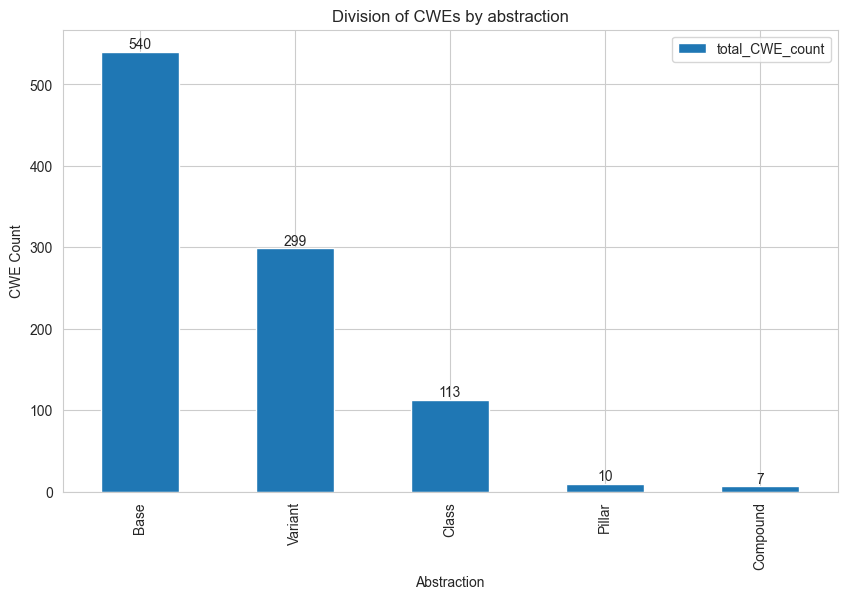

In [36]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, n.ucoabstraction as Abstraction
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Abstraction', y='total_CWE_count', kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CWEs by abstraction')
plt.xlabel('Abstraction')
plt.ylabel('CWE Count')
plt.show()

| Abstraction | Description | Count |
|-------------|-------------|-------|
| Base | The weakness contains basic documentation and is not specific to any technology | 540
| Variant | The weakness is specific to a particular technology | 299
| Class | The weakness has simple documentation but is more abstract | 113
| Pillar | The weakness is highly abstract and considered more as a concept | 10
| Compound | The weakness is a combination of two or more rankings | 7

CWEs also contain a property, ucoApplicablePlatform that displays the language and, if applicable, operating system. The following query will take all of the weakness and display the languages they affect.

The majority of the CWEs are not specific to any language but the C, Jave, and C++ languages, which are widely used today, contain the most entries

In [37]:
query = """
MATCH (n:UcoCWE)
WHERE n.ucoapplicablePlatform IS NOT NULL
WITH n, n.ucoapplicablePlatform AS text
WITH n, apoc.text.regexGroups(text, 'Language=\\[(.*?)\\]') AS langBlocks
UNWIND CASE WHEN size(langBlocks) = 0 THEN [NULL] ELSE langBlocks END AS lb
WITH n, lb[0] AS languageSection
WITH n,
     CASE
         WHEN languageSection IS NULL THEN ['None']
         ELSE
             // all "Name" values
             [x IN apoc.text.regexGroups(languageSection, '"Name":"([^"]+)"') | x[1]] +
             // all "Class" values
             [x IN apoc.text.regexGroups(languageSection, '"Class":"([^"]+)"') | x[1]]
     END AS languages

UNWIND languages AS language
WITH trim(language) AS language
RETURN language, count(*) AS occurrences
ORDER BY occurrences DESC;
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,language,occurrences
0,Not Language-Specific,559
1,C,92
2,C++,92
3,Java,77
4,PHP,25
5,C#,23
6,Verilog,15
7,VHDL,14
8,None,13
9,Perl,12


The ucoapplicablePlatform property not only stores any affected languages, but also affected operating systems. This is stored after 'Operating_System=' and displays either none, one, or multiple operating systems.

Below shows a count of the amount of affected operating systems in the CWEs. The majority of CWEs are not specific to an operating system or do not include any listings of affected operating system

In [38]:
query = """
MATCH (n:UcoCWE)
WHERE n.ucoapplicablePlatform IS NOT NULL
WITH n, n.ucoapplicablePlatform AS text
WITH n, apoc.text.regexGroups(text, 'Operating_System=\\[(.*?)\\]') AS langBlocks
UNWIND CASE WHEN size(langBlocks) = 0 THEN [NULL] ELSE langBlocks END AS lb
WITH n, lb[0] AS languageSection
WITH n,
     CASE
         WHEN languageSection IS NULL THEN ['None']
         ELSE
             // all "Name" values
             [x IN apoc.text.regexGroups(languageSection, '"Name":"([^"]+)"') | x[1]] +
             // all "Class" values
             [x IN apoc.text.regexGroups(languageSection, '"Class":"([^"]+)"') | x[1]]
     END AS languages

UNWIND languages AS language
WITH trim(language) AS language
RETURN language as Operating_System, count(*) AS occurrences
ORDER BY occurrences DESC;
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Operating_System,occurrences
0,None,605
1,Not OS-Specific,113
2,Windows,14
3,Unix,6
4,macOS,3
5,Windows NT,2


The ucoapplicablePlatform also stores other technologies that could have been affected by the weakness, including servers and pieces of hardware. Below lists the hardware and software that was affected by 

In [39]:
query = """
MATCH (n:UcoCWE)
WHERE n.ucoapplicablePlatform IS NOT NULL
WITH n, n.ucoapplicablePlatform AS text
WITH n, apoc.text.regexGroups(text, 'Technology=\\[(.*?)\\]') AS langBlocks
UNWIND CASE WHEN size(langBlocks) = 0 THEN [NULL] ELSE langBlocks END AS lb
WITH n, lb[0] AS languageSection
WITH n,
     CASE
         WHEN languageSection IS NULL THEN ['None']
         ELSE
             // all "Name" values
             [x IN apoc.text.regexGroups(languageSection, '"Name":"([^"]+)"') | x[1]] +
             // all "Class" values
             [x IN apoc.text.regexGroups(languageSection, '"Class":"([^"]+)"') | x[1]]
     END AS languages

UNWIND languages AS language
WITH trim(language) AS language
RETURN language as Technology, count(*) AS occurrences
ORDER BY occurrences DESC;
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Technology,occurrences
0,None,507
1,Not Technology-Specific,116
2,ICS\/OT,41
3,System on Chip,30
4,Mobile,21
5,Processor Hardware,17
6,AI\/ML,16
7,Web Based,16
8,Web Server,15
9,Database Server,10


The commonConsequences property describes what usually happens when the weakness is expolited. Its structured the same way as the applicablePlatform property

commonConsequences list two things, the scope of the consequence, and the impact of the consequence. The two items will be grabbed separately to display below

In [40]:
query = """
MATCH (n:UcoCWE)
WHERE n.ucocommonConsequences IS NOT NULL
WITH n, n.ucocommonConsequences AS text
WITH n, apoc.text.regexGroups(text, 'consequence=\\[(.*?)\\]') AS langBlocks
UNWIND CASE WHEN size(langBlocks) = 0 THEN [NULL] ELSE langBlocks END AS lb
WITH n, lb[0] AS languageSection
WITH n,
     CASE
         WHEN languageSection IS NULL THEN ['None']
         ELSE
             // all "Name" values
            [x IN apoc.text.regexGroups(languageSection, '"Scope":"([^"]+)"') | x[1]]
     END AS languages

UNWIND languages AS language
WITH trim(language) AS language
RETURN language as Consequence_Scope, count(*) AS occurrences
ORDER BY occurrences DESC;
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Consequence_Scope,occurrences
0,Other,183
1,Confidentiality,139
2,Access Control,124
3,Integrity,123
4,Availability,73
5,Non-Repudiation,8
6,Authentication,3
7,Accountability,1
8,Authorization,1


So far, most weaknesses result usually have a specific scope now listed, or result in issues with confidentiality of information and access control.

We can also see what exactly the cosequence was

In [41]:
query = """
MATCH (n:UcoCWE)
WHERE n.ucocommonConsequences IS NOT NULL
WITH n, n.ucocommonConsequences AS text
WITH n, apoc.text.regexGroups(text, 'consequence=\\[(.*?)\\]') AS langBlocks
UNWIND CASE WHEN size(langBlocks) = 0 THEN [NULL] ELSE langBlocks END AS lb
WITH n, lb[0] AS languageSection
WITH n,
     CASE
         WHEN languageSection IS NULL THEN ['None']
         ELSE
             // all "Name" values
            [x IN apoc.text.regexGroups(languageSection, '"Impact":"([^"]+)"') | x[1]]
     END AS languages

UNWIND languages AS language
WITH trim(language) AS language
RETURN language as Consequence_Impact, count(*) AS occurrences
ORDER BY occurrences DESC;
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Consequence_Impact,occurrences
0,Read Application Data,75
1,Unexpected State,64
2,Bypass Protection Mechanism,58
3,Gain Privileges or Assume Identity,45
4,Reduce Maintainability,40
5,Varies by Context,36
6,Modify Application Data,26
7,Other,24
8,"DoS: Crash, Exit, or Restart",22
9,Quality Degradation,22


There are a lot of different impacts that a weakness can cause. Most consequences resulted in information being read or stolen or privileges being bypassed.

ucoMappingNotes is another JSON property that is slightly simplier than the other properties. This property mainly describes using mapping for this CWE is allowed and the explaination for why and why not. The query below divides the CWEs to show which ones allow for mapping

As seen below, most CWEs do allow for mapping to occur, though 88 entries to require review before it can occur. In total, 128 CWE nodes either discourage the usage of mapping or outright not allow for mapping to occur.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


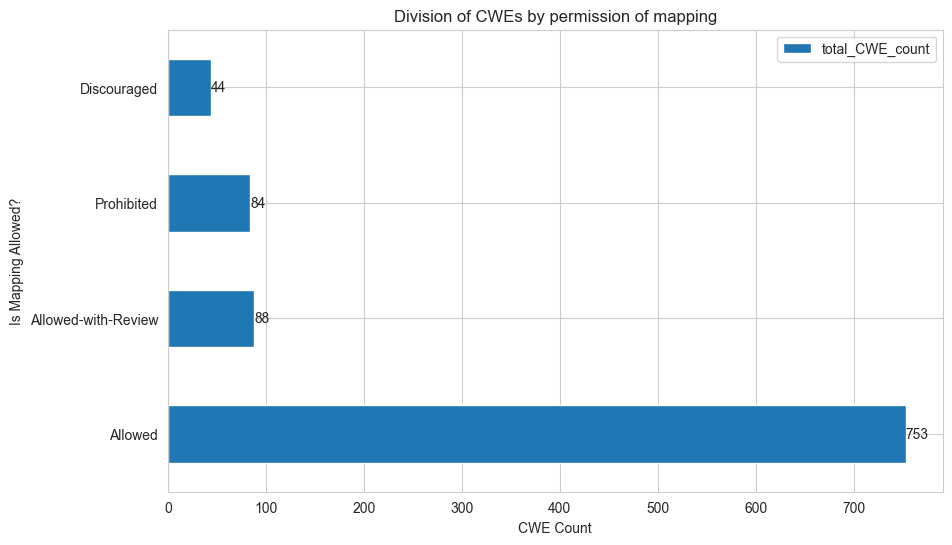

In [42]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, SPLIT(SUBSTRING(n.ucomappingNotes, 7), ',')[0] as Is_mapping_allowed
ORDER BY total_CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Is_mapping_allowed', y='total_CWE_count', kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CWEs by permission of mapping')
plt.xlabel('CWE Count')
plt.ylabel('Is Mapping Allowed?')
plt.show()

| Mapping Decision    |Description| CWE count |
|---------------------|-----------|-----------|
| Allowed             |Mapping is allowed for the weakness| 753
| Allowed with review | Mapping is allowed but the weakness must be reviewed first|  88
| Prohibited          | Mapping is not allowed at all for the weakness|  84
| Discouraged         | Mapping is allowed but is not recommended|  44

To combat these CWEs, mitigations are constantly being proposed and tested. This property also stores the current phase of the mitigation and its implementation.



In [43]:
query = """
MATCH (n:UcoCWE)
WHERE n.ucopotentialMitigations IS NOT NULL
WITH n, n.ucopotentialMitigations AS text
WITH n, apoc.text.regexGroups(text, 'mitigation=\\[(.*?)\\]') AS langBlocks
UNWIND CASE WHEN size(langBlocks) = 0 THEN [NULL] ELSE langBlocks END AS lb
WITH n, lb[0] AS languageSection
WITH n,
     CASE
         WHEN languageSection IS NULL THEN ['None']
         ELSE
             // all "Name" values
            [x IN apoc.text.regexGroups(languageSection, '"Phase":"([^"]+)"') | x[1]]
     END AS languages

UNWIND languages AS language
WITH trim(language) AS language
RETURN language as mitigation_phase, count(*) AS occurrences
ORDER BY occurrences DESC;
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,mitigation_phase,occurrences
0,Implementation,670
1,Architecture and Design,506
2,Testing,57
3,Requirements,52
4,Operation,39
5,System Configuration,24
6,Build and Compilation,22
7,Installation,13
8,Integration,11
9,Documentation,5


| Implementation Phase | Description | Count |
|----------------------|-------------|-------|
| Architecture and Design | The mitigation is being designed | 506
| Implementation | The mitigation is being implemented for the weakness | 670
| Requirements | The mitigation is having requirements defined | 52
| Testing | The mitigation is being tested | 57
| Operation | The mitigation is currently being operated | 39
| System Configuration | The mitigation is being configured with its required system | 24
| Build and Compilation | The mitigation is being programmed and compiled | 22
| Installation | The mitigation is ready to be installed | 13
| Policy | The mitigation is having its policys defined | 5
| Documentation | Documentation is being gathered for the mitigation | 5
| Distribution | The mitigation is being distributed | 3
| Integration | The mitigation is being integrated | 11
| Manufacturing | the mitigation is being manufactured | 3
| Patching and Maintenance | the mitigation is currently being patched or updated | 1

ucoStructure is a property that lists the structure of the weakness. Below shows the distribution of the weaknesses based on their structure

In [44]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, n.ucostructure as structure
ORDER BY total_CWE_count DESC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CWE_count,structure
0,962,Simple
1,4,Composite
2,3,Chain


| Structure | Description | Count|
|-----------|-------------|------|
| Simple | The structure of the weakness is simple | 962
| Composite | The structure of the weakness is somewhat complex | 4
| Chain | The weakness leads to conditions for other weaknesses | 3


ucostatus displays the current status of the mitigation. This property is useful as it shows the current state of measures being taken to combat weaknesses.

For most CWEs, the current status is either incomplete or in a draft state, though there have been a few that have been able to stabilize the weakness.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


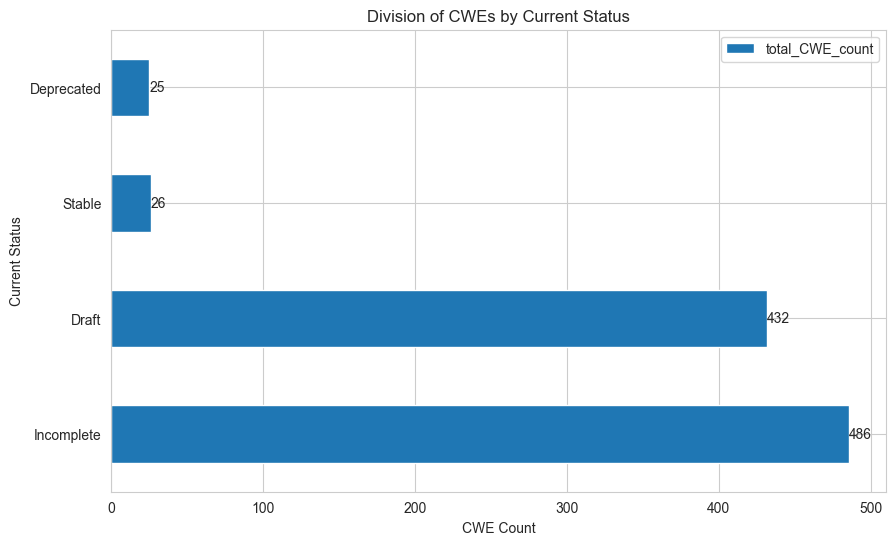

In [45]:
query = """
MATCH (n:UcoCWE)
RETURN COUNT(n) as total_CWE_count, n.ucostatus as current_status
ORDER BY total_CWE_count DESC
"""
params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='current_status', y='total_CWE_count', kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title('Division of CWEs by Current Status')
plt.xlabel('CWE Count')
plt.ylabel('Current Status')
plt.show()

| Status | Description | Count
|--------|-------------|------
| Incomplete | The weakness has not been fully investigated | 486
| Draft | The weakness has a draft of documentation and mitigations | 432
| Stable | A mitigation method has been able to contain the weakness | 26
| Deprecated | The weakness has not been properly reviewed or contained | 25

# CWE Relationships

CWEs are related to three different nodes. CAPEC, Exploit Target, and Observed Example. 

In [46]:
query = """
MATCH (n:UcoCWE)<-[r]-(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n:UcoCWE)-[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoCWE,UCOHASWEAKNESS,UcoExploitTarget,969
1,UcoCWE,UCOEXHASRELATEDWEAKNESS,UcoexCAPEC,1212
2,UcoCWE,UCOHASOBSERVEDEXAMPLE,UcoexObservedExample,3023


|     Source Node     |      Relationship      | Direction | Target Node | Count |
|---------------------|------------------------|-----------|-------------|-------|
| UcoExploitTarget           | UCOHASWEAKNESS           | Outgoing  | UcoCWE      | 969|
| UcoCWE | UCOEXHASRELATEDWEAKNESS | Incoming | UcoexCAPEC | 1212
| UcoCWE | UCOHASOBSERVEDEXAMPLE | Outgoing | UcoexObservedExample | 3023
| UcoCWE | (all) | (mixed) | (mixed) | 5204

In total there are over 5000 relationships with CWEs. CWEs are rather important especially when it comes to CAPECs as, according to the graph structure, CWEs are one of the only NVD nodes that connect to the MITRE nodes.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


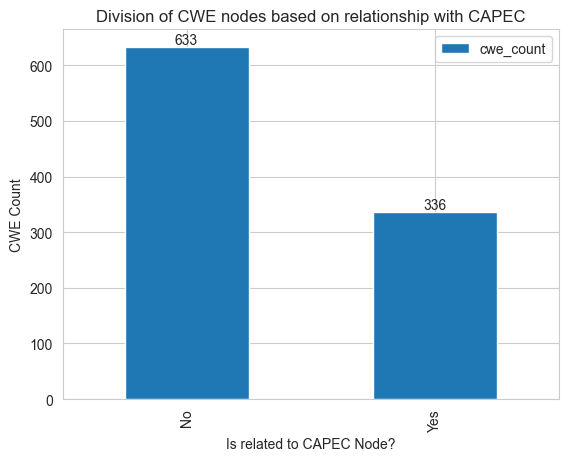

In [47]:
query = """
MATCH (n:UcoCWE)
OPTIONAL MATCH (n)<-[UCOEXHASRELATEDWEAKNESS]-(w:UcoexCAPEC)
RETURN COUNT(DISTINCT n) as cwe_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_capec
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_capec', y='cwe_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CWE nodes based on relationship with CAPEC')
plt.xlabel('Is related to CAPEC Node?')
plt.ylabel('CWE Count')
plt.show()

| Related to CAPEC | count|
|------------------|------|
| Yes | 336
| No | 633

The majority of weaknesses are not related to an attack pattern as seen above. This shows that few CWE nodes actually connect the NVD nodes to CAPEC nodes, which are seen as the connector to the MITRE database.

Below shows connections to observed examples

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


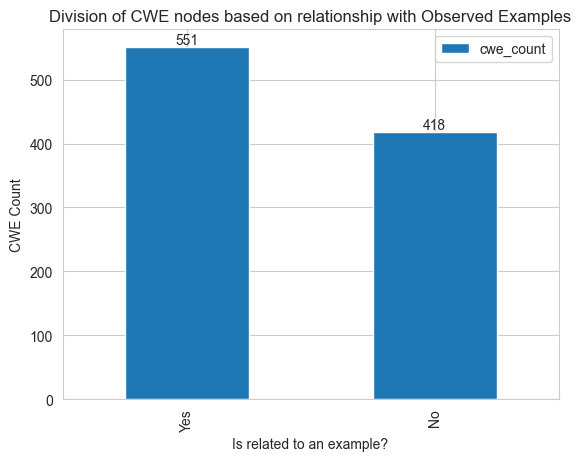

In [48]:
query = """
MATCH (n:UcoCWE)
OPTIONAL MATCH (n)-[UCOHASOBSERVEDEXAMPLE]->(w:UcoexObservedExample)
RETURN COUNT(DISTINCT n) as cwe_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_example
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_example', y='cwe_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CWE nodes based on relationship with Observed Examples')
plt.xlabel('Is related to an example?')
plt.ylabel('CWE Count')
plt.show()

| Related to Example | count|
|------------------|------|
| Yes | 551
| No | 418

As seen above, Observed examples are more related to Weaknesses than vulnerabilities. Eariler analysis showed that very few examples related to CVEs, however here, over half of the CWEs are related to an example.

However, one last relationship we can see is exactly how many CVEs are related to CWEs. This requires a more complicated query due to CVEs and CWEs now being directly related.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


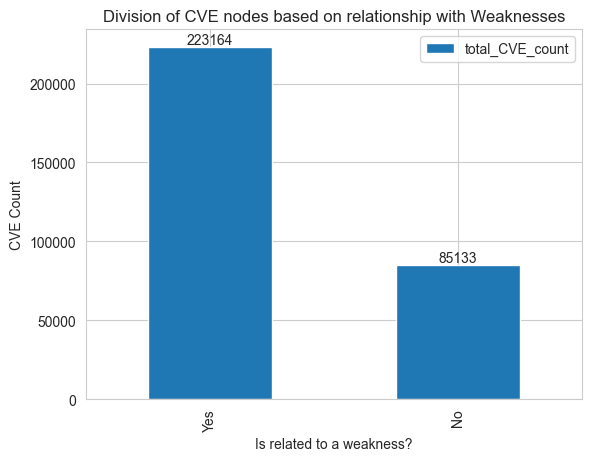

In [49]:
query = """
MATCH (n:UcoCVE)
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
RETURN count(DISTINCT n) as total_CVE_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_weakness
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_weakness', y='total_CVE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CVE nodes based on relationship with Weaknesses')
plt.xlabel('Is related to a weakness?')
plt.ylabel('CVE Count')
plt.show()


| Related to example | Node count |
|--------------------|------------|
| Yes | 223164
| No | 85133

As seen above the majority of CVEs do have a relationship to a weakness, meaning weakness often tie into vulnerabilities.

# CAPEC

CAPEC nodes display attack patterns that are often used when expoliting variables. CAPEC nodes are vital to the knowledge as these nodes serve as a connection between both sides of the knowledge graph.

In [50]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(n) as total_CAPEC_count
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,total_CAPEC_count
0,559


# CAPEC Properties

CAPEC, like CWE, contain the most amount of properties out of any node. The properties are listed below.

| Property | Description |
|----------|-------------|
|ucoexCAPEC_ID | Unique ID for each CAPEC
|ucoexCAPEC_Name | Gives the name of the attack pattern
| uri | Source identifier that links to the source
| label | Unique node label
| ucoexDescription | Gives a description about the attack pattern
| ucoexExtendedDescription | Gives more extensive detail about the attack pattern
| ucoexExample | Lists example senarios of the attack pattern
| ucoexAbstraction | Displays the abstraction level of the attack pattern
| ucoexRelatedWeakness | Lists all weaknesses that the attack pattern is related to
| ucoexRelatedPattern | Lists all attack patterns the node is related to
| ucoexTaxnomyMappingATT3CK | Lists the mapped attack techniques related to the CAPEC node
| ucoexPrerequistites | Lists any required conditions that need to be fufilled
| ucoexResources_Required | Lists any resources needed
| ucoexSkills_Required | Lists the skill level and required knowledge before the attack
| ucoexConsequences | Shows the potential impact and scope of the attack pattern
| ucoexExecutionFlowTechniques | describes the execution steps taken for the attack
| ucoexSeverity | Shows the severity of the attack pattern
| ucoexLikelihood | Shows the likelihood the attack will occur
| ucoexMitigations | Lists any possible mitigations

The abstraction level shows the current knowledge of the attack pattern. Below shows the division of CAPEC nodes by their abstraction

   total_CAPEC_count Abstraction
0                317    Detailed
1                181    Standard
2                 61        Meta


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


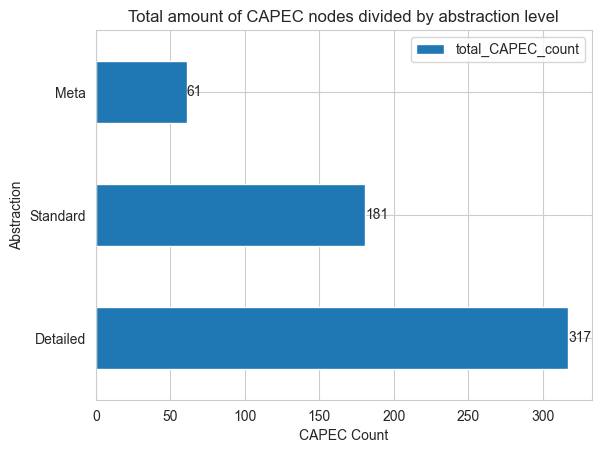

In [51]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(n) as total_CAPEC_count, n.ucoexAbstraction as Abstraction
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Abstraction', y='total_CAPEC_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Total amount of CAPEC nodes divided by abstraction level')
plt.xlabel('CAPEC Count')
plt.ylabel('Abstraction')
plt.show()

Often times attack patterns will require a prerequiste to be fufilled in order for the attack to occur. The following query shows which CAPEC nodes contain a prerequisite. 

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


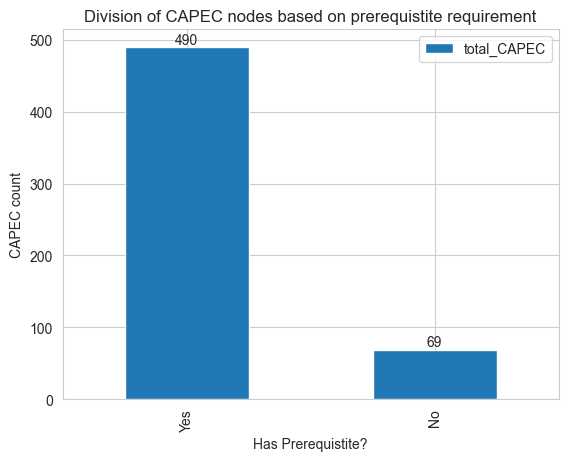

In [52]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexPrerequisites IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_prerequisites
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_prerequisites', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on prerequistite requirement')
plt.xlabel('Has Prerequistite?')
plt.ylabel('CAPEC count')
plt.show()

The ucoexMitigations contains a description of the mitigation method for the attack pattern. However a null value can be present if one isnt there. 

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


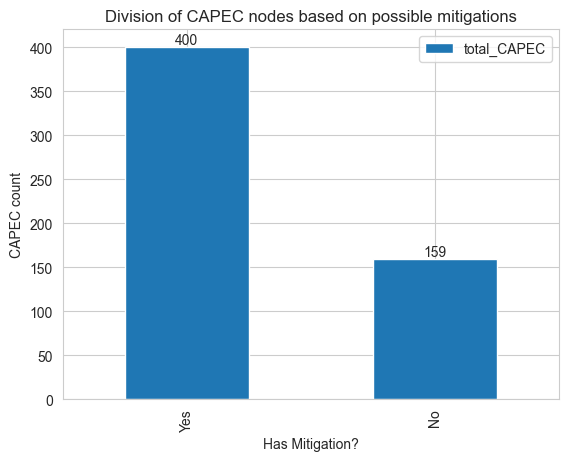

In [53]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexMitigations IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_Mitigations
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_Mitigations', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on possible mitigations')
plt.xlabel('Has Mitigation?')
plt.ylabel('CAPEC count')
plt.show()

UcoexExample displays any examples of the attack pattern that occur. The property may have a null value if there are no examples present

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


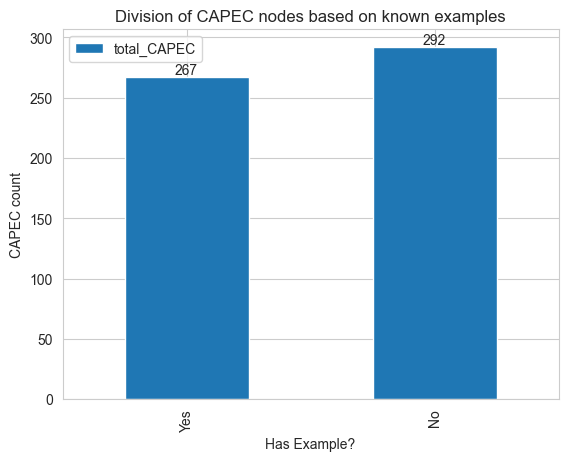

In [54]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexExample IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_Examples
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_Examples', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on known examples')
plt.xlabel('Has Example?')
plt.ylabel('CAPEC count')
plt.show()

Oftentimes attack patterns may be related to other attack patterns. Other times they may be unrelated. UcoexRelatedAttPattern displays all of the attack patterns in a list that the attack pattern is related to

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


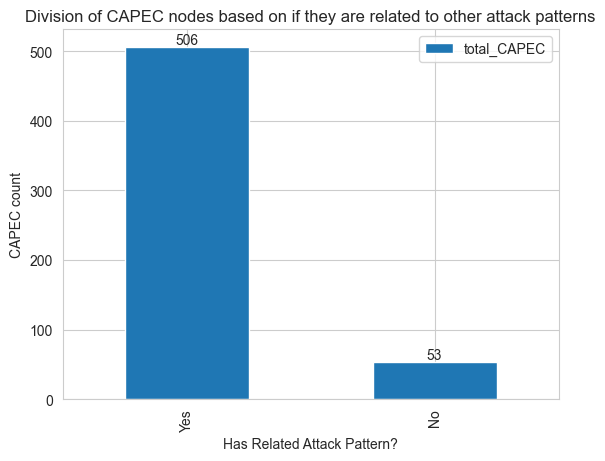

In [55]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexRelatedAttPattern IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_RelatedAttackPattern
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_RelatedAttackPattern', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on if they are related to other attack patterns')
plt.xlabel('Has Related Attack Pattern?')
plt.ylabel('CAPEC count')
plt.show()

Attack patterns may also be related to specific weaknesses. UcoexRelatedWeaknesses displays a list of all weaknesses that a CAPEC node is related to but may also be null

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


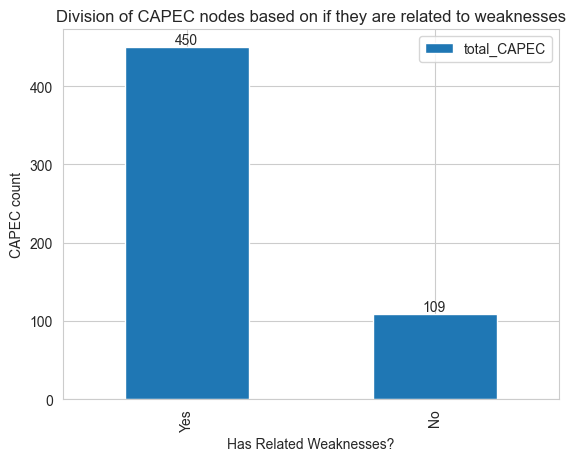

In [56]:
query = """
MATCH (n:UcoexCAPEC)
RETURN count(DISTINCT n)as total_CAPEC,
CASE
    WHEN n.ucoexRelatedWeaknesses IS NULL THEN 'No'
    ELSE 'Yes'
END AS has_RelatedWeaknesses
ORDER BY total_CAPEC DESC
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

ax = df.plot(x='has_RelatedWeaknesses', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC nodes based on if they are related to weaknesses')
plt.xlabel('Has Related Weaknesses?')
plt.ylabel('CAPEC count')
plt.show()

Oftentimes attack patterns require a specific skill level for someone to execute it. ucoexSkills_Required gives a ranking of how much knowledge is needed to execute the attack and a desctiption of how its done in an array value. This value may also be null

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CAPEC Skill_Level
0          265        None
1          113        Low 
2           94     Medium 
3           87       High 


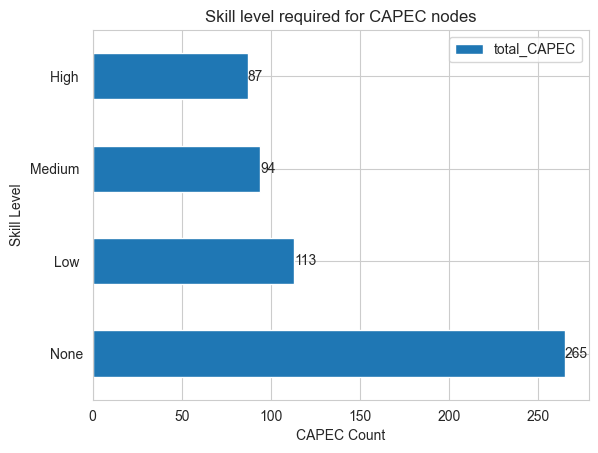

In [57]:
query = """MATCH (n:UcoexCAPEC) 
RETURN count(DISTINCT n) as total_CAPEC, split(n.ucoexSkills_Required[0], [':', '-'])[1] as Skill_Level
ORDER BY total_CAPEC DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Skill_Level', y='total_CAPEC', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Skill level required for CAPEC nodes')
plt.xlabel('CAPEC Count')
plt.ylabel('Skill Level')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CAPEC   Severity
0          211       High
1          112     Medium
2          103        Low
3           59  Very High
4            4   Very Low


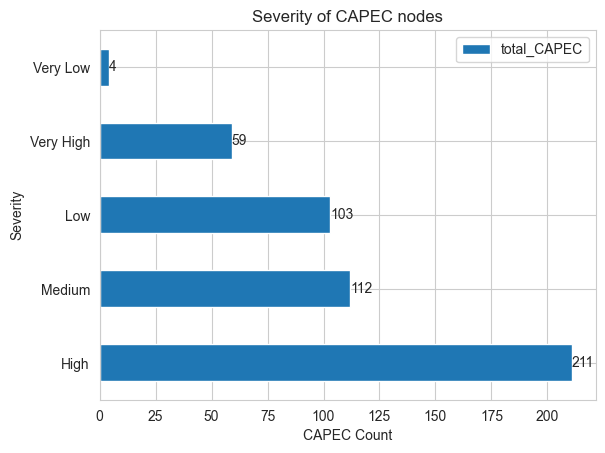

In [58]:
query = """MATCH (n:UcoexCAPEC) 
WHERE n.ucoexSeverity <> ''
RETURN count(DISTINCT n) as total_CAPEC, n.ucoexSeverity as Severity
ORDER BY total_CAPEC DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Severity', y='total_CAPEC', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Severity of CAPEC nodes')
plt.xlabel('CAPEC Count')
plt.ylabel('Severity')
plt.show()

# CAPEC Relationships

CAPEC nodes are related to two other nodes: CWE and MITRE Attack. CWEs are often linked to attack patterns due to their exploitation in the attack, and attacks often follow specific patterns

In [59]:
query = """
MATCH (n:UcoexCAPEC)<-[r]-(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n:UcoexCAPEC)-[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
"""

params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoexCAPEC,UCOEXHASTAXONOMYMAPPING,UcoexMITREATTACK,271
1,UcoexCAPEC,UCOEXHASRELATEDWEAKNESS,UcoCWE,1212


|Source Node| Relationship|Direction|Target Node| Count
|-----------|-------------|---------|-----------|------
| UcoexCAPEC | UCOEXHASTAXNOMYMAPPING| Outgoing | UcoexMITREATTACK | 271
| UcoexCAPEC | UCOEXHASRELATEDWEAKNESS | Outgoing | UcoCWE | 1212

We can also see how many CAPEC nodes are related to Attack node and CWE nodes

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


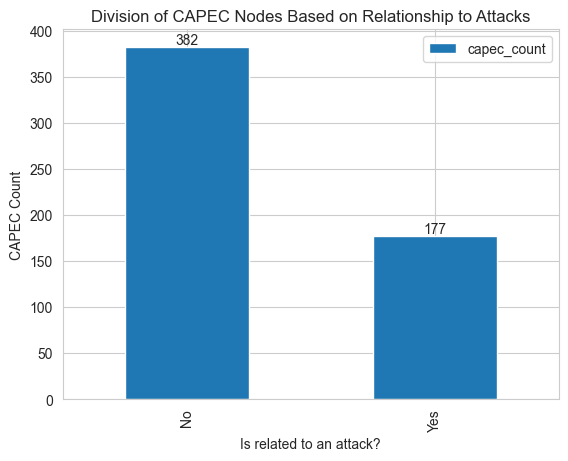

In [60]:
query = """
MATCH (n:UcoexCAPEC)
OPTIONAL MATCH (n)-[UCOEXHASTAXNOMYMAPPING]->(w:UcoexMITREATTACK)
RETURN COUNT(DISTINCT n) as capec_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_attack
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_attack', y='capec_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC Nodes Based on Relationship to Attacks')
plt.xlabel('Is related to an attack?')
plt.ylabel('CAPEC Count')
plt.show()

| Related to Attack | Description | Count
|-------------------|-------------|------
| Yes | The CAPEC is related to a MITRE ATTACK node | 177
| No | The CAPEC is not related to a MITRE ATTACK node | 382

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


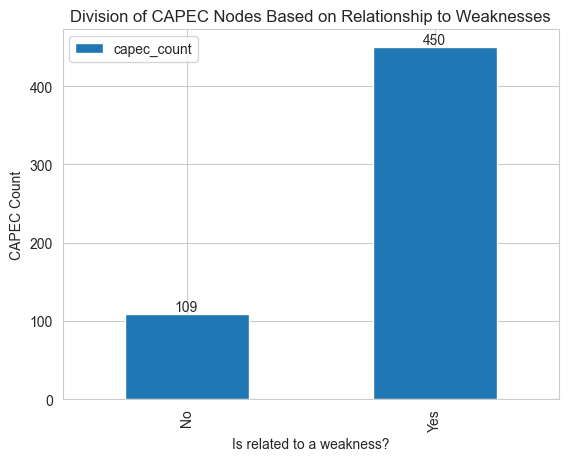

In [61]:
query = """
MATCH (n:UcoexCAPEC)
OPTIONAL MATCH (n)-[UCOEXHASRELATEDWEAKNESS]->(w:UcoCWE)
RETURN COUNT(DISTINCT n) as capec_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_weakness
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_weakness', y='capec_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC Nodes Based on Relationship to Weaknesses')
plt.xlabel('Is related to a weakness?')
plt.ylabel('CAPEC Count')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


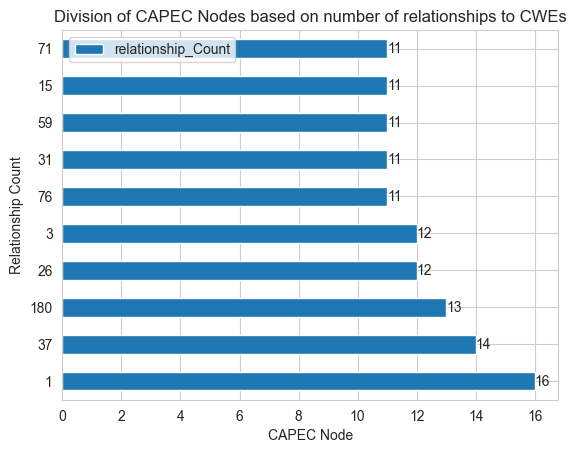

In [62]:
query = """
MATCH (n:UcoexCAPEC)-[r:UCOEXHASRELATEDWEAKNESS]->(w:UcoCWE)
RETURN  n.ucoexCAPEC_id as CAPEC, COUNT(DISTINCT r) as relationship_Count
ORDER BY relationship_Count DESC
LIMIT 10
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='CAPEC', y='relationship_Count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Division of CAPEC Nodes based on number of relationships to CWEs')
plt.xlabel('CAPEC Node')
plt.ylabel('Relationship Count')
plt.show()

| Related to Attack | Description | Count
|-------------------|-------------|------
| Yes | The CAPEC is related to a weakness | 450
| No | The CAPEC is not related to a weakness | 109

Based on the graphs presented, most CAPEC nodes are in some way related to a weakness, but most of the CAPEC nodes are not related to a MITRE ATTACK.

We can also see how many CVEs are related to CAPEC nodes following the same chain with CWEs.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


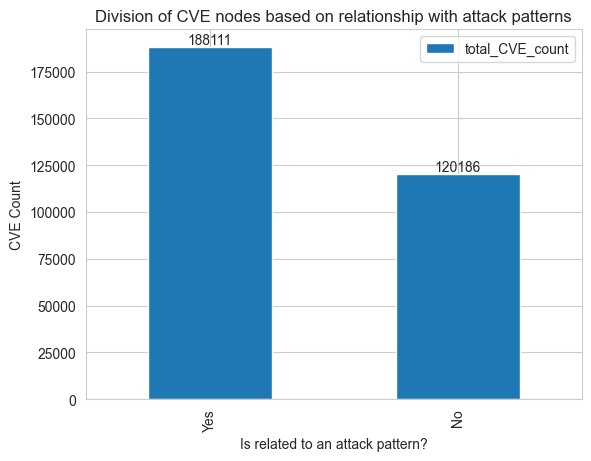

In [63]:
query = """
MATCH (n:UcoCVE)
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOEXHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
RETURN count(DISTINCT n) as total_CVE_count,
CASE
    WHEN c IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_attack_pattern
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_attack_pattern', y='total_CVE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of CVE nodes based on relationship with attack patterns')
plt.xlabel('Is related to an attack pattern?')
plt.ylabel('CVE Count')
plt.show()

# MITRE NODES

The MIRTE nodes contain information about attacks, techniques, and procdeures doen to defend against these attacks. This section will be structured differently as this will contain information about a group of nodes rather than just one. The nodes included in this section are as follows:

- UcoexMITREATTACK
- UcoexMITREDEFEND
- UcoexSOFTWARE
- UcoexTACTICS
- UcoexMITIGATIONS
- UcoexGROUPS
- UcoexCAMPIGNES

These seven nodes each hold their own small list of properties and relationships, therefore, these nodes need to be looked at both seperately and together

# MITRE NODES OVERVIEW

This section will provide an overview of the MITRE nodes structure. To begin this section, a count for each of the seven nodes is gathered.

In [64]:
query = """
WITH ['MITRE', 'GROUPS', 'CAMPAIGNS', 'SOFTWARE', 'TACTICS', 'MITIGATIONS'] as keywords
MATCH (n)
WHERE labels(n)[1] CONTAINS 'Uco' AND ANY(keyword IN keywords WHERE  labels(n)[1] CONTAINS keyword)
RETURN labels(n)[1] as MITRE_Node_Type, COUNT(DISTINCT n) as MITRE_node_count
ORDER BY MITRE_node_count DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,MITRE_Node_Type,MITRE_node_count
0,UcoexMITREATTACK,884
1,UcoexSOFTWARE,877
2,UcoexMITRED3FEND,248
3,UcoexGROUPS,170
4,UcoexMITIGATIONS,108
5,UcoexCAMPAIGNS,50
6,UcoexTACTICS,38


|    MITRE Node    |                           Description                                | Node Count |
|------------------|----------------------------------------------------------------------|------------|
| UcoexMITREATTACK | Describes a type of attack and how it occurs                         |   884
| UcoexSOFTWARE    | Describes software that was affected by an attack                    |   877
| UcoexMITRED3FEND | Describes methods used to defend against attacks                     |   248
| UcoexGROUPS      | Describes known groups of attackers that have committed cyberattacks |   170
| UcoexMITIGATIONS | Describes ways that attacks can be prevented                         |   108
| UcoexCAMPAIGNS   | Describes known cyberattack campaigns that have occured              |    50
| UcoexTACTICS     | Describes motives for carrying out attacks                          |    38


Along with describing each of the nodes in this section, the relationships will also quickly be recaped to show how MITRE nodes relate to each other

In [65]:
query = """
WITH ['MITRE', 'GROUPS', 'CAMPAIGNS', 'SOFTWARE', 'TACTICS', 'MITIGATIONS'] as keywords
MATCH (n)<-[r]-(c)
WHERE labels(n)[1] CONTAINS 'Uco' AND ANY(keyword IN keywords WHERE  labels(n)[1] CONTAINS keyword)
RETURN labels(n)[1] as Starting_Node, type(r) as Relationship, labels(c)[1] as Target_Node, COUNT(DISTINCT r) as Relationship_count
ORDER BY Relationship_count DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Starting_Node,Relationship,Target_Node,Relationship_count
0,UcoexMITREATTACK,UCOEXSOFTWAREUSESTECHNIQUE,UcoexSOFTWARE,11514
1,UcoexMITREATTACK,UCOEXGROUPUSESTECHNIQUE,UcoexGROUPS,4095
2,UcoexMITREATTACK,UCOEXMITIGATES,UcoexMITIGATIONS,1915
3,UcoexSOFTWARE,UCOEXGROUPUSESSOFTWARE,UcoexGROUPS,1064
4,UcoexMITREATTACK,UCOEXCAMPAIGNUSESTECHNIQUE,UcoexCAMPAIGNS,1009
5,UcoexMITREATTACK,UCOEXHASTAXONOMYMAPPING,UcoexCAPEC,271
6,UcoexMITREATTACK,UCOEXHASMITREATTACK,UcoexMITRED3FEND,193
7,UcoexSOFTWARE,UCOEXCAMPAIGNUSESSOFTWARE,UcoexCAMPAIGNS,144
8,UcoexGROUPS,UCOEXATTRIBUTEDTO,UcoexCAMPAIGNS,24


# MITRE ATTACK

Mitre attack nodes are nodes that describe cyberattacks that have occured and their notable characteristics. These nodes are considered the basis of the MITRE nodes and have the most relationships to other nodes in the MITRE group.

Below lists the properties of the MITRE attack node

In [66]:
query = """
MATCH (n:UcoexMITREATTACK)
UNWIND keys(n) AS key
RETURN DISTINCT key
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,key
0,ucoexDESCRIPTION
1,ucoexNAME
2,uri
3,ucoexURL
4,ucoexDOMAIN


|     Property     | Description |
|------------------|-------------|
| ucoexDESCRIPTION | Describes what the attack is and how it works
| ucoexName        | Names the attack and describes what the attack is
| uri              | A link to the example of the attack
| ucoexURL         | A link to the attack in the MITRE ATTACK database
| ucoexDOMAIN      | lists the domain that the attack affected

As seen above, MITREATTACK nodes have very few properties that can be analyzed. There, is however one property that can be analyzed and observed. ucoexDOMAIN is used to describe what type of platform or industry was affected by the attack, such as enterprises or mobile devices for example. Below divides the MITREATTACK nodes by their domain.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


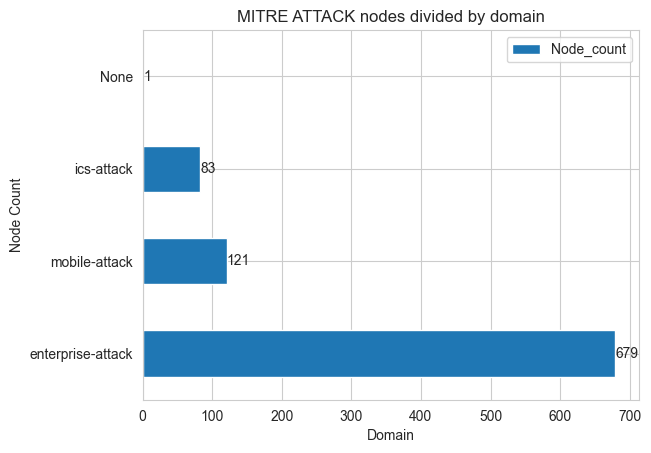

In [67]:
query = """
MATCH (n:UcoexMITREATTACK)
RETURN count(n) as Node_count, n.ucoexDOMAIN as Domain
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Domain', y='Node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('MITRE ATTACK nodes divided by domain')
plt.xlabel('Domain')
plt.ylabel('Node Count')
plt.show()

|   Domain   |                     Description                           | Node Count |
|------------|-----------------------------------------------------------|------------|
| Enterprise | The attack affected a business or corporation             |   679
| Mobile     | The attack affected mobile devices                        |   121
| ICS        | The attack affected industrial or critical infrastructure |    83
| None       | A domain was not listed                                   |     1

MITRE ATTACK nodes by far contain the most relationships to other nodes. This makes sense as these nodes are often considered the baseline for the rest of the nodes present in the MITRE group. These nodes also connect to CAPEC nodes, which serve as the bridge between the MITRE nodes and the Vulnerability database nodes

In [68]:
query = """
MATCH (n:UcoexMITREATTACK) -[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n)-[r]->(m:UcoexMITREATTACK)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
ORDER BY Relationship_Count DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoexSOFTWARE,UCOEXSOFTWAREUSESTECHNIQUE,UcoexMITREATTACK,11514
1,UcoexGROUPS,UCOEXGROUPUSESTECHNIQUE,UcoexMITREATTACK,4095
2,UcoexMITIGATIONS,UCOEXMITIGATES,UcoexMITREATTACK,1915
3,UcoexCAMPAIGNS,UCOEXCAMPAIGNUSESTECHNIQUE,UcoexMITREATTACK,1009
4,UcoexCAPEC,UCOEXHASTAXONOMYMAPPING,UcoexMITREATTACK,271
5,UcoexMITRED3FEND,UCOEXHASMITREATTACK,UcoexMITREATTACK,193


|     Source Node     |        Relationship        | Direction |    Target Node   | Count |
|---------------------|----------------------------|-----------|------------------|-------|
| UcoexSOFTWARE       | UCOEXSOFTWAREUSESTECHNIQUE | Outgoing  | UcoexMITREATTACK | 11514 |
| UcoexGROUPS         | UCOEXGROUPUSESTECHNIQUE    | Outgoing  | UcoexMITREATTACK |  4095 |
| UcoexMITIGATIONS    | UCOMITIGATES               | Outgoing  | UcoexMITREATTACK |  1915 |
| UcoexCAMPAIGNS      | UCOEXCAMPAIGNUSESTECHNIQUE | Outgoing  | UcoexMITREATTACK |  1009 |
| UcoexCAPEC          | UcoexHASTAXNOMYMAPPING     | Outgoing  | UcoexMITREATTACK |   271 |
| UcoexMITRED3FEND    | UCOEXHASMITREATTACK        | Outgoing  | UcoexMITREATTACK |   193 |            
| UcoexMITREATTACK    | (all)                      | Undirected|      Mixed       | 18997 |


# UcoexSOFTWARE

Software nodes are meant to describe the type of software that are used to conduct cyberattacks. These nodes are heavily tied to the MITRE attack nodes due to their involvement in attacks, therefore its important to understand the types of software that is used. Below are the properties of the Software nodes:

|     Property     | Description |
|------------------|-------------|
| ucoexDESCRIPTION | Describes what the software is and how it is utilized
| ucoexName        | Gives the name of the software
| uri              | A link to the example of the doftware
| ucoexURL         | A link to the software in the MITRE ATTACK database
| ucoexDOMAIN      | lists the domain that the software affects

The ucoexName property lists the name of the software that was used in the attack. With this name we can see how many different types of software have been utilized in attacks

In [69]:
query = """
MATCH (n:UcoexSOFTWARE)
RETURN count(n.ucoexNAME) as Software_count
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Software_count
0,877


| Software Count|
|---------------|
|877|

The domain property also describes what types of attacks the software was used in. Software is a bit different, as one piece of software can be involved in multiple categories of attacks.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


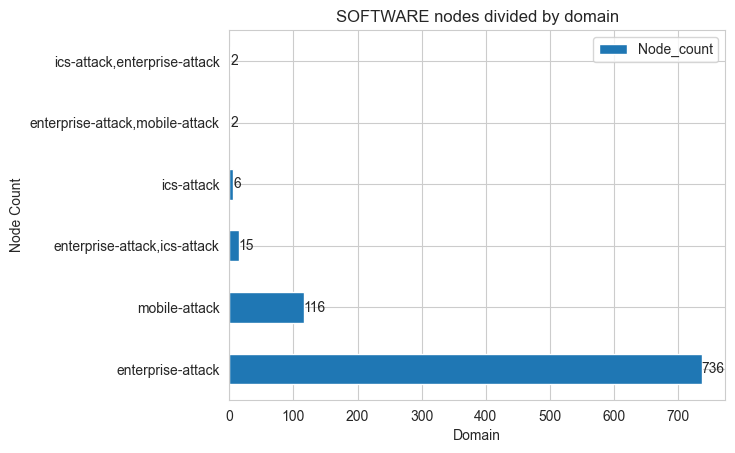

In [70]:
query = """
MATCH (n:UcoexSOFTWARE)
RETURN count(n) as Node_count, n.ucoexDOMAIN as Domain
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Domain', y='Node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('SOFTWARE nodes divided by domain')
plt.xlabel('Domain')
plt.ylabel('Node Count')
plt.show()

|   Domain   |                     Description                           | Node Count |
|------------|-----------------------------------------------------------|------------|
| Enterprise | The software affected a business or corporation             |   753
| Mobile     | The software affected mobile devices                        |   118
| ICS        | The software affected industrial or critical infrastructure |    21

SOFTWARE nodes are only related to MITRE ATTACK nodes. As shown earlier, their relationship is outgoing to the ATTACK node, showing that the software was utilized in the attack. 

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


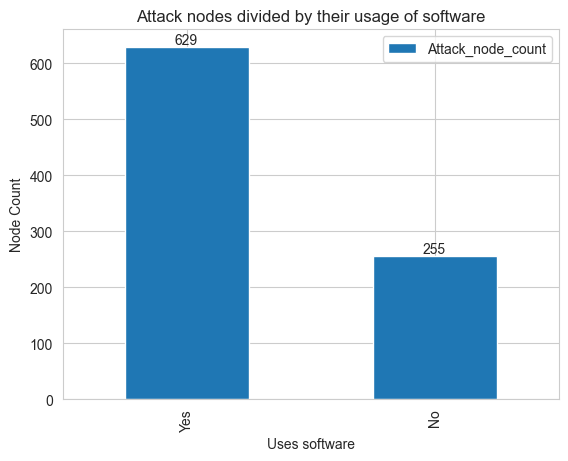

In [71]:
query = """
MATCH (m:UcoexMITREATTACK)
OPTIONAL MATCH (m)<-[UCOEXSOFTWAREUSESTECHNIQUE]-(n:UcoexSOFTWARE)
RETURN COUNT(DISTINCT m) as Attack_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Utilized_software
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Utilized_software', y='Attack_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Attack nodes divided by their usage of software')
plt.xlabel('Uses software')
plt.ylabel('Node Count')
plt.show()

| Uses Software? | Description | Count |
|----------------|---------------------------------------------------------|-------|
| Yes            | The attack node utilizes software in its attack         | 629
| No             | The attack node does not utilize software in its attack | 255

# UcoexMITRED3FEND

Mitre defend nodes are nodes that describe known defenses that can be used against attack. These nodes are rather simply, only really listing the actual defense. The properties are listed below.

|     Property     | Description |
|------------------|-------------|
| ucoexMITRED3FEND_DEFINITION | Describes the defense and how it works to defend against attacks
| ucoexMITRED3FEND_LABEL       | Gives the name for the defense
| uri              | A link to the example of the defense

There are a total 248 defense nodes in the graph. These nodes also are only related to MITRE ATTACK nodes, showing if the attack does utilize a defense method. Below shows how many attack nodes are related to defense methods. Unfortunately, very few attack nodes actually are utilizing these defense nodes, meaning that many of these attacks did not have any prior way of defending against an attack


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


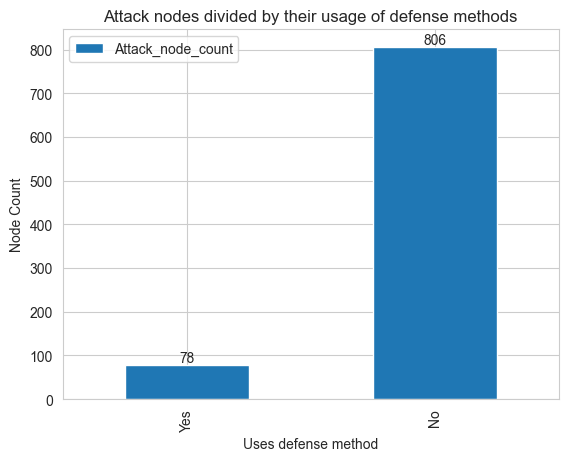

In [72]:
query = """
MATCH (m:UcoexMITREATTACK)
OPTIONAL MATCH (m)<-[UCOEXHASMITREATTACK]-(n:UcoexMITRED3FEND)
RETURN COUNT(DISTINCT m) as Attack_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Utilized_defense
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Utilized_defense', y='Attack_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Attack nodes divided by their usage of defense methods')
plt.xlabel('Uses defense method')
plt.ylabel('Node Count')
plt.show()

| Uses Defense? | Description | Count |
|----------------|---------------------------------------------------------|-------|
| Yes            | The attack node utilized a defense method against an attack      | 78
| No             | The attack node did not utilize a defense method against an attack | 806

# UcoexGROUPS

The UcoexGROUPS nodes describes known groups or individuals that have commited cyberattacks. These groups are the ones that carry out the attacks in the MITRE attack nodes. THese groups may also be associated with attacks that are more coordinated. 
Below are the properties of the GROUP nodes:

|     Property     | Description |
|------------------|-------------|
| ucoexDESCRIPTION | Describes who the group is and what attacks they have caused
| ucoexName        | Gives the name of the group
| uri              | A link to the example of the group
| ucoexURL         | A link to information about the group in MITRE ATTACK
| ucoexDOMAIN      | lists the domain that the group attacked

UcoexGROUPS also contains the domain property, meaning we can also see what types of applications were attacked. Below shows the division of the domains affected by GROUPS.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


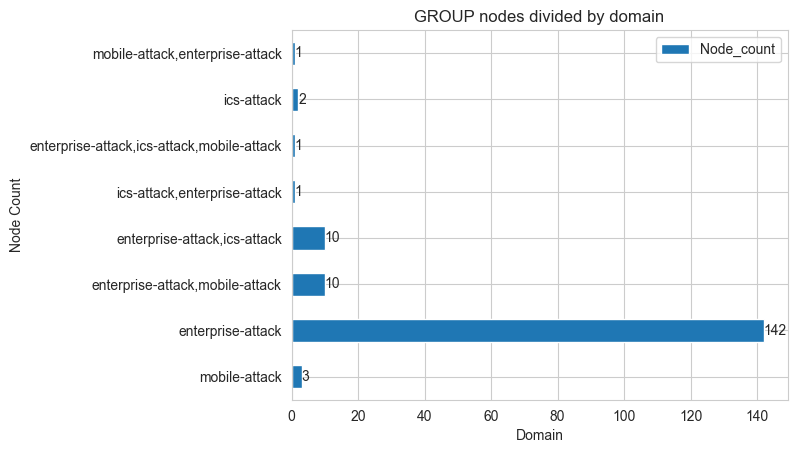

In [73]:
query = """
MATCH (n:UcoexGROUPS)
RETURN count(n) as Node_count, n.ucoexDOMAIN as Domain
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Domain', y='Node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('GROUP nodes divided by domain')
plt.xlabel('Domain')
plt.ylabel('Node Count')
plt.show()

|   Domain   |                     Description                           | Node Count |
|------------|-----------------------------------------------------------|------------|
| Enterprise | The group attacked a business or corporation             |   163
| Mobile     | The group attacked mobile devices                        |    14
| ICS        | The group attacked industrial or critical infrastructure |    14

GROUP nodes are related to MITRE attack nodes as they are the ones responsible for the attacks. However they are also related to SOFTWARE nodes as the groups may use software to carry out their attacks. Groups may also be apart of a campaign of attacks

In [74]:
query = """
MATCH (n:UcoexGROUPS) -[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n)-[r]->(m:UcoexGROUPS)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
ORDER BY Relationship_Count DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoexGROUPS,UCOEXGROUPUSESSOFTWARE,UcoexSOFTWARE,1064
1,UcoexGROUPS,UCOEXGROUPUSESTECHNIQUE,UcoexMITREATTACK,4095
2,UcoexCAMPAIGNS,UCOEXATTRIBUTEDTO,UcoexGROUPS,24


|     Source Node     |        Relationship        | Direction |    Target Node   | Count |
|---------------------|----------------------------|-----------|------------------|-------|
| UcoexSOFTWARE       | UCOEXGROUPUSESSOFTWARE | Incoming | UcoexGROUPS | 1064 |
| UcoexGROUPS         | UCOEXGROUPUSESTECHNIQUE    | Outgoing  | UcoexMITREATTACK |  4095 |
| UcoexCAMPAIGNS    | UCOEXATTRIBUTEDTO               | Incoming  | UcoexGROUPS |  24 |

Below we can see how many attacks were carried out by groups and which groups hold the most attacks and how many groups utilized software. Campagines will be looked at in their own section.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


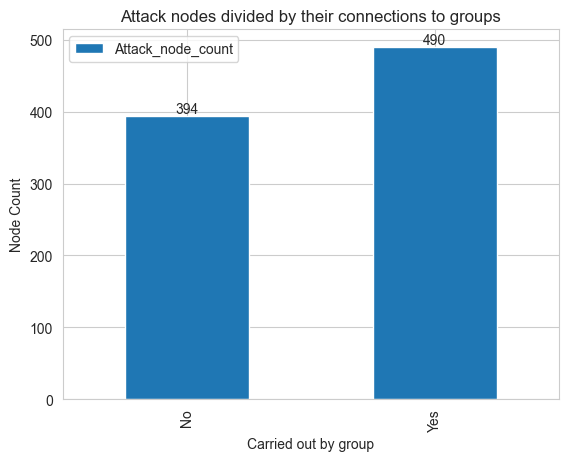

In [75]:
query = """
MATCH (m:UcoexMITREATTACK)
OPTIONAL MATCH (m)<-[UCOEXGROUPUSESTECHNIQUE]-(n:UcoexGROUPS)
RETURN COUNT(DISTINCT m) as Attack_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Group_Attack
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Group_Attack', y='Attack_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Attack nodes divided by their connections to groups')
plt.xlabel('Carried out by group')
plt.ylabel('Node Count')
plt.show()

| Attack caused by group? | Description | Count |
|----------------|---------------------------------------------------------|-------|
| Yes            | The attack node was carried out by a known group     | 490
| No             | The attack node was not carried out by a known group | 394

Below shows the top ten groups that have been connected to the most MITRE attack nodes. Currently the group Kimsuky holds the most attacks with a count of 103.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


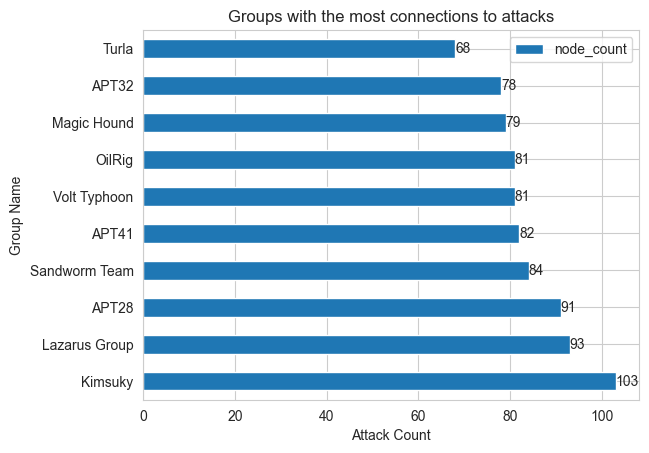

In [76]:
query = """
MATCH (m:UcoexMITREATTACK)<-[UCOEXGROUPUSESTECHNIQUE]-(n:UcoexGROUPS)
RETURN COUNT (DISTINCT m) as node_count, n.ucoexNAME as group_name
ORDER BY node_count DESC
LIMIT 10
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='group_name', y='node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Groups with the most connections to attacks')
plt.xlabel('Attack Count')
plt.ylabel('Group Name')
plt.show()

Below shows the connections groups have to software nodes, showing how groups will sometimes use software to carry out their attacks.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


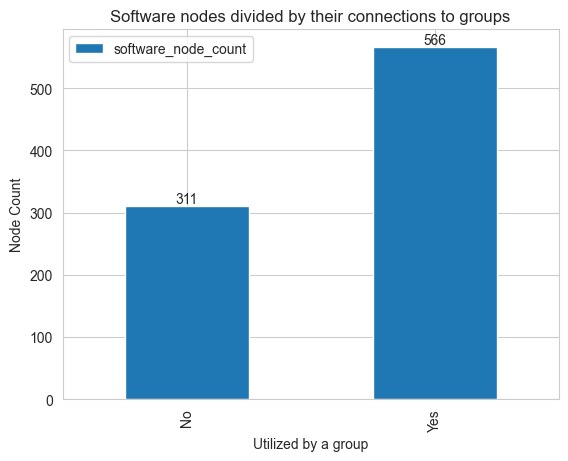

In [77]:
query = """
MATCH (m:UcoexSOFTWARE)
OPTIONAL MATCH (m)<-[UCOEXGROUPUSESSOFTWARE]-(n:UcoexGROUPS)
RETURN COUNT(DISTINCT m) as software_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Group_software
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Group_software', y='software_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Software nodes divided by their connections to groups')
plt.xlabel('Utilized by a group')
plt.ylabel('Node Count')
plt.show()

| Uses Software? | Description | Count |
|----------------|---------------------------------------------------------|-------|
| Yes            | The software was used by a known group     | 566
| No             | The software was not used by a known group | 311

# UcoexMITIGATIONS

Mitigation nodes describe mitigation methods that can be used to prevent attacks before they occur. They are similar to D3FEND nodes with the difference being that defend nodes describe how a defence would work, while Mitigations contain documentation on how to implement defense methods.
The properties of Mitigation nodes are listed below:

|     Property     | Description |
|------------------|-------------|
| ucoexDESCRIPTION | Describes the mitigation and how it should be implemented
| ucoexName        | Gives the name of the mitigation method
| uri              | A link to the example of the mitigation
| ucoexURL         | A link to information about the mitigation in MITRE ATTACK
| ucoexDOMAIN      | lists the domain that the mitigation is defending

MITIGATION nodes also describe the domain that they are meant to protect. Below shows what domains the MITIGATION nodes are connect to


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


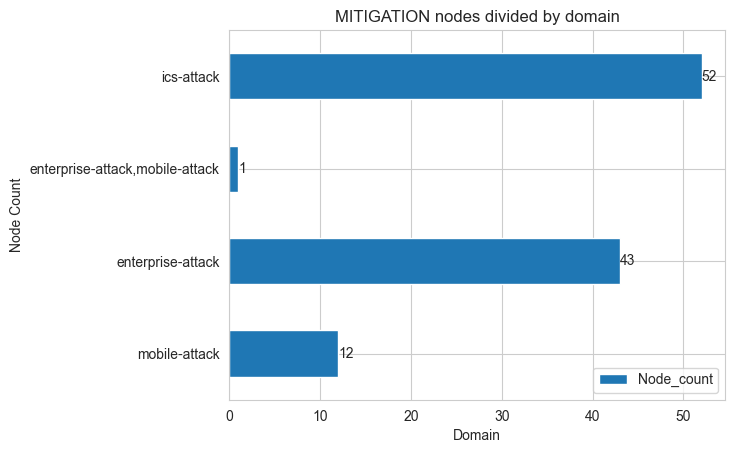

In [78]:
query = """
MATCH (n:UcoexMITIGATIONS)
RETURN count(n) as Node_count, n.ucoexDOMAIN as Domain
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Domain', y='Node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('MITIGATION nodes divided by domain')
plt.xlabel('Domain')
plt.ylabel('Node Count')
plt.show()

|   Domain   |                     Description                           | Node Count |
|------------|-----------------------------------------------------------|------------|
| Enterprise | The mitigation defends a business or corporation             |   44
| Mobile     | The mitigation defends mobile devices                        |   13
| ICS        | The mitigation defends industrial or critical infrastructure |   52

Mitigation nodes are also only related to MITRE ATTACK nodes. Below shows how many attacks have connections to mitigation methods.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


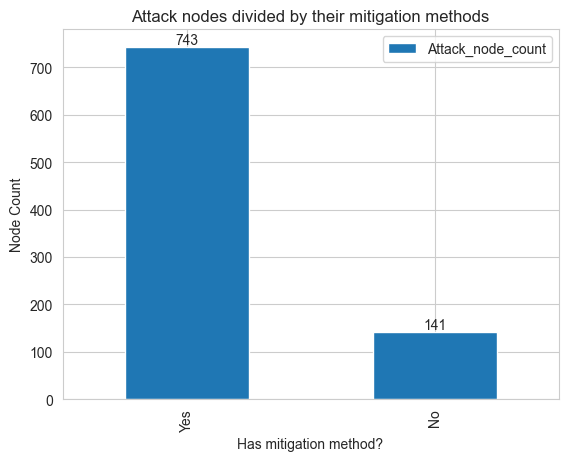

In [79]:
query = """
MATCH (m:UcoexMITREATTACK)
OPTIONAL MATCH (m)<-[UCOEXMITIGATES]-(n:UcoexMITIGATIONS)
RETURN COUNT(DISTINCT m) as Attack_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Has_mitigation
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Has_mitigation', y='Attack_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Attack nodes divided by their mitigation methods')
plt.xlabel('Has mitigation method?')
plt.ylabel('Node Count')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


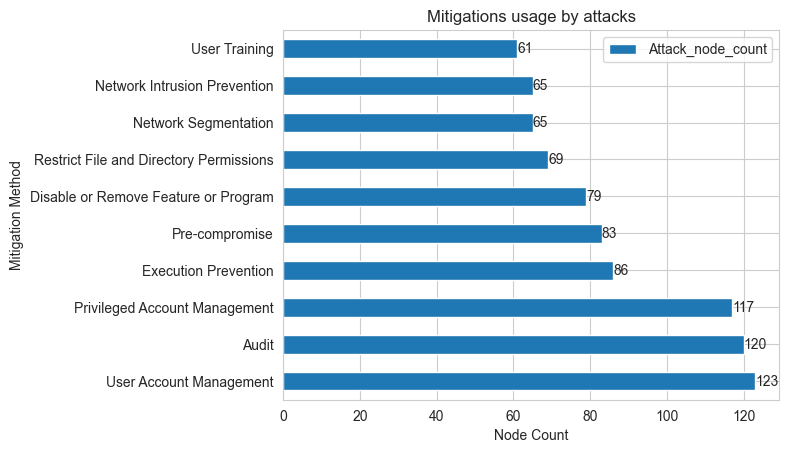

In [80]:
query = """
MATCH (m)<-[UCOEXMITIGATES]-(n:UcoexMITIGATIONS)
RETURN COUNT(DISTINCT m) as Attack_node_count, n.ucoexNAME as Mitgation_Name
ORDER BY Attack_node_count DESC
LIMIT 10
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Mitgation_Name', y='Attack_node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Mitigations usage by attacks')
plt.xlabel('Node Count')
plt.ylabel('Mitigation Method')
plt.show()

| Has Mitigation? | Description | Count |
|----------------|---------------------------------------------------------|-------|
| Yes            | The attack has a mitigation method for defense    | 743
| No             | The attack does not have a mitigation method for defense | 141

# UcoexCAMPAIGNS

CAMPAIGN nodes describe instances of small or large scale coordinated attacks carried out my groups meant to cause lasting impact. Below lists the properties of campaign nodes

|     Property     | Description |
|------------------|-------------|
| ucoexDESCRIPTION | Describes the campaign, what it targeted, and why it occured
| ucoexName        | Gives the name of the campaign
| uri              | A link to the example of the campaign
| ucoexURL         | A link to information about the campaign in MITRE ATTACK
| ucoexDOMAIN      | lists the domain that was targeted in the campaign

The DOMAIN property displays what industry was the target of an attack campaign. Below shows how many campaigns affected each domain.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


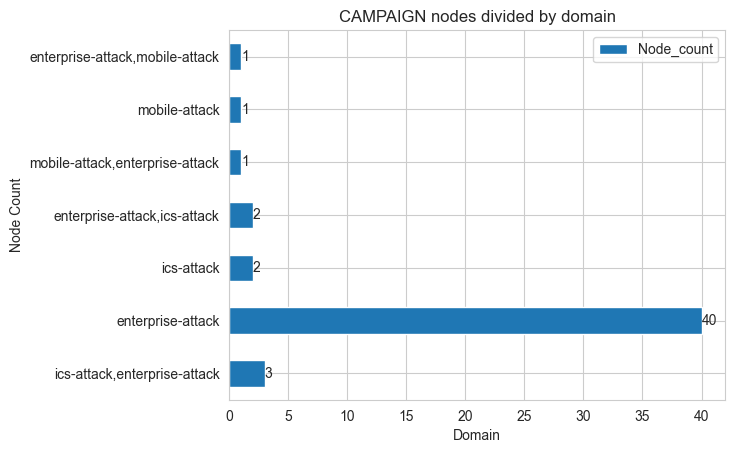

In [81]:
query = """
MATCH (n:UcoexCAMPAIGNS)
RETURN count(n) as Node_count, n.ucoexDOMAIN as Domain
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Domain', y='Node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('CAMPAIGN nodes divided by domain')
plt.xlabel('Domain')
plt.ylabel('Node Count')
plt.show()

|   Domain   |                     Description                           | Node Count |
|------------|-----------------------------------------------------------|------------|
| Enterprise | The campaign targeted a business or corporation             |   46
| Mobile     | The campaign targeted mobile devices                        |    3
| ICS        | The campaign targeted industrial or critical infrastructure |    7

CAMPAIGN nodes are related to MITRE ATTACK nodes as the attacks may have been apart of a campaign. CAMPAIGN nodes are also related to groups as known groups may have been responsible for the campaign. CAMPAIGNS may also utilize software to carry out the attack

In [82]:
query = """
MATCH (n:UcoexCAMPAIGNS) -[r]->(m)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
UNION
MATCH (n)-[r]->(m:UcoexCAMPAIGNS)
RETURN labels(n)[1] as Source_Node, type(r) as Relationship, labels(m)[1] as Target_Node, COUNT(r) as Relationship_Count
ORDER BY Relationship_Count DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Source_Node,Relationship,Target_Node,Relationship_Count
0,UcoexCAMPAIGNS,UCOEXCAMPAIGNUSESTECHNIQUE,UcoexMITREATTACK,1009
1,UcoexCAMPAIGNS,UCOEXCAMPAIGNUSESSOFTWARE,UcoexSOFTWARE,144
2,UcoexCAMPAIGNS,UCOEXATTRIBUTEDTO,UcoexGROUPS,24


|     Source Node     |        Relationship        | Direction |    Target Node   | Count |
|---------------------|----------------------------|-----------|------------------|-------|
| UcoexCAMPAIGNS      | UCOEXATTRIBUTEDTO | Outgoing | UcoexGROUPS |   24 |
| UcoexCAMPAIGNS         | UCOEXCAMPAIGNUSESTECHNIQUE    | Outgoing  | UcoexMITREATTACK |  1009 |
| UcoexCAMPAIGNS    | UCOEXCAMPAIGNUSESSOFTWARE               | Outgoing | UcoexSOFTWARE |  144 |

Now it can be seen how many attack nodes were apart of a campaign, which campaigns had the most attacks, how many campaigns utilized software, which campaigns were carried out by groups, and which groups were responsible for the most campaigns.

Below shows how many attack nodes were related to a campaign.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


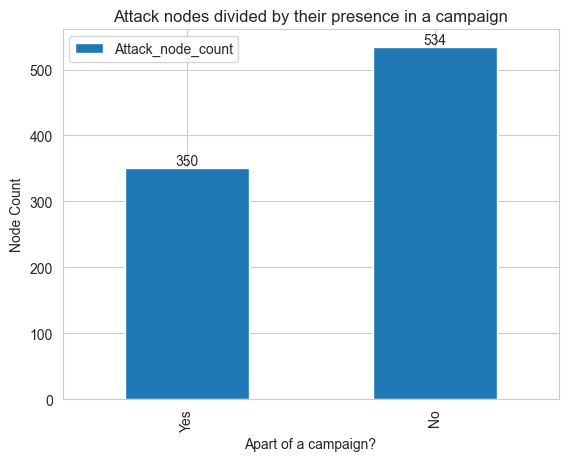

In [83]:
query = """
MATCH (m:UcoexMITREATTACK)
OPTIONAL MATCH (m)<-[UCOCAMPAIGNUSESTECHNIQUE]-(n:UcoexCAMPAIGNS)
RETURN COUNT(DISTINCT m) as Attack_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Had_Campaign
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Had_Campaign', y='Attack_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Attack nodes divided by their presence in a campaign')
plt.xlabel('Apart of a campaign?')
plt.ylabel('Node Count')
plt.show()

| Used in Campaign? | Description | Count |
|----------------|---------------------------------------------------------|-------|
| Yes            | The attack was involved in a campaign    | 350
| No             | The attack was not involved in a campaign | 534

Below shows the top campaign based on hao many attacks were connected to them. Currently a campaign known as the 'solarwinds compromise' contained the most connections to MITRE ATTACK nodes.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


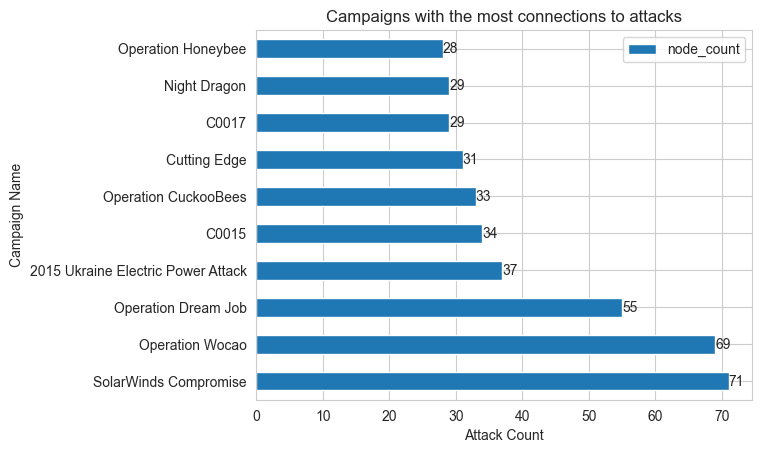

In [84]:
query = """
MATCH (m:UcoexMITREATTACK)<-[UCOEXCAMPAIGNUSESTECHNIQUE]-(n:UcoexCAMPAIGNS)
RETURN COUNT (DISTINCT m) as node_count, n.ucoexNAME as campaign_name
ORDER BY node_count DESC
LIMIT 10
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='campaign_name', y='node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Campaigns with the most connections to attacks')
plt.xlabel('Attack Count')
plt.ylabel('Campaign Name')
plt.show()

Below shows how many campaigns utilized software for their attacks

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


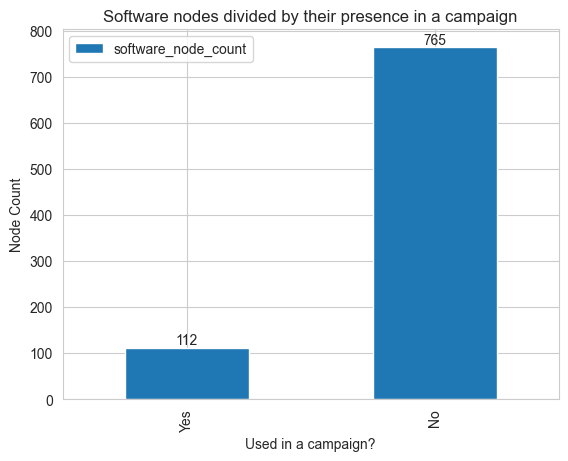

In [85]:
query = """
MATCH (m:UcoexSOFTWARE)
OPTIONAL MATCH (m)<-[UCOCAMPAIGNUSESSOFTWARE]-(n:UcoexCAMPAIGNS)
RETURN COUNT(DISTINCT m) as software_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Had_Campaign
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Had_Campaign', y='software_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Software nodes divided by their presence in a campaign')
plt.xlabel('Used in a campaign?')
plt.ylabel('Node Count')
plt.show()

| Campaign used software? | Description | Count |
|----------------|---------------------------------------|-------|
| Yes            | The software was used in a campaign   | 112
| No             | The software was not used in a campaign | 765

Below shows the top software used in the most campaigns. Currently the software known as Minikatz has been used in 7 total campaigns.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


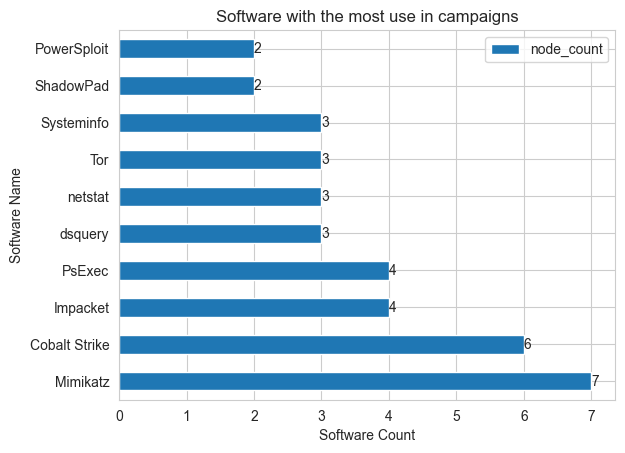

In [86]:
query = """
MATCH (m:UcoexSOFTWARE)<-[UCOEXCAMPAIGNUSESSOFTWARE]-(n:UcoexCAMPAIGNS)
RETURN COUNT (DISTINCT n) as node_count, m.ucoexNAME as software_name
ORDER BY node_count DESC
LIMIT 10
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='software_name', y='node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Software with the most use in campaigns')
plt.xlabel('Software Count')
plt.ylabel('Software Name')
plt.show()

Below shows the amoung of campaigns that were connected to known groups.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


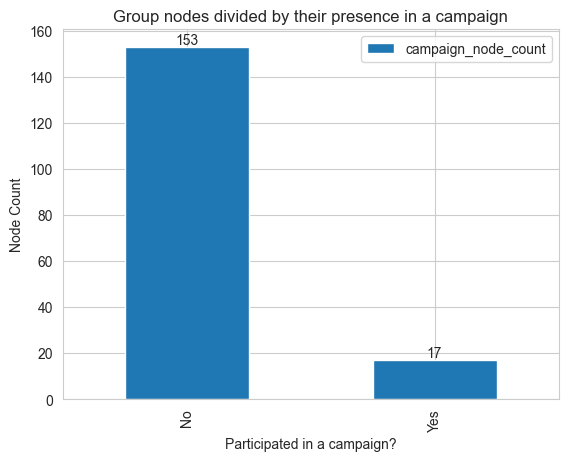

In [87]:
query = """
MATCH (m:UcoexGROUPS)
OPTIONAL MATCH (m)<-[UCOATTRIBUTEDTO]-(n:UcoexCAMPAIGNS)
RETURN COUNT(DISTINCT m) as campaign_node_count,
CASE
    WHEN n IS NULL THEN 'No'
    ELSE 'Yes'
END AS Group_committed
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Group_committed', y='campaign_node_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Group nodes divided by their presence in a campaign')
plt.xlabel('Participated in a campaign?')
plt.ylabel('Node Count')
plt.show()

| Group participated in campaign? | Description | Count |
|----------------|---------------------------------------|-------|
| Yes            | The group was apart of a campaign   |  17
| No             | The group was not apart of a campaign | 153

# UcoexTACTICS

Tactic nodes describe different tactics that can be used to help carry out attacks. The properties of Tactic nodes are below:

|     Property     | Description |
|------------------|-------------|
| ucoexDESCRIPTION | Describes the tactic, how it works and how it can be used
| ucoexName        | Gives the name of the tactic
| uri              | A link to the example of the tactic
| ucoexURL         | A link to information about the tactic in MITRE ATTACK
| ucoexDOMAIN      | lists the domain that was targeted using the tactic

Below shows the division of tactics by their targeted domains

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


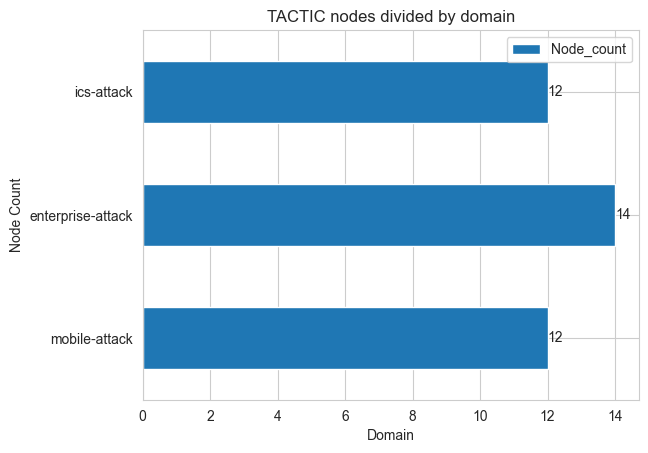

In [88]:
query = """
MATCH (n:UcoexTACTICS)
RETURN count(n) as Node_count, n.ucoexDOMAIN as Domain
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

ax = df.plot(x='Domain', y='Node_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('TACTIC nodes divided by domain')
plt.xlabel('Domain')
plt.ylabel('Node Count')
plt.show()

|   Domain   |                     Description                           | Node Count |
|------------|-----------------------------------------------------------|------------|
| Enterprise | The tactic targeted a business or corporation             |   14
| Mobile     | The tactic targeted mobile devices                        |   12
| ICS        | The tactic targeted industrial or critical infrastructure |   12

Unfortunately, this is as far as the analysis can go for tactic nodes. this is because TACTIC nodes currently do not contain any relationships to any other nodes. This will likely be changed in the near future, but for now we can see what TACTIC nodes are likely to be related to based on their connections in the MITRE database.

Tactics in the MITRE database as listed as TA entries. The tactic page is set up that for each tactic, there contains a list of techniques that used the tactic.
Currently these are the three nodes that tactic seems to be related to. Therefore its likely that in future updates to the knowledge graph, UcoexTACTICS nodes will be related to these nodes

# MITRE EXTENSIVE ANALYSIS

This section is meant to show a bit more extensive analysis for the MITRE nodes.

Some attacks are related to large amounts of group and campaign nodes, meaning the type of attack has been used quiet extensively. These nodes may also not be related to as many mitigations or defenses, meaning that there are few methods in place to prevent that specific attacks. With this in mind, the different attacks can be scored based on the number of relationships to these four nodes. It would be combined as
- Mitigation and defense nodes as the total number of defenses against the attack
- groups and campaigns nodes as the total number of times the attack was utilized
These values can be subtracted to get a score. The lower the score, the few defenses the attack has and the more it has been utilized

In [89]:
query = """
MATCH (n:UcoexMITREATTACK)
OPTIONAL MATCH (n) <- [UCOEXMITIGATES]- (m:UcoexMITIGATIONS)
OPTIONAL MATCH (n) <- [UCOEXHASMITREATTACK]-(d:UcoexMITRED3FEND)
OPTIONAL MATCH (n) <- [UCOEXCAMPAIGNUSESTECHNIQUE]-(c:UcoexCAMPAIGNS)
OPTIONAL MATCH (n) <- [UCOEXGROUPUSESTECHNIQUE]-(g:UcoexGROUPS)
RETURN
n.ucoexNAME as Attack,
count(DISTINCT c) + count(DISTINCT g) as total_use,
count(DISTINCT m) + count(DISTINCT d) as total_defense,
(count(DISTINCT m) + count(DISTINCT d)) - (count(DISTINCT c) + count(DISTINCT g))  as defense_score
ORDER BY defense_score DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Attack,total_use,total_defense,defense_score
0,Adversary-in-the-Middle,4,17,13
1,Module Firmware,0,12,12
2,System Firmware,2,13,11
3,Unsecured Credentials,2,12,10
4,Hijack Execution Flow,2,12,10
...,...,...,...,...
802,Command and Scripting Interpreter: Windows Com...,82,1,-81
803,Command and Scripting Interpreter: PowerShell,94,5,-89
804,User Execution: Malicious File,94,3,-91
805,Obtain Capabilities: Tool,96,1,-95


This dataset shows the scores the attacks can get. As seen above, The attacks at the bottom of the table are those with the worse defense scores, meaning they
- have little to no defense methods (mitigations or defenses)
- have high usage among groups and campaigns
These attacks are highly vital to address as it means that these attacks are being used more often and have not been properly defended against.

Low mitigation methods are a large reason for the large usage for attacks. Its important to see which attacks currently DO NOT have any sort of mitigation method in place. The code cell below will grab all attacks that are NOT related to any mitigation or detection methods

In [90]:
query = """
MATCH (n:UcoexMITREATTACK) 
WHERE NOT EXISTS {
    MATCH (n)<-[:UCOEXMITIGATES]-()
}
AND NOT EXISTS {
    MATCH (n)<-[:UCOEXHASMITREATTACK]-()
}
AND n.ucoexNAME <> 'None'
RETURN DISTINCT n.ucoexNAME as Attack;
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Attack
0,Permission Groups Discovery: Cloud Groups
1,Permission Groups Discovery: Local Groups
2,Permission Groups Discovery: Domain Groups
3,Account Manipulation: Additional Local or Doma...
4,System Location Discovery: System Language Dis...
...,...
117,Web Service
118,Resource Hijacking
119,Network Denial of Service
120,Network Service Scanning


As seen above, 122 attack nodes do NOT have any relationship to mitigation methods or defense methods. This means these attacks do not have any current ways to defend against them if the attack was carried out. This is relatively dangerous, but we can also compare these nodes to their relationships to other nodes to see
- are these attacks associated with any attack patterns
- are any weaknesses attached to theses attacks
- how many vulnerabilities can cause these attacks

The following will show how many attack patterns involve the usage of any of these 122 attacks

In [91]:
query = """
MATCH (n:UcoexMITREATTACK) <-[UCOEXHASTAXNOMYMAPPING]-(c:UcoexCAPEC)
WHERE NOT EXISTS {
    MATCH (n)<-[:UCOEXMITIGATES]-()
}
AND NOT EXISTS {
    MATCH (n)<-[:UCOEXHASMITREATTACK]-()
}
AND n.ucoexNAME <> 'None'
RETURN COUNT(DISTINCT c) as CAPEC_count
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CAPEC_count
0,32


32 attack patterns are associated with these attacks with no mitigations or defenses. While the number of attack patterns is small compared to 559 CAPEC nodes present in the graph, they still are attached to these attack nodes and are relatively dangerous because of this. 

From here it can be seen how many of these attack patterns are attached to weaknesses.

In [92]:
query = """
MATCH (n:UcoexMITREATTACK) <-[UCOEXHASTAXNOMYMAPPING]-(c:UcoexCAPEC)-[UCOEXHASRELATEDWEAKNESS]->(w:UcoCWE)
WHERE NOT EXISTS {
    MATCH (n)<-[:UCOEXMITIGATES]-()
}
AND NOT EXISTS {
    MATCH (n)<-[:UCOEXHASMITREATTACK]-()
}
AND n.ucoexNAME <> 'None'
RETURN COUNT(DISTINCT w) as CWE_count
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CWE_count
0,27


Suprisingly, only 32 out of the 969 weaknesses are linked to attacks with no defense methods. This number is low and shows that the majority of weaknesses that have caused attacks do have some defense methods to protect against attacks. However, it still needs to be seen how many CVEs are attached to these attacks

In [93]:
query = """
MATCH (n:UcoexMITREATTACK)<-[UCOEXHASTAXNOMYMAPPING]-(c:UcoexCAPEC)-[UCOEXHASRELATEDWEAKNESS]->(w:UcoCWE)<-[UCOHASWEAKNESS]-(t:UcoExploitTarget)-[UCOHASVULNERABILITY]->(x:UcoVulnerability)-[UCOHASCVE_ID]->(v:UcoCVE)
WHERE NOT EXISTS {
    MATCH (n)<-[:UCOEXMITIGATES]-()
}
AND NOT EXISTS {
    MATCH (n)<-[:UCOEXHASMITREATTACK]-()
}
AND n.ucoexNAME <> 'None'
RETURN COUNT(DISTINCT v) as CVE_count
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CVE_count
0,30753


According to the graph, 30753 vulnerabilities are connected to attacks that do NOT have any mitigation or defense methods. This means that if these vulnerabilities were in fact exploited, there would be no methods in place to defend against the exploit and the attacker would have no roadblocks in exploitation.

# UCKG Data Science Analysis: Trends of Operating System Vulnerabilities

## Peyton Bubert - CS 4330 - Dr. Edrogan Dodgu - edrogan.dodgu@angelo.edu

## Description
There has been a noticeable rise in the number of cyberattacks that have occurred due to vulnerabilities in the last few years. Using vulnerabilities, attackers are able to exploit them to cause a variety of different problems, including compromising information, running malicious code, and breaking affected applications. One major target of these attacks are operating systems, which are vital programs that make up the software structure of any computer system. These systems, because of their connection with the hardware and major software of a computer can lead to major damage if vulnerabilities are discovered and exploited. It may seem simple to just find and fix the vulnerability, however vulnerabilities themselves are a lot more complicated upon second glance.

This proposal seeks to answer the following questions:
- Are vulnerabilities involving operating systems becoming more common?
- What are the noticeable characteristics involving OS vulnerabilities?
- Are there any noticeable or alarming trends with OS related vulnerabilities?
These questions will be answered in order to show the current state of operating system vulnerabilities and attacks. This analysis can prove useful when trying to understand which measures can be taken to help prevent OS vulnerabilities from being exploited and how dangerous these exploits might be. An understanding of what vulnerabilities affect operating systems and how they occur will help to aid efforts in protecting against future cyberattacks.

# Dataset

In this project four main datasets will be used. Each of these node sets are derived from two databases: the National Vulnerability database and the MITRE database. THe node sets that will be utilized are as followes

- CVE
- CPE
- CWE
- CAPEC

These node sets will be utilized in both exploration to answer the questions previously mentions, along with seeing how this data can be utilized in machine learning models to make predictions with the data.

Its important to see how big the datasets are that are being used. Each of these datasets contain hundreds to thousands of entries, however only the entires linked to operating systems are being utilized.

CPEs contain the information regarding products, including the key property that shows if the affected product is an operating system. Other nodes from different node sets are gathered based on the relationship with these nodes.

The following code cells gather all of the data that will be used


In [94]:
query = """
MATCH (n:UcoexCPE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN COUNT(DISTINCT n) as total_CPE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

   total_CPE_count
0            56343


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


In [95]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT v) as CVE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CVE_count
0,74275


In [96]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT w) as CWE_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CWE_count
0,512


In [97]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT c) as CAPEC_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CAPEC_count
0,432


|  Node  | Node Count |                                 Description                                 |
|--------|------------|-----------------------------------------------------------------------------|
| CPE    | 56343      | Node database that contains information about products affected by exploits |
| CVE    | 74275      | Node database that contains information about reported vulnerabilities      |
| CWE    |   512      | Node database that describes weaknesses and their mitigations               |
| CAPEC  |   432      | Node database that describes attack patterns and their mitigations          |

The table above shows the counts for all four databases that will be used in this analysis. The node counts displays now many entries in each database will be referenced. Every single entry, in some way, is related to an operating system, whether it be an OS weakness or a vulnerability.

CVEs, which list the vulnerabilities, contain the most data with almost 75 thousand entries related to operating systems. CPEs contain 56 thousand nodes. CWE and CAPEC contain far fewer nodes that are related to operating systems, however those datasets are relatively smaller. Currently in the graph there are only 969 CWE nodes, for example, and nearly half of the entries were gathered. So while CWE and CAPEC contin far less data, it still consists of the majority of their datasets.

## Data Cleanup

With the data now gathered we can prepare it for exploration. Most of the cleanup has already been done by only gathering the nodes related to Operating systems and leaving out any unrelated nodes. However there still is a little bit of cleanup to be done.

Firstly, the CVE dataset has a property that shows the severity of the vulnerability. However, due to a current error in the graph, some of these nodes have a blank entry. These nodes arent completely cut, as they still contain important information for other analysis, but for any analysis involving severity, they will have to be cut. Out of the 74275 CVE nodes that will be used, 48529 nodes do not have this error and contain a severty score. THis does cut a portion of the nodes, but there are still plenty that can be used.

The same also occurs with CAPEC nodes, as sometimes they have two properties that can be empty. The first is CAPEC severity, which is a severity ranking for the attack pattern. THe second is the likelihood property that shows the likelihood an attack will occur. When analyzing these two properties, the empty values will have to be cut, but with analysis not involving those properties, they can still be included. Out of the 432 nodes, 47 nodes have an empty severity property, and 162 of the nodes have an empty Likelihood property. 

Overall, these empty properties will need to be kept in mind when doing analysis on specific data in the nodes. While these nodes will be excluded in analysis that includes the properties, they wont be outright removed as the nodes still contain valuable information that, when removed, can hurt results.

# Exploration

The following section explores the knowledge graph to gather needed data to answer the questions. Currently, the following nodes of the knowledge will help in providing the most information:
- CVE
- CPE
- CWE
- CAPEC

These four datasets will help provide the needed information see any trends with Operating systems.

Now that all of the nodes that will be used have been gathered, connections can now be made between the databases. To get started, analysis will first be done between CPEs and CVEs as that will help to provide starter information about the OS vulnerabilities.

First, using the CVE label we can see how many OS vulnerabilities have been reported each year.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


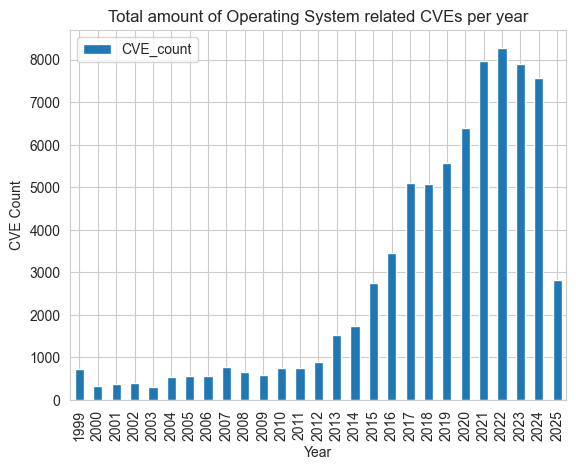

,CVE_count
count,27.000000
mean,2750.925926
std,2837.284589
min,301.000000
25%,569.500000
50%,885.000000
75%,5089.000000
max,8282.000000


In [98]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT v) as CVE_count, split(v.label, '-')[1] as Year
ORDER BY Year ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

df.plot(x='Year', y='CVE_count', kind='bar')
plt.title('Total amount of Operating System related CVEs per year')
plt.xlabel('Year')
plt.ylabel('CVE Count')
plt.show()

df.describe()

As seen above, the figure is left-skewed, meaning mose of the entries favor the left side. This means that CVEs related to operating systems have seen a major increase in the past few years. The increase in OS related CVEs appeared to start around 2017, where a large upset was observed. 

Next we can analyze the severity of these CVEs to see how severe these vulnerabilities usually were.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


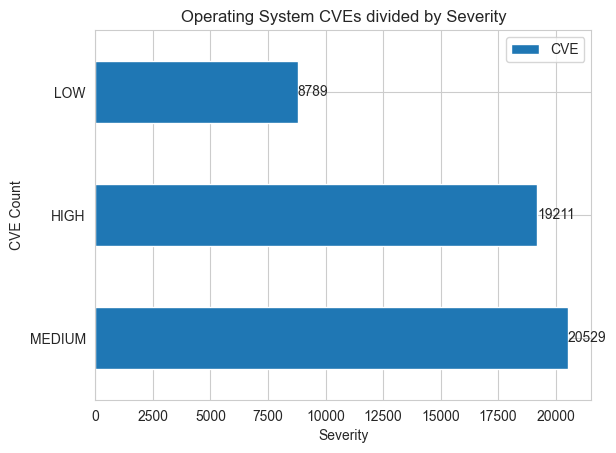

In [99]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
RETURN COUNT (DISTINCT n) as CVE, v.ucobaseSeverity as Severity
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='Severity', y='CVE', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Operating System CVEs divided by Severity')
plt.xlabel('Severity')
plt.ylabel('CVE Count')
plt.show()

Due to a difference in calculation. Some of the severity scores for the CVEs are left blank. This accounts for around 20,000 entries. These entries for all further analysis have been removed to only focused on the CVEs that do not have this problem.

The severity of a CVE is calculated through two numbers

Impact Score - a number between 0.0 and 10.0 that shows how bad the consequences are if the vulnerability is exploited
Exploit Score - a number between 0.0 and 10.0 that shows how easy it is for the vulnerability to be exploited.

These are the only two numerical data features in the dataset. Below sets up the query for analyzing the data. the df.info() is meant to check for any null values that are present. 
Now while the data is numerical it is stored as a string. Both columns are converted into numeric values to allow for plots to be created

In [100]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
RETURN DISTINCT v.label as CVE, v.ucobaseSeverity as Severity, v.ucoimpactScore as Impact_Score, v.ucoexploitabilityScore as Exploit_Score
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)

df['Exploit_Score'] = pd.to_numeric(df['Exploit_Score'], errors='coerce')
df['Impact_Score'] = pd.to_numeric(df['Impact_Score'], errors='coerce')
df.info()


C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50198 entries, 0 to 50197
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CVE            50198 non-null  object 
 1   Severity       50198 non-null  object 
 2   Impact_Score   50198 non-null  float64
 3   Exploit_Score  50198 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.5+ MB


We can first start by showing histplots for both the Impact Score and Exploit Score

There are some interesting things that are observed here. FIrstly its important to state that the data is not continuous, therefore this could likely affect future analysis.

For Impact score, the values usually fall into one of three bars. The values for Impact score do not vary by a lot making all of the data fall into just a few bars. Usually the values were around 2.5, 7.5, or 10.0.

Exploit Score contain a lot more variety. This hist plot is somewhat symmertical as the values have multiple rise points. However, the majority of data falls into having a score of 8.0 or higher. THis shows that Operating System CVEs usually have high Exploit scores.

array([[<Axes: title={'center': 'Impact_Score'}>,
        <Axes: title={'center': 'Exploit_Score'}>]], dtype=object)

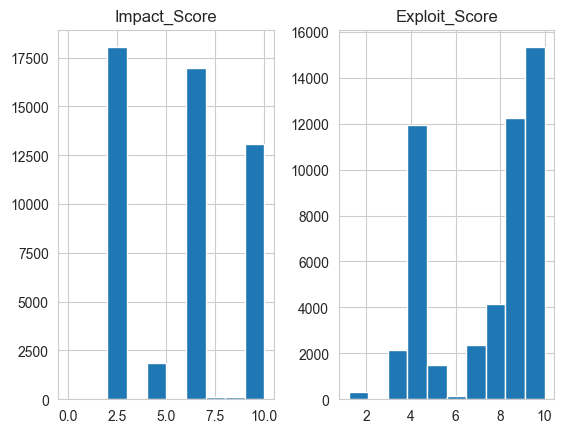

In [101]:
df.hist()

Along with hist plots showing the actual numerical distribution, it can also be shown through percentages. Kde plots show the percentage density along with also showing the peaks seen in the hist plots.

Impact scores highest density is located between a score of 2 and 4, making up more than 40% of the CVEs. There are also peaks between 6 and 8 and for 10 with each having a density of around 30%. THis continues to show the trend that Impact score usually falls between these three values

Exploit score is a bit more spread out, however their largest density was at 10, with around 40% of CVEs having a score of 10.

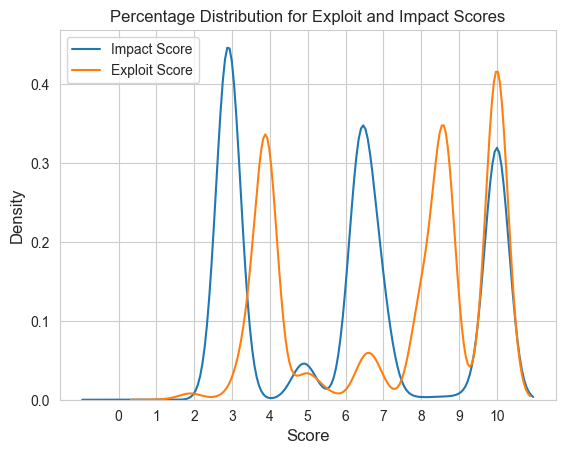

In [102]:
sb.kdeplot(df, x='Impact_Score', label='Impact Score')
sb.kdeplot(df, x='Exploit_Score', label='Exploit Score')
plt.title('Percentage Distribution for Exploit and Impact Scores')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.legend(loc='upper left')

Next we can further analyse the data through box plots., Box plots show the median, minimum and maximum values, and the quartiles of the. df.describe is also used to show the exact numbers

Impact Score's boxplot favores the right side. Impact has a minimum value of 0, a median of 6.4, a 25% quartile of 2.9, and its 75% quartile and maximum vaues are 10.0. The 75% and max quartiles being the same happens because the majority of values are the maximum value.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\2884540333.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


,Impact_Score,Exploit_Score
count,50198.000000,50198.000000
mean,6.075284,7.384300
std,2.787819,2.541628
min,0.000000,1.200000
25%,2.900000,3.900000
50%,6.400000,8.600000
75%,10.000000,10.000000
max,10.000000,10.000000


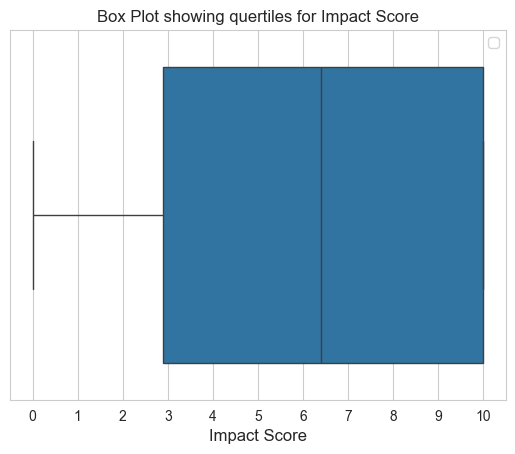

In [103]:
sb.boxplot(df, x='Impact_Score')
plt.title('Box Plot showing quertiles for Impact Score')
plt.xlabel('Impact Score', fontsize=12)
plt.legend()
plt.xticks(np.arange(0, 11, 1))
df.describe()

The exploit score box plot is rather similar but is slightly different.
Exploit has a minimum of 1.2, 25% quartile of 3.9, median of 8.6, and a 75% and max of 10.0. Both box plots have the same idea of the majority of entries are exactly the maximum that it influences the structure of the box plot.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\2850688305.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


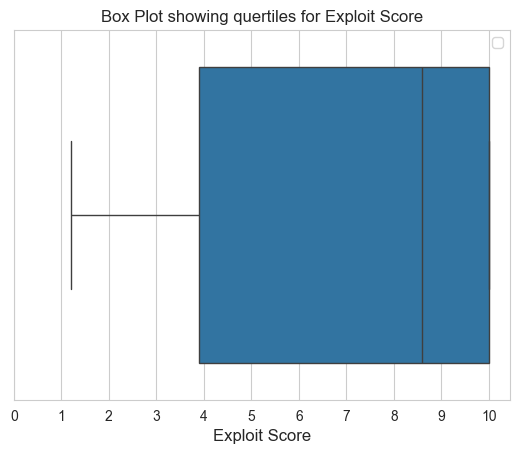

In [104]:
sb.boxplot(df, x='Exploit_Score')
plt.title('Box Plot showing quertiles for Exploit Score')
plt.xlabel('Exploit Score', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.legend()

Finally the densities can be seen through violin plots, which combine the features of both box and kde plots. There isnt much else to add through these plots, but it can help to see the density structure along with the box structure.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\516306208.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


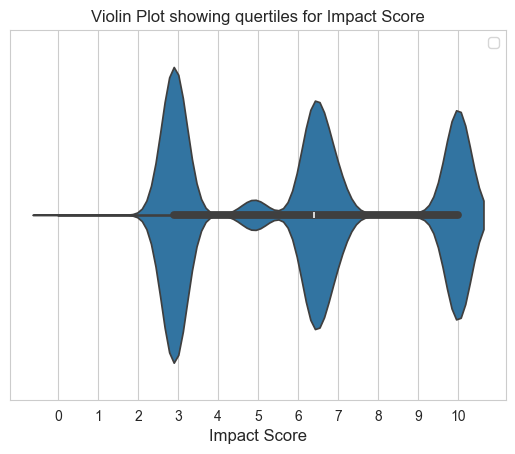

In [105]:
sb.violinplot(df, x='Impact_Score')
plt.title('Violin Plot showing quertiles for Impact Score')
plt.xlabel('Impact Score', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.legend()

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\1506560878.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


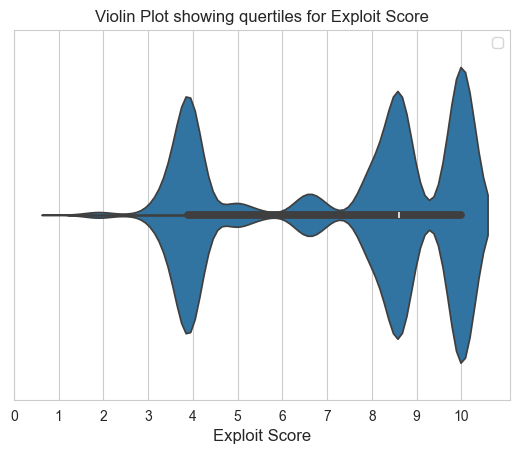

In [106]:
sb.violinplot(df, x='Exploit_Score')
plt.title('Violin Plot showing quertiles for Exploit Score')
plt.xlabel('Exploit Score', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.legend()

Since these numerical values relate to the severity of OS CVEs, we can now make comparisons with the severity scores. strip plots show the current frequency of rankings of the scores for each ranking. 

Now the plots do look unusual. This is once again due to the fact that the Exploit and Impact scores usually have set values and do not have much variety.

With Exploit score, there are a few things that can be noticed
- CVEs with a lov severity do now have a exploit score larger than 7, however there are two outliers that have an exploit score of 10
- High severity CVEs do not have exploit scores lower than 3.9
-medium severities are a lot more varied and spread out among the graph. Lower values of exploit score likely have a high impact score giving the CVE the medium ranking

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\3019999777.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


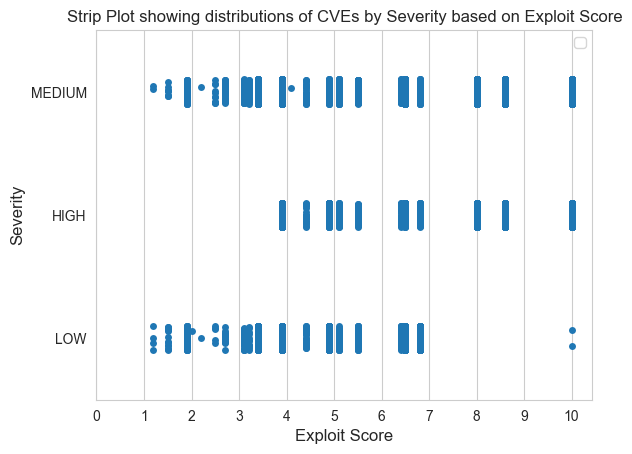

In [107]:
sb.stripplot(df, x='Exploit_Score', y='Severity')
plt.title('Strip Plot showing distributions of CVEs by Severity based on Exploit Score')
plt.xlabel('Exploit Score', fontsize=12)
plt.ylabel('Severity', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.legend()

Creating the same strip plot but for impact score shows a few important things
- Impact scores for LOW severities were usually between 2 and 8. However there were two outliers that were listed as 0. These two outliers ties into the two outliers from the Exploit score, showing that two entries have an exploit score of 10 and a impact score of 0
- CVEs with a HIGH severity always had an impact score greater than 6.
- CVES with a MEDIUM severity usually had a score higher than 6, but also contained scores around 3 and 5.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\2193072975.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


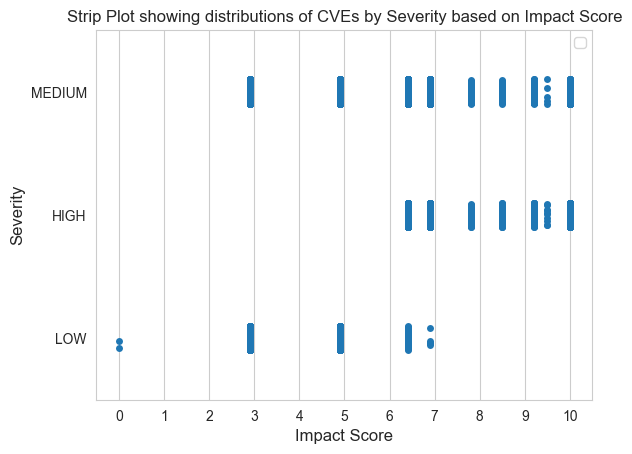

In [108]:
sb.stripplot(df, x='Impact_Score', y='Severity')
plt.title('Strip Plot showing distributions of CVEs by Severity based on Impact Score')
plt.xlabel('Impact Score', fontsize=12)
plt.ylabel('Severity', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.legend()

The last pieces of data that can be gathered from OS CVEs alone is whether these vulnerabilities allow for attackers to obtain full admin access and require user interaction. These questions are important as they can help show starting characteristics about these vulnerabilities.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   CVE_count Full_Access_Allowed User_Interaction_Needed
0        152                true                    true
1       1512                true                   false
2      11451               false                    true
3      61160               false                   false


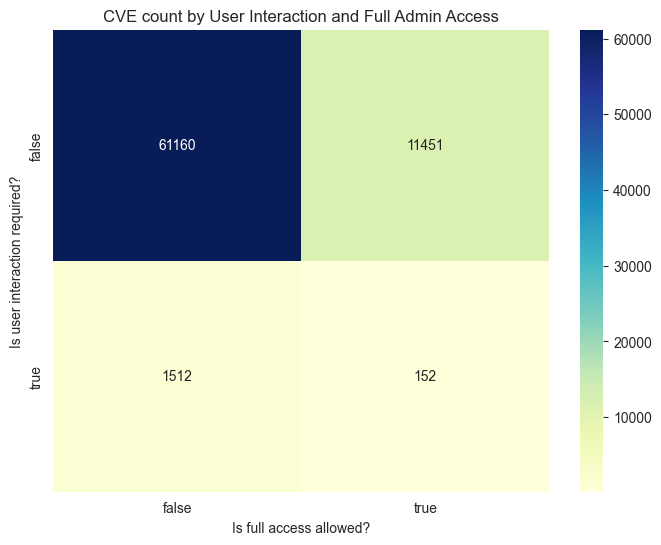

In [109]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT v) as CVE_count, v.ucoobtainAllPrivilege as Full_Access_Allowed, v.ucouserInteractionRequired as User_Interaction_Needed
ORDER BY CVE_count ASC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

heatmap_data = df.pivot(index='Full_Access_Allowed', columns='User_Interaction_Needed', values='CVE_count')

plt.figure(figsize=(8, 6))
sb.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('CVE count by User Interaction and Full Admin Access')
plt.xlabel('Is full access allowed?')
plt.ylabel('Is user interaction required?')
plt.show()

This head graph shows that the majority of OS related CVEs neither allowed for full access or needed user interaction. However there were a few that could allow for full access, but the amount of CVEs was far fewer than the others. 

So far, by analyzing CVEs and CPEs has shown a few notable characteristics. However another important question can be asked. Are OS related vulnerabilities more likely to be linked to weaknesses? This question can be answered by observing the CWE database and combining its data with OS related CVEs and CPEs

Below contains a query that divides the CVEs based on their relationship to weaknesses.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


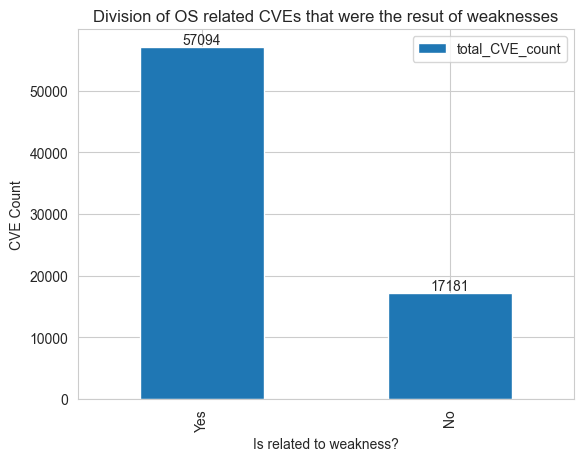

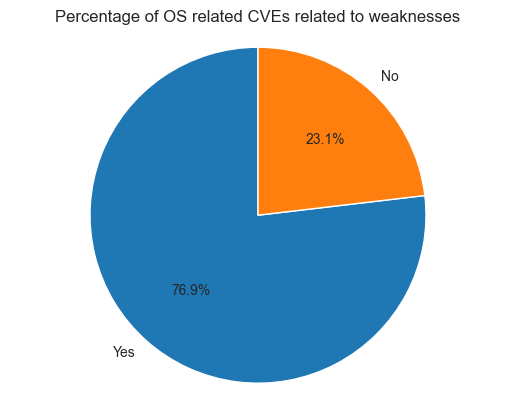

In [110]:
query = """
MATCH (u:UcoexCPE)<-[UCOEXHASCPE]-(n:UcoCVE)
WHERE split(u.cpeName, ':')[2] = 'o'
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
RETURN count(DISTINCT n) as total_CVE_count,
CASE
    WHEN w IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_weakness
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_weakness', y='total_CVE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of OS related CVEs that were the resut of weaknesses')
plt.xlabel('Is related to weakness?')
plt.ylabel('CVE Count')
plt.show()

# Get value counts for the 'Item' column
counts = df['total_CVE_count']

# Create pie chart
plt.pie(counts, labels=['Yes', 'No'], autopct='%1.1f%%', startangle=90)
plt.axis('equal') # Ensures the pie chart is circular
plt.title('Percentage of OS related CVEs related to weaknesses')
plt.show()

As seen above, 76.9% of the Operating system vulnerabilities were in fact related to a weakness. This means that the majority of Operating system vulnerabilities are somewhat caused by a weakness. 

Now that this question has been answer other questions can be asked about this data:

What are the characteristics of CWEs connected to operating system CVEs?

Answering this question will help show any possible trends with weaknesses to see how or why they are related to vulnerabilities.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


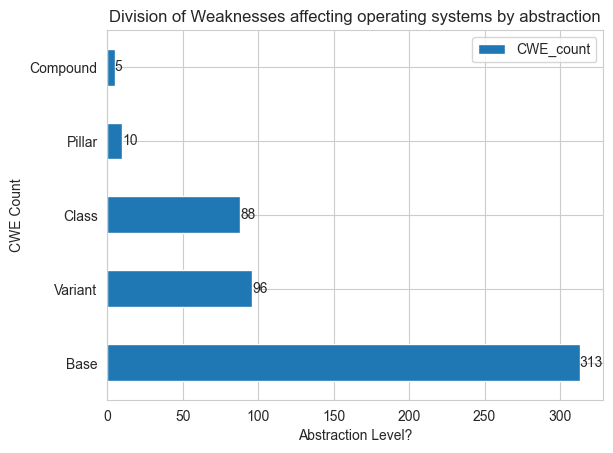

In [111]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT w) as CWE_count, w.ucoabstraction as abstraction
ORDER BY CWE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='abstraction', y='CWE_count', kind='barh')
ax.bar_label(ax.containers[0])
plt.title('Division of Weaknesses affecting operating systems by abstraction')
plt.xlabel('Abstraction Level?')
plt.ylabel('CWE Count')
plt.show()

As seen above, the majority of weakness that affect operating systems are ranked as a base abstraction level. This means the weakness is overall generic and not tied to any specific application. 96 of the entries however were Variant, which means they were tied to a specific application.

Finally, CAPEC nodes can be referenced to see if there are any revelant attack patterns for OS related vulnerabilities. We can see how many of the OS CVEs are related to specific attack patterns

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


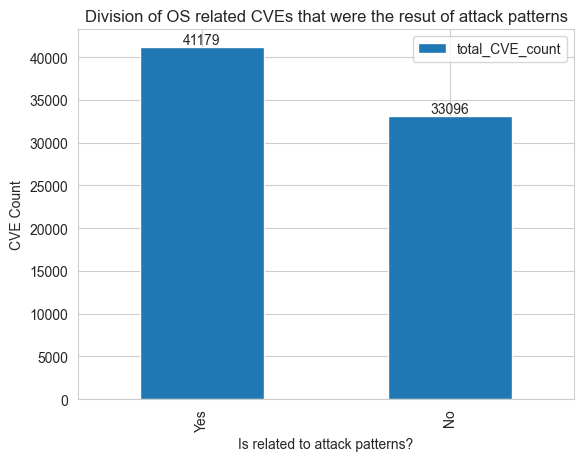

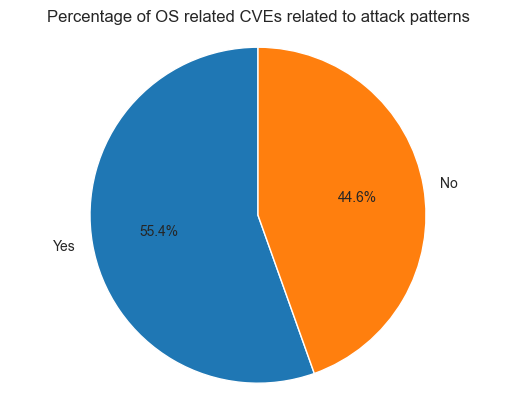

In [112]:
query = """
MATCH (u:UcoexCPE)<-[UCOEXHASCPE]-(n:UcoCVE)
WHERE split(u.cpeName, ':')[2] = 'o'
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
RETURN count(DISTINCT n) as total_CVE_count,
CASE
    WHEN c IS NULL THEN 'No'
    ELSE 'Yes'
END AS related_to_attack_pattern
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
df

ax = df.plot(x='related_to_attack_pattern', y='total_CVE_count', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Division of OS related CVEs that were the resut of attack patterns')
plt.xlabel('Is related to attack patterns?')
plt.ylabel('CVE Count')
plt.show()

# Get value counts for the 'Item' column
counts = df['total_CVE_count']

# Create pie chart
plt.pie(counts, labels=['Yes', 'No'], autopct='%1.1f%%', startangle=90)
plt.axis('equal') # Ensures the pie chart is circular
plt.title('Percentage of OS related CVEs related to attack patterns')
plt.show()

As Ineresting question can also be asked here: Are Operating system related vulnerabilities usually related to both weaknesses and attack patterns, or is this separate? A heatmap can be derived to display the count of CVEs that are related to weaknesses and attack patterns and see if any of the two values is Null.

Now interestingly, one of the squares is missing. THis is because due to the structure of the knowledge graph, it is impossible for a CVE to be related to an attack pattern and NOT be related to a weakness. attack patterns and weaknesses are directly related to each other so this commbination of relations is impossible. A CVE can however be relate to a weakness and still not have any relationship with an attack pattern.

As seen below, the majority of Operating system vulnerabilities are related to both weaknesses and attack patterns. There does exist a small percentage that while related to a weakness are not related to an attack pattern, but the majority have both.

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CVE_count Is_Related_to_Weakness Is_Related_to_Attack_Pattern
0            41179                   true                         true
1            18660                   true                        false
2            17181                  false                        false


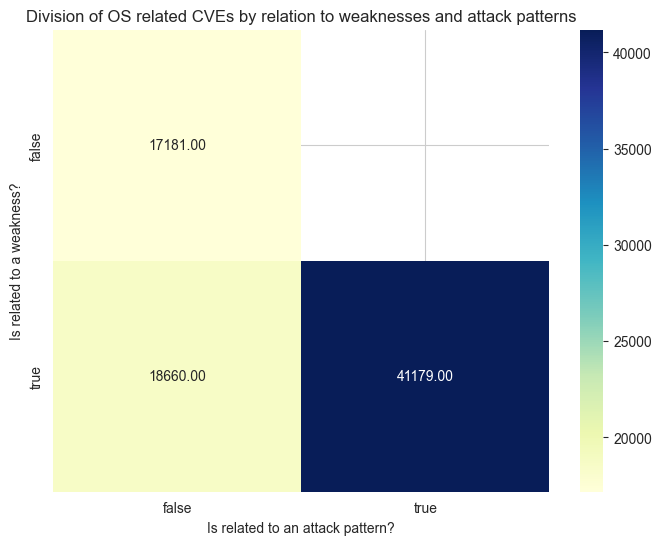

In [113]:
query = """
MATCH (u:UcoexCPE)<-[UCOEXHASCPE]-(n:UcoCVE)
WHERE split(u.cpeName, ':')[2] = 'o'
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)
OPTIONAL MATCH (n)<-[UCOHASCVE_ID]-(v:UcoVulnerability)<-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
RETURN count(DISTINCT n) as total_CVE_count,
CASE
    WHEN w IS NULL then 'false'
    ELSE 'true'
END AS Is_Related_to_Weakness,
CASE
    WHEN c IS NULL THEN 'false'
    ELSE 'true'
END AS Is_Related_to_Attack_Pattern
ORDER BY total_CVE_count DESC
"""

params = {}
count = run_query(query, parameters=params)

#creates a datafram to output the results
df = pd.DataFrame(count)
print(df)

heatmap_data = df.pivot(index='Is_Related_to_Weakness', columns='Is_Related_to_Attack_Pattern', values='total_CVE_count')

plt.figure(figsize=(8, 6))
sb.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Division of OS related CVEs by relation to weaknesses and attack patterns')
plt.xlabel('Is related to an attack pattern?')
plt.ylabel('Is related to a weakness?')
plt.show()

The results of this query is rather mixed, with the graphs leaning more towards yes than no. However, the results lean more towards an answer of yes than no.

Its important to gather information about OS related attack patterns, including likeihood, severity, and skill level

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CAPEC Skill_Level
0          199        None
1           91        Low 
2           83     Medium 
3           59       High 


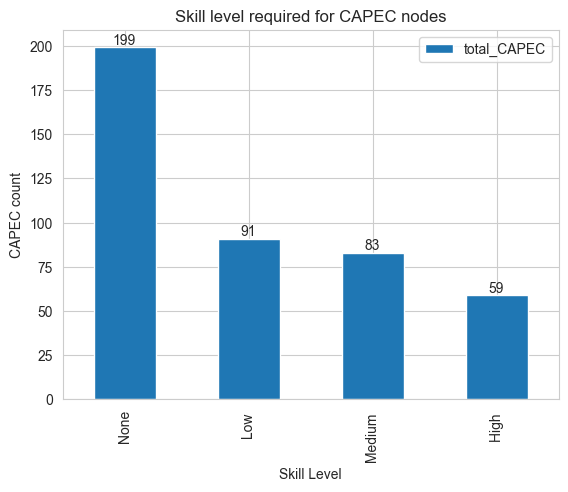

In [114]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
WHERE split(n.cpeName, ':')[2] = 'o'
RETURN count(DISTINCT c) as total_CAPEC, split(c.ucoexSkills_Required[0], [':', '-'])[1] as Skill_Level
ORDER BY total_CAPEC DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Skill_Level', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Skill level required for CAPEC nodes')
plt.xlabel('Skill Level')
plt.ylabel('CAPEC count')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CAPEC Likelihood
0          122       High
1           93     Medium
2           55        Low


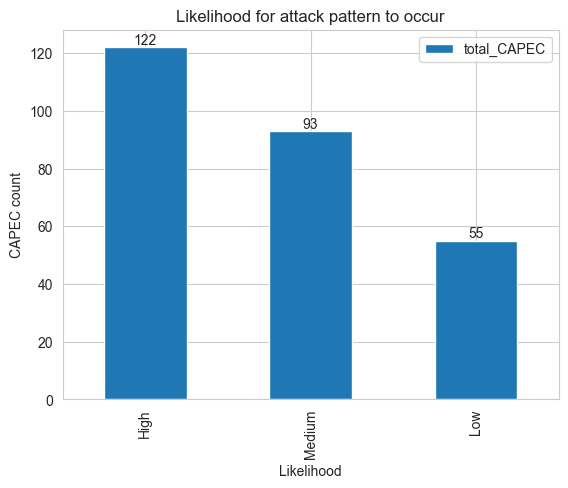

In [115]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
WHERE split(n.cpeName, ':')[2] = 'o' AND c.ucoexLikelihood <> ''
RETURN count(DISTINCT c) as total_CAPEC, c.ucoexLikelihood as Likelihood
ORDER BY total_CAPEC DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Likelihood', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Likelihood for attack pattern to occur')
plt.xlabel('Likelihood')
plt.ylabel('CAPEC count')
plt.show()

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


   total_CAPEC   Severity
0          157       High
1           88     Medium
2           79        Low
3           57  Very High
4            4   Very Low


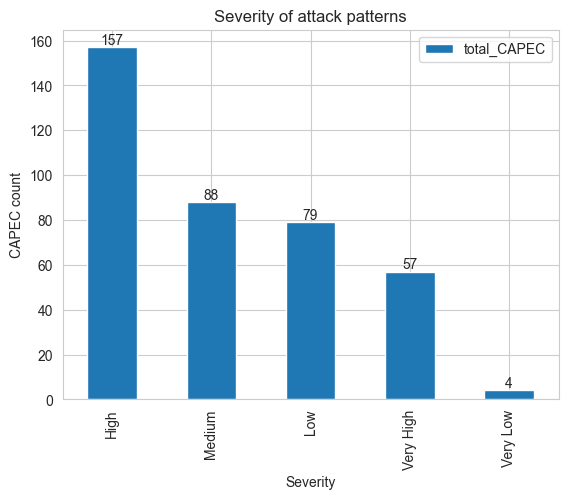

In [116]:
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
WHERE split(n.cpeName, ':')[2] = 'o' AND c.ucoexSeverity <> ''
RETURN count(DISTINCT c) as total_CAPEC, c.ucoexSeverity as Severity
ORDER BY total_CAPEC DESC
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
print(df)

ax = df.plot(x='Severity', y='total_CAPEC', kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Severity of attack patterns')
plt.xlabel('Severity')
plt.ylabel('CAPEC count')
plt.show()

From these graphs we can see several observations. Firstly, most CAPECs related to operating systems required no skill level to execute, meaning that these attack patterns are relatively easy to execute, making them more dangerous.

Next, operating system CVEs related to CAPECs often had a high likelihood to occur. Unfortunately a portion of the CAPECs int his graph had to be cut due to having an empty string for their likelihood property. However, most of the CAPECs remaining still ranked high, meaning these CAPECs related to OS CVEs often are highly likely to occur.

Finally, the operating system CVEs related to CAPECs often consisted of a capec severity of high, meaning that they often caused serious damage. This overall shows that operatin system CVEs that are related to attack patterns are:
- easy for an attacker to execute
- highly likely to occur
- considered dangerous and can cause lasting damage

## Exploration Summary

From the graphs above the following conclusions can be made:
- Operating System CVEs have seen a rapid increase in modern years since 2017
- Most OS CVEs ranked Medium or higher in severity, meaning they were often serious in damage and danger
- The Impact and Exploit score contribute greatly to the severity score, and specific scores were more related to svecific severities.
- Most OS vulnerabilities did not allow for full administrator access or required user interaction, so while they couldn't obtain full control they did not need to trick the user to carry out the exploit
- Most OS Vulnerabilities were related to both weaknesses and attack patterns, meaning there were other factors in play to the vulnerability
- Most weaknesses attributed to OS vulnerabilities were not specific to one application but contained documentation
- Most attack patterns related to OS vulnerabilities were easy to execute, highly liekly to occur, and were often considered severe

Seeing these features that have been derived, conclusions can be made that 
- Operating system vulnerabilities have been increasing
- They contain characteristics that make them highly dangerous
- There are trends seen that OS vulnerabilities are highly related to weaknesses and attack patterns

This simply analysis helps to answer several important questions about operating system vulnerabilities, later on prediction models will be develope to see if some these features can be predicted based on the common trends present. 

# Regression

Regression models involve working with numerical data to make predictions and find relationships between the data.

The following section will construct three different models
- Linear Regression Model
- Multi Linear Regression Model
- Logistic Regression Model

Since the dataset that is being worked with consists of mainly classification characteristics, options for what will be predicted will be rather limited.

However CVEs do contain two properties that are considered numerical
- Impact Score
- Exploitability Score

The impace and exploitability score is used in the calculation to decide the severity of the model. While the base score of the severity is not mentioned in the dataset, it can however be predicted from the ranking its given.

## Linear Regression

Regression models utilize numerical data to make predictions on a numerical value. Unfortunately, numerical data is rather limited in the datasets that are being worked with. However there does consist two columns that do contain important numerical data
- Impact Score
- Exploitability Score

These two values as showed when exploring the data contribute the the overall severity of a CVE. Using a linear regression model we can use these datapoints to help predict what the severity is supposed to be.

Trying to use one of the scores to predict the other simply does not work and results in a model with very poor performance. However, using a cypher query we can have a model return a numerical value for severity. For this case a 0 means Low, 1 means Medium, and 2 means High. Since several severity values were discovered to have no ranking, these CVEs were removed from the dataset.

In [280]:
#Import libraries needed for regression and model training
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#cypher query that grabs the needed data.
#for severity, HIGH is given a numerical value of 2
#MEDIUM has a value of 1
# and LOW has a value of 0
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
RETURN DISTINCT v.label as CVE, 
CASE
    WHEN v.ucobaseSeverity = 'HIGH' then 2
    WHEN v.ucobaseSeverity = 'MEDIUM' THEN 1
    ELSE  0
END AS Severity, 
v.ucoimpactScore as Impact_Score, 
v.ucoexploitabilityScore as Exploit_Score
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CVE,Severity,Impact_Score,Exploit_Score
0,CVE-2021-45484,1,2.9,10.0
1,CVE-2021-45489,1,2.9,10.0
2,CVE-2021-45487,1,2.9,10.0
3,CVE-2021-45488,1,2.9,10.0
4,CVE-2017-1000374,2,6.4,10.0
...,...,...,...,...
50193,CVE-2025-9781,2,10.0,8.0
50194,CVE-2025-9782,2,10.0,8.0
50195,CVE-2025-9783,2,10.0,8.0
50196,CVE-2025-9779,2,10.0,8.0


With the dataframe, there are over 50 thousand data entries that can be used for the model. The goal is to make a linear regression model that

- is able to predict an accurate value between 0 and 2 that assigns a point to a specific severity.
- has little to no error in its predictions

The data frame, despite having numerical values for exploit and impact score, stores them as strings. They will need to be converted to numeric values for the model to work. Any values that might also be empty are also dropped.

In [281]:
#While Exploit and Impact scores are technically numbers, they are stored as strings, 
# the columns are converted to numeric values and all empty values are dropped
df['Exploit_Score'] = pd.to_numeric(df['Exploit_Score'], errors='coerce')
df['Impact_Score'] = pd.to_numeric(df['Impact_Score'], errors='coerce')
df = df.dropna(subset=['Impact_Score', 'Exploit_Score', 'Severity']).copy()

#set up the features and target values
X = df[['Impact_Score', 'Exploit_Score']] #features
y = df['Severity'] #target

#separating the data into training and test sets
#training contains 70% and test has 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Creates the regression model and fits it with the training values
#y_pred holds the predictions that the model created
#the print statement shows some of the value the model predicted
Lin_Model = LinearRegression()
Lin_Model.fit(X_train, y_train)
y_pred = Lin_Model.predict(X_test)
print(pd.DataFrame({"Actual": y_test, "Predicted": y_pred}))

#save the test and prediction y values in separate variables
#these will be used later on for model evaulation
test1 = y_test
pred1 = y_pred

#displays the mean squared error and the r2 score
#the lower the mean squared error, the better
#the higher the r2 the better
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

#lists the features by their importance
#features that are more important are listed first
feature_importance = pd.DataFrame({
 'Feature': X.columns,
 'Coefficient': Lin_Model.coef_
})
print(feature_importance.sort_values(by='Coefficient', ascending=False))


       Actual  Predicted
5369        0   0.198119
14957       2   2.145583
41446       1   0.872876
26599       2   2.071710
36362       2   1.566912
...       ...        ...
37050       2   2.317953
39747       0   0.518235
8377        1   0.949160
13705       2   1.623917
28306       2   1.547941

[15060 rows x 2 columns]
Mean Squared Error: 0.08788884071367283
R^2 Score: 0.7976422445025796
         Feature  Coefficient
0   Impact_Score     0.192788
1  Exploit_Score     0.123121


The linear regression model performed very well. The mean squared error was very low, meaning that little to no error was made in predictions. The R2 score was also a high 79%, meaning the model was rather accurate in the majority of its predictions.

When measuring the features by their importance, It appears that between the two features, Impact score overall had more of an influence on the models predictions. This is likely due to its limited values seen earlier in previous analysis. 

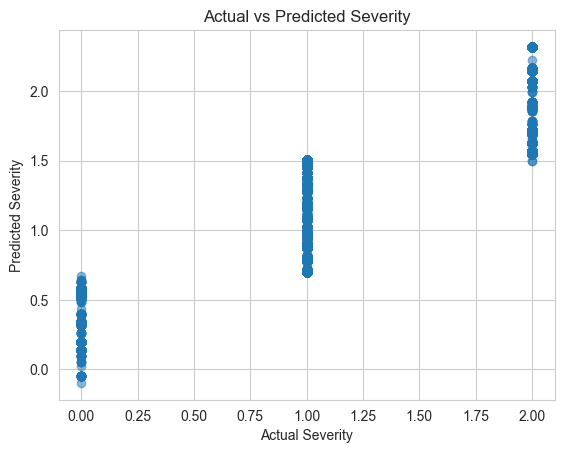

In [282]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Severity")
plt.show()

Plotting the Linear model shows how the points were predicted. The points were on three specific places along the x axis, or the actual severity. Reminder that
- 0 = LOW
- 1 = MEDIUM
- 2 = HIGH

The predicted values followed a range. Values predicted to be LOW were around 0 - 0.5. The reason some of the points above 0.5 were likely not considered to be medium was due to rounding. MEDIUM values were predicted to be between 0.5 - 1.5. HIGH values were between 1.5 - 2.5

They show how the model made its predictions, but doesnt really show how Impact and Exploit Score contributed to the values.

This can be further shown with a multi Lonear Regression model. Plotting the data in a 3d scale will allow the Exploit and Impact scores to be shown.

The same model that was previously made can be used here to graph this plot.

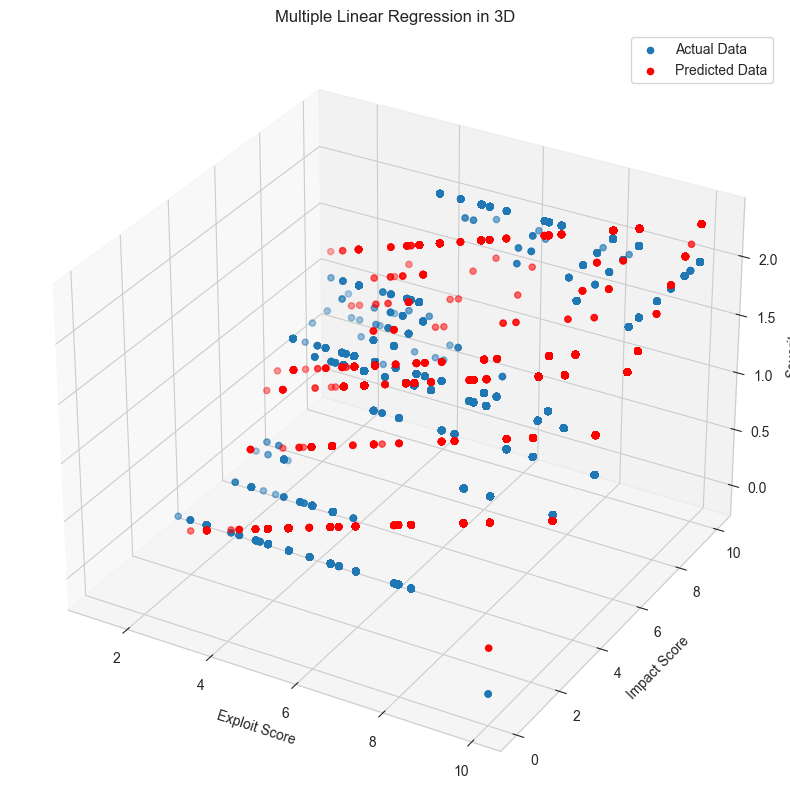

In [283]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Exploit_Score'], df['Impact_Score'], df['Severity'], label='Actual Data')
ax.scatter(X_test['Exploit_Score'], X_test['Impact_Score'], y_pred, color='red', label='Predicted Data')

ax.set_xlabel('Exploit Score')
ax.set_ylabel('Impact Score')
ax.set_zlabel('Severity')
ax.set_title('Multiple Linear Regression in 3D')
plt.legend()
plt.show()

As seen from the model above, The predictions compared to the actual values can be seen more clearly. The red show the predicted values while the blue show the actual values contained in the set. This model also shows the Exploit and Impact scores for both of the sets very clearly, showing the features the the model used for prediction.

The predicted values form a plane that cuts through the actual values. While the actual values are clearly cut due to their division by severity, the prediction dataset does not have this and shows the actual scale of prediction. As seen by the highest point of the plane, Impact Score created a larger values compared to Exploit Score.

## Linear Regression extended

The previous linear Regression model focused on properties that were directly linked to the score, however a question can raised: Is it possible that other unrelated features can help predict the severity score. These features include the following:
- can the CVE allow for full access
- does the CVE need user interaction
- is the CVE related to a weakness
- how many weaknesses is a CVE related to
- is the CVE related to an attack pattern.
- how many attack patterns is the CVE related to

These features can be added to the linear regression model to make the model more complex.

In [284]:
query = """
MATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
OPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)
                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)
                 -[r:UCOHASWEAKNESS]->(w:UcoCWE)
                 <-[s:UCOEXHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
                 -[t:UCOEXHASTAXONOMYMAPPING]->(b:UcoexMITREATTACK)
RETURN DISTINCT
    v.label AS CVE, 
    CASE
        WHEN v.ucobaseSeverity = 'HIGH' THEN 2
        WHEN v.ucobaseSeverity = 'MEDIUM' THEN 1
        ELSE 0
    END AS Severity,
    v.ucoexploitabilityScore as Exploit_Score,
    v.ucoimpactScore as Impact_Score,
    CASE 
        WHEN v.ucoobtainAllPrivilege = 'true' THEN 1 
        ELSE 0 
    END AS Full_Access,
    CASE 
        WHEN v.userInteractionRequired = 'true' THEN 1 
        ELSE 0 
    END AS User_Interaction,
    CASE 
        WHEN w IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_Weakness,
    CASE 
        WHEN c IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_CAPEC,
    CASE
        WHEN b IS NOT NULL THEN 1
        ELSE 0
    END AS Related_to_attack,
    COUNT(DISTINCT r) as CWE_count,
    COUNT (DISTINCT s) as CAPEC_count,
    COUNT (DISTINCT t) as Attack_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: userInteractionRequired)} {position: line: 23, column: 16, offset: 800} for query: "\nMATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)\nWHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''\nOPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)\n                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)\n           

,CVE,Severity,Exploit_Score,Impact_Score,Full_Access,User_Interaction,Related_to_Weakness,Related_to_CAPEC,Related_to_attack,CWE_count,CAPEC_count,Attack_count
0,CVE-2021-45484,1,10.0,2.9,0,0,0,0,0,0,0,0
1,CVE-2021-45489,1,10.0,2.9,0,0,0,0,0,0,0,0
2,CVE-2021-45487,1,10.0,2.9,0,0,1,1,1,1,2,2
3,CVE-2021-45488,1,10.0,2.9,0,0,1,1,1,1,2,2
4,CVE-2017-1000374,2,10.0,6.4,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50193,CVE-2025-9781,2,8.0,10.0,0,0,0,0,0,0,0,0
50194,CVE-2025-9782,2,8.0,10.0,0,0,0,0,0,0,0,0
50195,CVE-2025-9783,2,8.0,10.0,0,0,0,0,0,0,0,0
50196,CVE-2025-9779,2,8.0,10.0,0,0,0,0,0,0,0,0


This dataframe now adds several more features that can be used in a linear regression algorithm. THe features are as follow:
- Full_access = can the CVE allow for full administrator access
- User_interaction = does the CVE need user interaction to carry out the attack
- Related_to_weakness = is the CVE related to at least one weakness
- CWE_count = how many weaknesses is the CVE related to
- Related to CAPEC = is the CVE related to an attack pattern
- CAPEC_count = how many CAPECs is the CVE related to
- Related_to_attack = is the CVE related to any known attacks
- Attack_count = how many attacks is the CVE related to

These features can be converted to numerical values to try and predict the severity

In [287]:
from sklearn import metrics
#While Exploit and Impact scores are technically numbers, they are stored as strings, 
# the columns are converted to numeric values and all empty values are dropped
df['Impact_Score'] = pd.to_numeric(df['Impact_Score'], errors='coerce')
df['Exploit_Score'] = pd.to_numeric(df['Exploit_Score'], errors='coerce')
df['Full_Access'] = pd.to_numeric(df['Full_Access'], errors='coerce')
df['User_Interaction'] = pd.to_numeric(df['User_Interaction'], errors='coerce')
df['Related_to_Weakness'] = pd.to_numeric(df['Related_to_Weakness'], errors='coerce')
df['Related_to_CAPEC'] = pd.to_numeric(df['Related_to_CAPEC'], errors='coerce')
df['Related_to_attack'] = pd.to_numeric(df['Related_to_CAPEC'], errors='coerce')
df['CWE_count'] = pd.to_numeric(df['CWE_count'], errors='coerce')
df['CAPEC_count'] = pd.to_numeric(df['CAPEC_count'], errors='coerce')
df['Attack_count'] = pd.to_numeric(df['Related_to_CAPEC'], errors='coerce')
df = df.dropna(subset=['Impact_Score', 'Exploit_Score', 'Full_Access', 'User_Interaction','Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count','Related_to_attack', 'Attack_count', 'Severity']).copy()

#set up the features and target values
X = df[['Impact_Score', 'Exploit_Score', 'Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count', 'Related_to_attack', 'Attack_count']] #features
y = df['Severity'] #target

#separating the data into training and test sets
#training contains 70% and test has 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Creates the regression model and fits it with the training values
#y_pred holds the predictions that the model created
#the print statement shows some of the value the model predicted
Lin_Model2 = LinearRegression()
Lin_Model2.fit(X_train, y_train)
y_pred = Lin_Model2.predict(X_test)
print(pd.DataFrame({"Actual": y_test, "Predicted": y_pred}))

#displays the mean squared error and the r2 score
#the lower the mean squared error, the better
#the higher the r2 the better
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

#lists the features by their importance
#features that are more important are listed first
feature_importance = pd.DataFrame({
 'Feature': X.columns,
 'Coefficient': Lin_Model2.coef_
})

feature_importance['Coefficient'] = feature_importance['Coefficient'].round(5)
print(feature_importance.sort_values(by='Coefficient', ascending=False))
#print(feature_importance.sort_values(by='Coefficient', ascending=False))

       Actual  Predicted
5369        0   0.208845
14957       2   2.131995
41446       1   0.882154
26599       2   2.073712
36362       2   1.550596
...       ...        ...
38925       1   1.368251
48098       0   0.190703
25011       1   1.442472
29392       1   1.442472
42232       0   0.573771

[10040 rows x 2 columns]
Mean Squared Error: 0.08667860763645163
R^2 Score: 0.7991200544240656
               Feature  Coefficient
0         Impact_Score      0.19153
2          Full_Access      0.12421
1        Exploit_Score      0.12370
6            CWE_count      0.00789
5     Related_to_CAPEC      0.00403
4  Related_to_Weakness      0.00403
9         Attack_count      0.00403
8    Related_to_attack      0.00403
3     User_Interaction      0.00000
7          CAPEC_count     -0.00073


As seen above, the model score is still relatively the same. the mean squared error is still relatively low and the R2 score is still the same at 79%

The new features that were added also did not achieve more importance than the Impact Score and Exploit Score. The new feature that was closest to having an impact on the prediction was Full_Access, having a score thats slightly higher than Exploit_Score. The other remaining features contained far lower importance to the overall model. The closest any of the indirect features had to making a difference in the score was CWE_count, showing how many weaknesses were related to the CVE.

This means that indirect features of a CVE from other datasets really do not have a impact on the overall score.

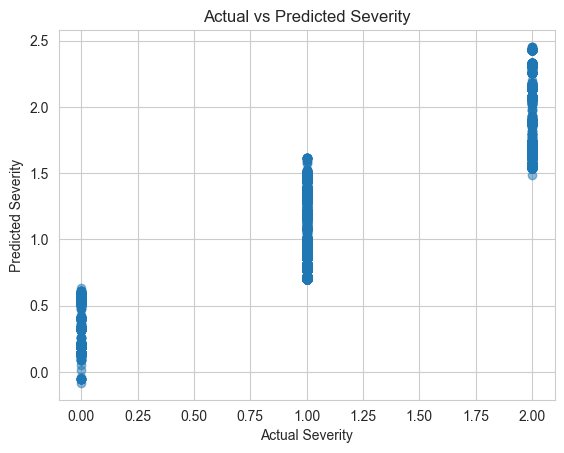

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Severity")
plt.show()

The scatter plot still looks relatively the same , though the differences in points on the graph is due to the data chosen for the test set.

## Logistic Regression

This section will construct the logistic regression model. Earlier exploration showed that the majority of operating system CVEs had a severity ranking of medium or higher, which begs the question

Can Impact and Exploitability score be used to predict of an OS CVE will have a severity of Medium or higher.

Since logistic regression models predict by finding a binary class, All CVEs with a severity of medium or higher will be given a binary value of 1. All low values are given a 0. To also avoid obstruction due to unranked data, all OS CVEs with an empty severity value will be ignored.

In [ ]:
query = """
MATCH (u:UcoexCPE)<-[UCOEXHASCPE]-(n:UcoCVE)
WHERE split(u.cpeName, ':')[2] = 'o' AND n.ucobaseSeverity <> ''
RETURN DISTINCT n.label,
CASE
    WHEN n.ucobaseSeverity = 'MEDIUM' OR n.ucobaseSeverity = 'HIGH' THEN 1
    ELSE 0
END AS Severity,
n.ucoexploitabilityScore as Exploit_Score, 
n.ucoimpactScore as Impact_Score
"""
params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

#df['Exploit_Score'] = pd.to_numeric(df['Exploit_Score'], errors='coerce')
#df['Impact_Score'] = pd.to_numeric(df['Impact_Score'], errors='coerce')
#plt.figure(figsize=(8,6))
#sb.stripplot(df, x='Severity', y='Impact_Score')
#plt.ylabel('Impact_Score')
#df.describe()

#pd.plotting.scatter_matrix(df)

C:\Users\peyto\AppData\Local\Temp\ipykernel_39696\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,n.label,Severity,Exploit_Score,Impact_Score
0,CVE-2021-45484,1,10.0,2.9
1,CVE-2021-45489,1,10.0,2.9
2,CVE-2021-45487,1,10.0,2.9
3,CVE-2021-45488,1,10.0,2.9
4,CVE-2017-1000374,1,10.0,6.4
...,...,...,...,...
50193,CVE-2025-9781,1,8.0,10.0
50194,CVE-2025-9782,1,8.0,10.0
50195,CVE-2025-9783,1,8.0,10.0
50196,CVE-2025-9779,1,8.0,10.0


With this dataset we can define both the features and the targets.

X = Impact_Score & Exploit_Score
y = Severity

The goal is for the logistic model to successfully predict based on the two features if the severity is medium or higher
We can then define the datasets and split the data

Accuracy: 1.0


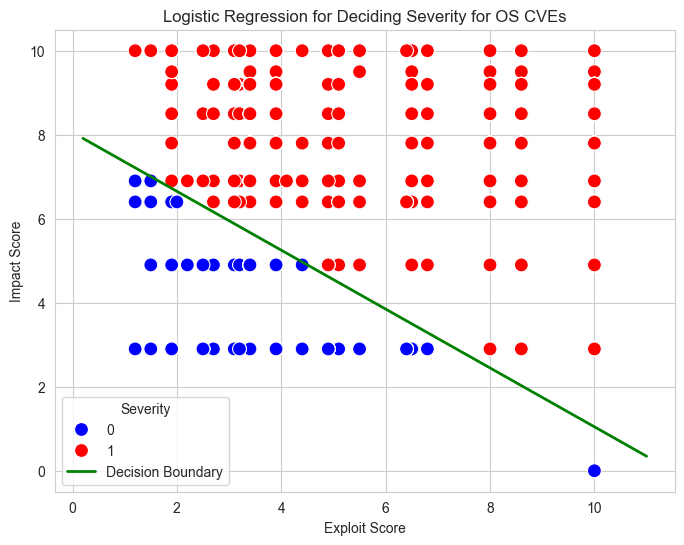

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

df['Exploit_Score'] = pd.to_numeric(df['Exploit_Score'], errors='coerce')
df['Impact_Score'] = pd.to_numeric(df['Impact_Score'], errors='coerce')

#set the features and the target
X = df[['Exploit_Score', 'Impact_Score']]
y = df['Severity']

#split the data in X and y to prepare for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Log_model = LogisticRegression()
Log_model.fit(X_train, y_train)
y_pred = Log_model.predict(X_test)
y_proba = Log_model.predict_proba(X_test)
#these values are stored for the evualating model performance section
test2 = y_test
pred2 = y_pred
prob = y_proba

print("Accuracy:", Log_model.score(X_test, y_test))

# Scatter plot
plt.figure(figsize=(8,6))
sb.scatterplot(
    data=df,
    x='Exploit_Score',
    y='Impact_Score',
    hue='Severity',
    palette={0:'blue', 1:'red'},
    s=100
)

# Decision boundary line
# Logistic regression coefficients
coef = Log_model.coef_[0]
intercept = Log_model.intercept_[0]

# y = -(intercept + coef[0]*x)/coef[1]
x_vals = np.linspace(X['Exploit_Score'].min()-1, X['Exploit_Score'].max()+1, 200)
y_vals = -(intercept + coef[0] * x_vals) / coef[1]

plt.plot(x_vals, y_vals, color='green', linewidth=2, label='Decision Boundary')

plt.title('Logistic Regression for Deciding Severity for OS CVEs')
plt.xlabel('Exploit Score')
plt.ylabel('Impact Score')
plt.legend(title='Severity')
plt.grid(True)
plt.show()




As seen here, the model works extremely well, making no errors in its predictions. The way that the model made its decisions was decided by the green boundary line, dividing the points into two separate targets, Low severity, or a severity of Medium or higher.

The graph also shows the relationship between Impact and Exploit score is negative. As Exploit score increases, Impact score decreases based on the boundary line. This shows two things about the scores
- The higher exploit score is, the lower impact score can be for a point to be classified as medium or higher
- the lower exploit score is, only points with high impact scores are listed as medium or higher

There were a few points that were rather close to the boundary line, but they were not misclassified.

## Next steps

Truthfully, Regression algorithms do not work well with the datasets due to the overall lack of numerical data. However, some conclusion can be drawn from the overall linear and logistic models

First the linear models did work well for using features directly related to CVE severity to predict the ranking. However when using that same model for indirect features, they not change the model's accuracy. This means that regression wise, using features from other datasets does not really work.

Logistic regression was able to show the relationship between Impact and Exploit scores
- The higher the Exploit score, the lower Impact score can be for a higher severity
- the lower the exploit score, the higher impact needs to be to be a high severity

Overall, some important conclusion can be made from Regression, however this dataset will likely fare better with classification models instead.

# Comparing Models

This section will involve comparing the models developed in the regression section of the project. THis will include comparing the loss functions of the models, cross validation techniques, and other methods to compare the models.

In the previous section. Three linear regression models were created, these models were as follows
- Lin_Model - a linear regression model that compared the impact and exploit score of the severity of operating system CVEs
- Lin_Model2 - a linear regression model that, along with impact and exploit score, also included other indirect features in the features to see if other features played a role in the CVEs severity
- Log_Model - a logistic regression that using impact score and exploit score predicted when a CVE would be classified as a severity of medium or higher, creating a definite line of division for the classes.

These three models will be analyzed to see their performance while also concluding other important conclusions about predicting severity

## Loss functions 

Both linear and logistic functions have loss functions that can be used to evualate model performance.

Firstly we can analyze the performance of our linear models. To do this, the following loss functions are used
- mean squared error: The higher the value, the worse the model performed
- root mean squared error; The square root of the mean squared error, the higher it is the worse the model performed
- mean absolute error: absolute value of the difference between real and predicted values

We can first start with out first linear regression model: Lin_Model. This model only took the direct features of severity score: impact and exploit score to predict the severity of a CVE. When using that model, the y_test and y_pred variables, which stored the target test set and the predictions made to further compare them in the loss functions. The cell below runs all three loss functions to see the result

In [ ]:
from sklearn import metrics
#finds the mse, rmse, and mae
#this cell uses variables that were defined to hold the prediction sets of the Linear
#Regression model
#test1 = y_test
#pred1 = y_pred

mse = mean_squared_error(test1, pred1)
rmse = mse ** 0.5
ase = metrics.mean_absolute_error(test1, pred1)

print('Mean Squared Error for Lin_Model: ', mse)
print('Root Mean Squared Error for Lin_Model: ', rmse)
print('Mean Absolute Error for Lin_Model:', ase)

Mean Squared Error for Lin_Model:  0.08788884071367283
Root Mean Squared Error for Lin_Model:  0.29646052134082346
Mean Absolute Error for Lin_Model: 0.2552822163850452


From first glance at the loss functions, the low values of all of the functions show that the model performed well.

Mean squared was only a 0.088, which means the average difference between real and predicted values was really low. This performance for the mse is good as it means the model had little to no error

Root mean squared error was a 0.296. The only reason its higher is due to being the squared root of the previous value. However its value is also low.

Mean absolute error is the avarage of the absolute differences of the predicted and real values. As seen above the value is also low, meaning that there was little difference overall.

These values can also be used to compare the logistic regression model.

In [ ]:
#finds the mse, rmse, and mae
#this cell uses variables that were defined to hold the prediction sets of the Linear
#Regression model
#test2 = y_test
#test1 = y_pred

loss = metrics.log_loss(test2, prob)
ase = metrics.mean_absolute_error(test2, pred2)
print('Log loss for Log_model: ', loss)
print('Absolute loss for Log_model: ', ase)

Log loss for Log_model:  0.0011224756425550657
Absolute loss for Log_model:  0.0


As seen above the logistic model 's performance was better than the linear regression model's performance. The log loss was very low at less than 1%. This means that the model had very little error in its decision boundary. The absolute loss was also a perfect 0, meaning that in testing, the model did not make any error in its decision boundary. This means that the logistic model is a perfect fit for showing division of the severities.

While this logistic model divided the CVEs by their severity, between severity of low or a medium or higher, it could also be applied differently since the data is completely linerally separatable.

There was one other model created. Along with the previous linear regression model, there was a multi linear model created. This model took the following features to make its decisions
- impact score
- exploit score
- ucoobtainAllPrivilege
- ucouserInteractionRequired
- relationship to weakness
- relationship to attack pattern
- relationship to attack
- number of related weaknesses
- number of related attack patterns
- number of related attacks

The purpose of this model was to see if any of the features besides impact and exploit score could help the model be accurate in its prediction of the severity. As shown with the model, the features were unable to help in the overall prediction of the data, with impact and exploit score still being the main contributors to its decision.

That model still worked well because of impact and exploit score's inclusion in the model, however, would the model still work without the features directly related to the severity score?
To test this, the multi linear model is remade, this time not including exploit or impact score.

In [288]:
query = """
MATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
OPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)
                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)
                 -[r:UCOHASWEAKNESS]->(w:UcoCWE)
                 <-[s:UCOEXHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
                 -[t:UCOEXHASTAXONOMYMAPPING]->(b:UcoexMITREATTACK)
RETURN DISTINCT
    v.label AS CVE, 
    CASE
        WHEN v.ucobaseSeverity = 'HIGH' THEN 2
        WHEN v.ucobaseSeverity = 'MEDIUM' THEN 1
        ELSE 0
    END AS Severity,
    CASE 
        WHEN v.ucoobtainAllPrivilege = 'true' THEN 1 
        ELSE 0 
    END AS Full_Access,
    CASE 
        WHEN v.userInteractionRequired = 'true' THEN 1 
        ELSE 0 
    END AS User_Interaction,
    CASE 
        WHEN w IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_Weakness,
    CASE 
        WHEN c IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_CAPEC,
    CASE
        WHEN b IS NOT NULL THEN 1
        ELSE 0
    END AS Related_to_attack,
    COUNT(DISTINCT r) as CWE_count,
    COUNT (DISTINCT s) as CAPEC_count,
    COUNT (DISTINCT t) as Attack_count
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: userInteractionRequired)} {position: line: 21, column: 16, offset: 715} for query: "\nMATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)\nWHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''\nOPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)\n                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)\n           

,CVE,Severity,Full_Access,User_Interaction,Related_to_Weakness,Related_to_CAPEC,Related_to_attack,CWE_count,CAPEC_count,Attack_count
0,CVE-2021-45484,1,0,0,0,0,0,0,0,0
1,CVE-2021-45489,1,0,0,0,0,0,0,0,0
2,CVE-2021-45487,1,0,0,1,1,1,1,2,2
3,CVE-2021-45488,1,0,0,1,1,1,1,2,2
4,CVE-2017-1000374,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
50193,CVE-2025-9781,2,0,0,0,0,0,0,0,0
50194,CVE-2025-9782,2,0,0,0,0,0,0,0,0
50195,CVE-2025-9783,2,0,0,0,0,0,0,0,0
50196,CVE-2025-9779,2,0,0,0,0,0,0,0,0


In [289]:
#While Exploit and Impact scores are technically numbers, they are stored as strings, 
# the columns are converted to numeric values and all empty values are dropped
df['Full_Access'] = pd.to_numeric(df['Full_Access'], errors='coerce')
df['User_Interaction'] = pd.to_numeric(df['User_Interaction'], errors='coerce')
df['Related_to_Weakness'] = pd.to_numeric(df['Related_to_Weakness'], errors='coerce')
df['Related_to_CAPEC'] = pd.to_numeric(df['Related_to_CAPEC'], errors='coerce')
df['Related_to_attack'] = pd.to_numeric(df['Related_to_CAPEC'], errors='coerce')
df['CWE_count'] = pd.to_numeric(df['CWE_count'], errors='coerce')
df['CAPEC_count'] = pd.to_numeric(df['CAPEC_count'], errors='coerce')
df['Attack_count'] = pd.to_numeric(df['Related_to_CAPEC'], errors='coerce')
df = df.dropna(subset=['Full_Access', 'User_Interaction','Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count','Related_to_attack', 'Attack_count', 'Severity']).copy()

#set up the features and target values
X = df[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count', 'Related_to_attack', 'Attack_count']] #features
y = df['Severity'] #target

#separating the data into training and test sets
#training contains 70% and test has 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Creates the regression model and fits it with the training values
#y_pred holds the predictions that the model created
#the print statement shows some of the value the model predicted
Lin_Model2 = LinearRegression()
Lin_Model2.fit(X_train, y_train)
y_pred = Lin_Model2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
ase = metrics.mean_absolute_error(y_test, y_pred)

print('Mean Squared Error for Lin_Model2: ', mse)
print('Root Mean Squared Error for Lin_Model2: ', rmse)
print('Mean Absolute Error for Lin_Model2:', ase)

r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

Mean Squared Error for Lin_Model2:  0.4027211002156097
Root Mean Squared Error for Lin_Model2:  0.6346031044799653
Mean Absolute Error for Lin_Model2: 0.525063564183523
R^2 Score: 0.06668329245783633


As seen by the error functions and the R^2 score, the performace of the model is vastly different. Previously when running the model with impact and exploit score included. The error functions were overall much higher with root mean squared error being higher than 60% and absolute error being higher than 50%.

The R^2 score however shows just how poorly the model performed, with a value of 6%. This shows the model is very poor, unable to predict many of the severity rankings for the CVEs. This means that training a model to predict severity without using the numerical values directly related to the score is rather difficult and that indirect features are much harder to use to predict Severity.

## Cross Validation

Cross validation can help further show a model's performance overall. Cross validation involves making different portions of the sample data to train to see the error for each result.

This method can be applied to the multi linear model. Earlier it was shown that without Impact and Exploit score, the model performed very poorly. However if a validation method was applied to the model, would this improve the performance.

The model is recreated below

In [125]:
X = df[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count', 'Related_to_attack', 'Attack_count']] #features
y = df['Severity'] #target

#separating the data into training and test sets
#training contains 70% and test has 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Creates the regression model and fits it with the training values
#y_pred holds the predictions that the model created
#the print statement shows some of the value the model predicted
Lin_Model2 = LinearRegression()
Lin_Model2.fit(X_train, y_train)
y_pred = Lin_Model2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.4060847309678084
R^2 Score: 0.06501901682683509


The purpose of reloding the model here is for direct comparison of:
- the accuracy of the model on its own
- the overall accuracy when using cross validation

The cross validation method that will be utilized will be the k-fold cross validation. Considering the large amount of data, with 50198 individual entries, there will be 10 folds, with each holding around 5000 entries. With this method the error will be tested to see if the model will continue to hold a high accuracy and low error with cross validation.

In [126]:
#import library for cross validation
from sklearn.model_selection import cross_val_score

#using cross validation, the training data is split into 10 folds in order to test error rates for each fold
#the mean will be used to 
cross_score = -cross_val_score(
    Lin_Model2, X_train, y_train, scoring='neg_mean_squared_error', cv = 10)

print('10 fold cross validation: ', np.mean(cross_score))
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

10 fold cross validation:  0.3978307091183605
R^2 Score: 0.06501901682683509


According to the error rate on the cross validation, there was some improvement to the error, with the overall error going down to 39%. However, despite the improvement, the R^2 value is still very low, meaning that despite the use of cross fold validation, the model's predictions does not improve

We can attempt to increase the amount of folds used. Here the folds used is 50, meaning theres 500 samples in each training set.

In [127]:
#using cross validation, the training data is split into 10 folds in order to test error rates for each fold
#the mean will be used to 
cross_score = -cross_val_score(
    Lin_Model2, X_train, y_train, scoring='neg_mean_squared_error', cv = 50)

print('50 fold cross validation: ', np.mean(cross_score))

50 fold cross validation:  0.3978328877314871


Increasing the fold did not change the overall error of the model. It still remained relatively the same as with 10 folds, meaning that 50 folds is overfitting the model. This means that creating more folds for this model will not help to change the error. Cross Validation, while it can help with reducing the error in this case, does not help in improving the model's accuracy

## Bootstrap Method

The bootstrap method is often used to evualate the ability to estimate a parameter. Its the other method that can be utilized to see if the linear model without impact and exploit score can be improved. Below is the code cell that tries to use the bootstrap method on the linear model

In [128]:
from sklearn.utils import resample

#the Lin model will be remade with a bootstrap sample
bootstrapError = []
for i in range(0, 10):
    boot = resample(df, replace=True, n_samples=5000) #creates the boot grabbing 500 resamples from the dataframe
    oob = df[~df.index.isin(boot.index)] #and instances from the data that were not resampled are placed into the out of bag
    Xboot = boot[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count', 'Related_to_attack', 'Attack_count']]
    yboot = boot['Severity']
    bootModel = LinearRegression()
    bootModel.fit(Xboot, yboot)

    Xoob = oob[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'CWE_count', 'CAPEC_count', 'Related_to_attack', 'Attack_count']]
    yoob = oob['Severity']
    yoobPred = bootModel.predict(Xoob) #the model is predicted using the out of bag samples

    #calculates the total error the bootstrap method contained for each fold
    bootError = mean_squared_error(yoob, yoobPred)
    bootstrapError.append(bootError)
#prints the total mean for each error of the bootstrap
print('Mean of bootstrap error: ', np.mean(bootstrapError))

Mean of bootstrap error:  0.40028550087577014


As seen above, using the boot strap method to try and improve the error rate with the linear model also was unable to fix the model's performance. This is likely due to the models overall low prediction rate even before creating resamples to use. Unfortunately it seems that the bootstrap method wont improve the performance either, therefore using indirect features and relationships counts to predict severity are features is not a good method for severity prediction.

## One Standard Error

The one standard error is often used to find the version of a model that offers the smallest mean standard error. Considering that the previous multi linear model without impact or exploit score has not been able to be improved with either cross validation or the bootstrap method, then the model will likely not improve when using the one standard error.

However, considering the linear model that ONLY uses impact and exploit score, this model can used to find the one standard to see which version of the model works best. 

In [129]:
#create the query that redefines the linear regression model with only
#impact and exploit score
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
RETURN DISTINCT v.label as CVE, 
CASE
    WHEN v.ucobaseSeverity = 'HIGH' then 2
    WHEN v.ucobaseSeverity = 'MEDIUM' THEN 1
    ELSE  0
END AS Severity, 
v.ucoimpactScore as Impact_Score, 
v.ucoexploitabilityScore as Exploit_Score
"""

records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CVE,Severity,Impact_Score,Exploit_Score
0,CVE-2021-45484,1,2.9,10.0
1,CVE-2021-45489,1,2.9,10.0
2,CVE-2021-45487,1,2.9,10.0
3,CVE-2021-45488,1,2.9,10.0
4,CVE-2017-1000374,2,6.4,10.0
...,...,...,...,...
50193,CVE-2025-9781,2,10.0,8.0
50194,CVE-2025-9782,2,10.0,8.0
50195,CVE-2025-9783,2,10.0,8.0
50196,CVE-2025-9779,2,10.0,8.0


With the dataframe redefined, it can be used to find the one standard error and see which version of the model will 
- have the highest accuracy
- have the lowest error rate

Text(0, 0.5, 'Mean squared error')

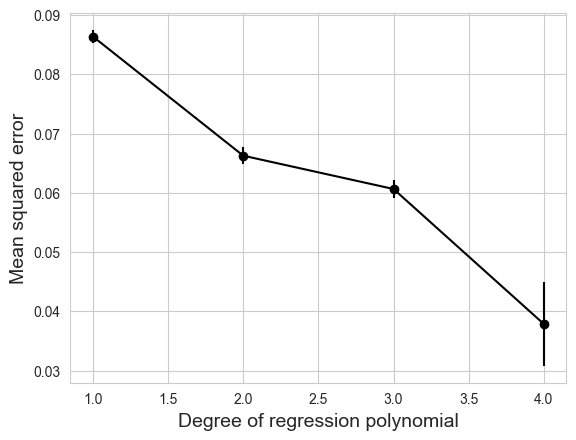

In [130]:
#import needed libraries for creating the model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
df['Exploit_Score'] = pd.to_numeric(df['Exploit_Score'], errors='coerce')
df['Impact_Score'] = pd.to_numeric(df['Impact_Score'], errors='coerce')
df = df.dropna(subset=['Impact_Score', 'Exploit_Score', 'Severity']).copy()

X = df[['Exploit_Score', 'Impact_Score']]
y = df['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#defines two lists that will hold the means and standard deviations of each degree model
Xmeans = []
Xstd = []

#the for loop will go through 4 degrees to see which degree has the best performance
for i in range(1, 5):
    features = PolynomialFeatures(degree=i, include_bias=False)
    XPoly = features.fit_transform(X_train)
    polyModel = make_pipeline(features, LinearRegression())
    polyModel.fit(XPoly, y_train)

    #for each version of the model, the cross_validation score is calculated using 10 folds
    poly_score = -cross_val_score(
    polyModel, X_train, y_train, scoring='neg_mean_squared_error', cv = 10)

    Xmeans.append(np.mean(poly_score))
    Xstd.append(np.std(poly_score))

#defines the error bar graph to show the error rate for each model
plt.errorbar(x=range(1, 5), y=Xmeans, yerr=Xstd, marker='o', color='black')
plt.xlabel('Degree of regression polynomial', fontsize=14)
plt.ylabel('Mean squared error', fontsize=14)

The error rate for each model is seen above in the error graph. With each degree, the mean squared error for each model actually decreases, meaning that with each degree, the error rate of the model's actually improves. As the model uses a different degree between 1 and 4, the mean squared error decreases. When looking at each of the four degrees, it seems that degree 3 is the best fit. The mean error for cubic regression is at 0.06 and the variation is minimal, therefore this model will likely be the best fit. However, degree 4 does have a lower mean squared error, however, the variation is much bigger than with degree 3, meaning while the error rate is lower the standard deviation may still be unpredictable.

While this error graph only uses 4 degrees, any attempt to go beyond four degrees causes issues with the code. Therefore its inpractical to test beyond four degrees. However, based on the graph above using three degrees may be the most practical for giving the smallest error.

## Conclusions

From this section we analyzed the linear and logistic regression models that were made previously using the error functions, cross validation, bootstrap error, and one standard error. It was conculded that:
- the linear model that only used direct features to calculate severity overall had less error rates than a linear model that did not use direct features
- the logistic model performed perfectly and was able to make a good boundary of the severities from low to medium or higher
- The cross validation and bootstrap model were unable to improve the error rate of the linear model not using impact and exploit score meaning that model is not the best option for severity prediction
- When applying the one standard error on the linear model using impact and exploit score, degree 3 was able to give the smallest mean squared error while giving the minimal values for the standard deviation

# Learning

This section will utilize algorithms of supervised or un supervised learning. These algorithms will be used on the Operating system severity to show more detailed categorization of severities for operating system CVEs and see if supervised or unsupervised learning will work better for the severity than through using regression models.

So far we have been using Regression models to predict the severity of an operating system CVE. However, there have been limitations with both linear and logistic regression

Linear was great for showing the connections between the features, however Linear regression was more focused on showing that relationship rather than classifying the CVEs

Logistic regression was great at showing a split of the data and making the actual decision boundaries that is used in prediction. However Logistic regression is limited to binary decision, and there are three categories for severity, meaning its unable to predict all three categories at once

## Supervised learning

One such supervised learning method that would work well for the prediction of severity is KNN. KNN will compare the features of a point's closest neighbors to correctly predict its severity.

Instead of using the direct features (impact and exploit score), a different approach will be taken to see if there are any other way to predict severity.

This model will focus on Operating system related CVEs that have a relationship to a weakness. CWE nodes have a property known as ucocommonConsequences that hold two different pieces of information.
- The scope or scopes of the attack, which list the overall extent of the attack listing all features that were affected
- The impact of the attack, which lists the overall impact by what the attack was able to accomplish

CWE nodes can have multiple impact and scopes listed. The goal of this model was to gather the total amount of scopes and impacts that the CWEs related to a single CVE can cause and if these values can predict the CVE severity. The goal is to see if the amount of these two variables contributes to the severity.

In [131]:
query = """
MATCH (n:UcoexCPE) <-[:UCOEXHASCPE]-(v:UcoCVE)
      <-[:UCOHASCVE_ID]-(UcoVulnerability)
      <-[:UCOHASVULNERABILITY]-(t:UcoExploitTarget)
      -[:UCOHASWEAKNESS]->(w:UcoCWE)
WHERE split(n.cpeName, ':')[2] = 'o'
  AND v.ucobaseSeverity <> ''
WITH DISTINCT v, w
UNWIND w.ucocommonConsequences AS consequence

WITH v, w,
     replace(replace(consequence, '"', ''), ' ', '') AS clean,
     [
       'Confidentiality','AccessControl','Authorization',
       'Availability','Integrity','Accountability',
       'Authentization','Other'
     ] AS scopeValues,
     [
       'VariesbyContext','GainPrivilegesorAssumeIdentity','BypassProtectionMechanism','ReadApplicationData',
       'Other','DoS:ResourceConsumption(Memory)','DoS:ResourceConsumption(CPU)',
       'DoS:Crash,Exit,orRestart','ExecuteUnauthorizedCodeorCommands', 'ReadMemory', 'ReadFilesorDirectories',
       'ModifyFilesorDirectories', 'HideActivities'
     ] AS impactValues

WITH v, w, scopeValues, impactValues, clean,
     split(split(clean, 'Scope:[')[1], ']')[0] AS rawScope,
     split(split(clean, 'Impact:[')[1], ']')[0] AS rawImpact

UNWIND split(rawScope, ',') AS scope
UNWIND split(rawImpact, ',') AS impact

WITH v, w, scopeValues, impactValues,
     trim(scope) AS scope,
     trim(impact) AS impact

RETURN
  v.label AS CVE,
  v.ucobaseSeverity as Severity,
  COUNT(CASE WHEN scope IN scopeValues THEN 1 END) AS scope_count,
  COUNT(CASE WHEN impact IN impactValues THEN 1 END) AS impact_count;
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,CVE,Severity,scope_count,impact_count
0,CVE-2021-45487,MEDIUM,4,4
1,CVE-2021-45488,MEDIUM,4,4
2,CVE-2017-1000378,HIGH,12,4
3,CVE-2017-1000375,HIGH,6,3
4,CVE-2011-1920,LOW,9,9
...,...,...,...,...
21196,CVE-2025-9781,HIGH,12,6
21197,CVE-2025-9782,HIGH,12,6
21198,CVE-2025-9783,HIGH,12,6
21199,CVE-2025-9779,HIGH,12,6


From here we can once again split the data into features and target
The data will be split into training and test sets and then placed into a KNN model

The main issue there is is deciding how many neighbors the algorithm needs to use in order to be most efficient. Using to many will result in overfitting while using to little can cause error. 

Because of this issue, there will be a for loop that will check for all K neighbors from 1 to 11 to find the most efficient one. Note that even values for k will be skipped due to even numbers often resulting in ties and error

In [132]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
X = df[['scope_count', 'impact_count']]
y = df['Severity']

#split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

k_value = []
accuracy = []

#begin a for loop that will be used to define the best value for k
for k in range(1, 12, 2):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    predict = knn.predict(X_test)
    acc = accuracy_score(y_test, predict)
    print('Accuracy for k = ', k, ':', acc)

    k_value.append(k)
    accuracy.append(acc)

Accuracy for k =  1 : 0.4851438453073416
Accuracy for k =  3 : 0.5025939317717341
Accuracy for k =  5 : 0.5678352460304984
Accuracy for k =  7 : 0.5668919981135042
Accuracy for k =  9 : 0.5676780380443327
Accuracy for k =  11 : 0.5676780380443327


Here we can see the accuracys for k values 1 through 11. Even values were skipped due to their frequency to cause ties and unexpected errors. These accuracies can be further visualized in a graph were we can see which value best fits the model

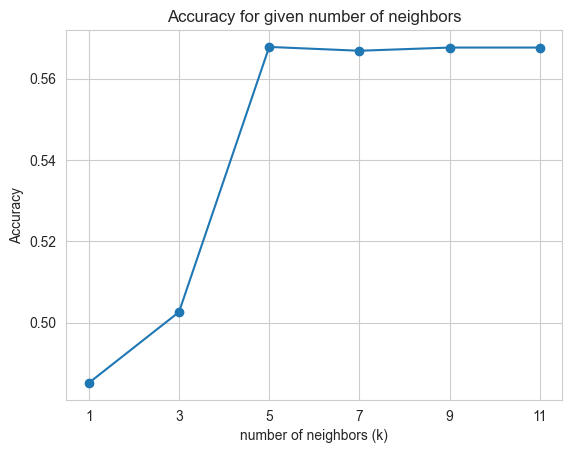

In [133]:
plt.plot(k_value, accuracy, marker = 'o')
plt.title('Accuracy for given number of neighbors')
plt.xlabel('number of neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_value)
plt.grid(True)

The optimal k to use would be when the graph forms an elbow shape. This occurs when the algorithm has around 7 neighbors.

The accuracies vary greatly, with the accuracy remaining around 57% at its highest. However, which k value is the best to pick.

Neighbors 1 and 3 are not an option. This is because these values are underfits for the model and using 1 or 3 neighbors does not give enough information for a model to make an accurate decision. Therefore, the model will need more neighbors

Neighbors 5, 7, 9, and 11 do seem like good fits. However tarting from 7 onward the accuracy levels out. What this means is that any values beyond 5 neighbors are likely overfits and use too much information, missing important patterns. Therefore using any neighbor count beyond 7 is not a good choice.

Having a neighbor count of 5 seems to be the best fit for the model. Having 5 neighbors gave the model the most accuracy without being an overfit. Therefore, the model will now be graphed with 5 neighbors.

The code cell below creates the model with 5 neighbors and places the results of the test set in a scatterplot

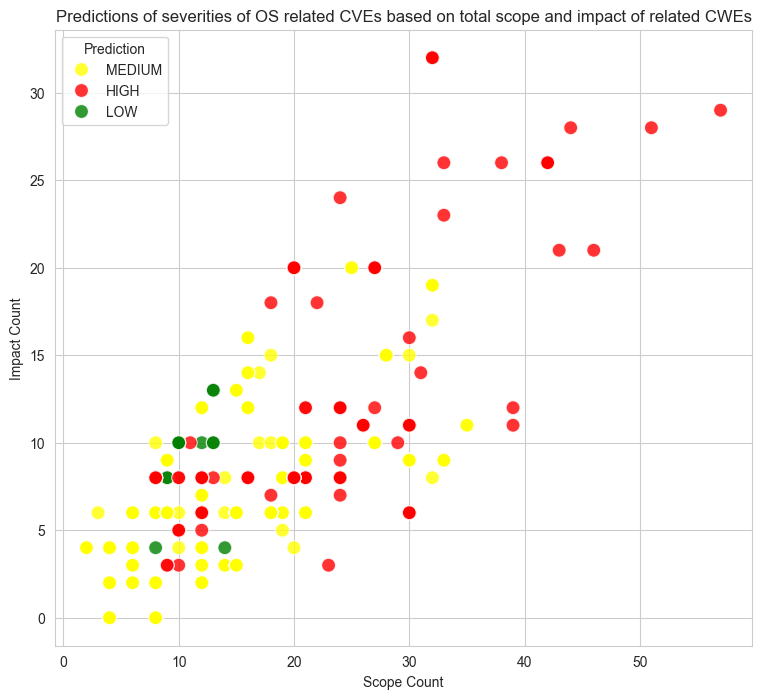

In [135]:
#the knn model is trained again, this time with a set value of 7
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
predict = knn.predict(X_test)

colors=['Yellow', 'Red', 'Green']

# makes a copy of the test data and holds the predicted values
df_test = X_test.copy()
df_test['Prediction'] = predict

#the scatter plot of the knn model is graphed
plt.figure(figsize=(9, 8))
sb.scatterplot(x='scope_count', y='impact_count', hue='Prediction', data=df_test, palette=colors, s=100, alpha=0.8)
plt.xlabel('Scope Count')
plt.ylabel('Impact Count')
plt.title('Predictions of severities of OS related CVEs based on total scope and impact of related CWEs')
plt.show()

The graph above seems to be a bit of a mix, however some notable patterns can be seen. For one very few CVEs were labeled as a low severity. When they were, their total counts for scope and impact were very low. This shows that operating system CVEs that are related to weaknesses are very unlikely to be given a low severity and usually are capable of causing more damage.

Meanwhile Severities Medium and High were a bit more of a mix up. Most scope counts for CVes fell in between 0 and 30 while Impact count fell between 0 and 15. WHen viewing points outside of this range, the points were more likely to be ranked HIGH. However, within the range, while the majority of CVEs were ranked as MEDIUM, there were cases of CVEs being ranked HIGH. This is likely where the accuracy decreases, as there doesnt seem to be a clear boundary between the classes. However the graph does show that:
- CVEs predicted as MEDIUM usually were located rather close together, especially in the stated range.
- CVEs predicted as HIGH were more spread out, but were more likely to have much higher scope and impact counts.

Overall, this KNN algorithm performed decently, but was prone to error when the point fell into a scope range between 0 and 30 and an impact range of 0 and 15. The model was able to show some patterns, but was not able to make fully clear boundaries between the classes.

## Unsupervised Learning

Unsupervised learning will allow the model to make patterns on its own without showing the model what exactly it needs to do. In this section, the previous model created with supervised learning will be recreated here using unsupervised learning.

The best possible method that can be used is K clusters. This method will allow the model to make its own grouping of the classes without being limited to observation a limited number of neighbors.

Firstly, the data is gathered again

In [136]:
query = """
MATCH (n:UcoexCPE) <-[:UCOEXHASCPE]-(v:UcoCVE)
      <-[:UCOHASCVE_ID]-(UcoVulnerability)
      <-[:UCOHASVULNERABILITY]-(t:UcoExploitTarget)
      -[:UCOHASWEAKNESS]->(w:UcoCWE)
WHERE split(n.cpeName, ':')[2] = 'o'
  AND v.ucobaseSeverity <> ''
WITH DISTINCT v, w
UNWIND w.ucocommonConsequences AS consequence

WITH v, w,
     replace(replace(consequence, '"', ''), ' ', '') AS clean,
     [
       'Confidentiality','AccessControl','Authorization',
       'Availability','Integrity','Accountability',
       'Authentization','Other'
     ] AS scopeValues,
     [
       'VariesbyContext','GainPrivilegesorAssumeIdentity','BypassProtectionMechanism','ReadApplicationData',
       'Other','DoS:ResourceConsumption(Memory)','DoS:ResourceConsumption(CPU)',
       'DoS:Crash,Exit,orRestart','ExecuteUnauthorizedCodeorCommands', 'ReadMemory', 'ReadFilesorDirectories',
       'ModifyFilesorDirectories', 'HideActivities'
     ] AS impactValues

WITH v, w, scopeValues, impactValues, clean,
     split(split(clean, 'Scope:[')[1], ']')[0] AS rawScope,
     split(split(clean, 'Impact:[')[1], ']')[0] AS rawImpact

UNWIND split(rawScope, ',') AS scope
UNWIND split(rawImpact, ',') AS impact

WITH v, w, scopeValues, impactValues,
     trim(scope) AS scope,
     trim(impact) AS impact

RETURN
  v.label AS CVE,
  CASE
    WHEN v.ucobaseSeverity = 'MEDIUM' THEN 1
    WHEN v.ucobaseSeverity = 'HIGH' THEN 2
    ELSE 0
  END AS Severity,
  COUNT(CASE WHEN scope IN scopeValues THEN 1 END) AS scope_count,
  COUNT(CASE WHEN impact IN impactValues THEN 1 END) AS impact_count;
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)

#drop the CVE column as the unique ID will not be needed
df = df.drop(columns=['CVE'])
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Severity,scope_count,impact_count
0,1,4,4
1,1,4,4
2,2,12,4
3,2,6,3
4,0,9,9
...,...,...,...
21196,2,12,6
21197,2,12,6
21198,2,12,6
21199,2,12,6


With the data gathered that holds the scope and impact counts of operating system CVEs related to weaknesses, the model can now be created

There will be 3 clusters, one for each severity. The goal is to see:
- if the model using unsupervised learning is more accurate than with supervised learning
- if the boundaries for the classes are different than with a supervised algorithm

With the model we will test the accuracy first before creating the scatter plot

In [138]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

knModel = KMeans(n_clusters = 3, random_state=42)
knModel = knModel.fit(df)
label = knModel.labels_
silhouette_avg = silhouette_score(df, label)
silhouette_avg

0.6789400656729503

Earlier with supervised learning, the K neighbors model obtained an accuracy of 57%. With clustering however, the accuracy is much better at a 67%. Overall the accuracy was much better with an unsupervised learning method than with a supervised one as the k cluster model was able to do better at predicting CVEs. 

The cell below plots the scatter plot with the predictions and the made clusters

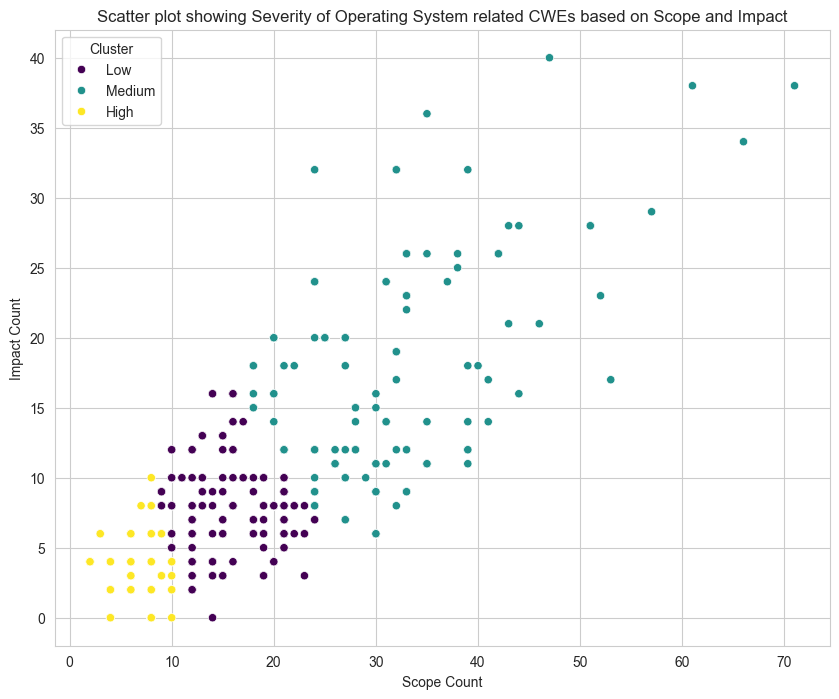

In [139]:
#create the predictions of the cluster model and plot the values in the scatter plot
cluster = knModel.fit_predict(df[['scope_count', 'impact_count']])
plt.figure(figsize=(10, 8))
ax = sb.scatterplot(data=df, x='scope_count', y='impact_count', hue=cluster, palette='viridis')
plt.ylabel('Impact Count')
plt.xlabel('Scope Count')
plt.title('Scatter plot showing Severity of Operating System related CWEs based on Scope and Impact')

#creates labels for the colored points
new_labels = ['Low', 'Medium', 'High']
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, new_labels, title='Cluster')

As seen above the groups that were created are much better defined, however the overall location of the severity predictions are different.

Firstly, CVEs in the LOW cluster usually had no more than 10 scopes and 10 impacts. This makes the LOW severity much more defined wheras the KNN model made the points seem like outliers. 

The medium CVEs were placed in between the low and high clusters, the cluster model helped to prevent the overall mix of severities that was seen in the supervised learning algorithm. The HIGH severities were also better defined. 

Overall this graph was able to better show that the more impacts and scopes of weaknesses related to CVEs are present, the more likely the CVE will have a higher severity.

Something interesting that was also discovered is that the actual cluster categories change with the random state. This is because the random state makes three random points the starting centers, and due to this, the starting location for each severity might be in a different spot. However, this random pick of clustering does seem to hurt the overall accuracy.

While this unsupervised model works well, there is another test that can be done. Like weaknesses, attack patterns also contain a property, ucoexConsequence that holds all of the scopes and impacts an attack pattern cause. Following the same pattern with the previous model, a cluster model can be made to see if the total counts of scope and impacts of attack patterns related to operating system CVEs can also predict CVE severities.

In [140]:
#create the query that gathers the attack pattern information
query = """
MATCH (n:UcoexCPE) <-[UCOEXHASCPE]-(v:UcoCVE) <-[UCOHASCVE_ID]-(UcoVulnerability)<-[UCOHASVULNERABILITY]-(t:UcoExploitTarget)-[UCOHASWEAKNESS]->(w:UcoCWE)<-[UCOHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
WITH DISTINCT v, c
UNWIND c.ucoexConsequences AS consequence
WITH v, c, consequence,
     [
       'Confidentiality','Access Control','Authorization',
       'Availability','Integrity','Accountability',
       'Authentization','Other'
     ] AS scopeValues,
     [
       'Modify Data', 'Gain Privileges', 'Read Data', 'Unreliable Execution',
       'Other', 'Bypass Protection Mechanism', 'Alter Execution Logic', 'Hide Activities',
       'Execute Unauthorized Commands'
     ] AS impactValues,
     split(split(consequence, ' - IMPACT:')[0], 'SCOPE:')[1] AS rawScopes,
     split(split(consequence, ' - IMPACT:')[1], ',') AS rawImpacts
UNWIND split(rawScopes, ',') AS scope
WITH v, c, trim(scope) AS scope, rawImpacts, scopeValues, impactValues
UNWIND rawImpacts AS impact
WITH v, c, scope, trim(impact) AS impact, scopeValues, impactValues
RETURN v.label as CVE,
CASE
  WHEN v.ucobaseSeverity = 'MEDIUM' THEN 1
  WHEN v.ucobaseSeverity = 'HIGH' THEN 2
  ELSE 0
  END AS Severity,
       COUNT(CASE WHEN scope IN scopeValues THEN 1 END) AS scope_count,
       COUNT(CASE WHEN impact IN impactValues THEN 1 END) AS impact_count;
"""
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df = df.drop(columns=['CVE'])
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Severity,scope_count,impact_count
0,1,7,7
1,1,7,7
2,2,1,0
3,2,80,79
4,0,28,30
...,...,...,...
27293,2,97,96
27294,2,97,96
27295,2,97,96
27296,2,97,96


With the data for the attack patterns to the CVEs gathered, the cluster model will be created and the accuracy will be tested.

In [141]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

knModel = KMeans(n_clusters = 3, random_state=42)
knModel = knModel.fit(df)
label = knModel.labels_
silhouette_avg = silhouette_score(df, label)
silhouette_avg

0.7235253795850085

This model overall actually performed really well, with an accuracy of 80%. Like the other cluster model the random state also matters. In this case the state was 61, however with states like 42, the accuracy was lower at 72%. So the actual random state that is selected for this model here is important as depending on the points chosen for the centers can greatly affect the overall performance.

The cell below charts the cluster algorithm for attack patterns related to CVEs.

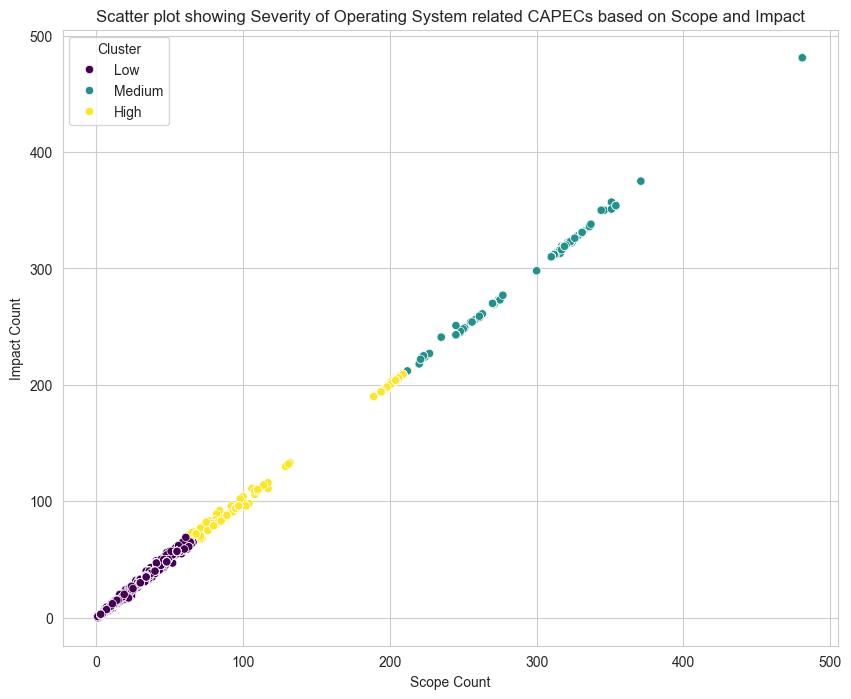

In [142]:
#creates a scatter plot for the cluster model
cluster = knModel.fit_predict(df[['scope_count', 'impact_count']])
plt.figure(figsize=(10, 8))
ax = sb.scatterplot(data=df, x='scope_count', y='impact_count', hue=cluster, palette='viridis')
plt.ylabel('Impact Count')
plt.xlabel('Scope Count')
plt.title('Scatter plot showing Severity of Operating System related CAPECs based on Scope and Impact')

#sets up labels for the target
new_labels = ['Low', 'Medium', 'High']
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, new_labels, title='Cluster')

The clusters and overall structure of the data with CVEs ranked by the total scope and impact of related attack patterns is unusual. The data is structured in a line unlike the previous clustering model, making this model somewhat viable for regression models. However in this case it was able to make accurate groupings:

- The cluster ranked LOW contained the majority of points, with many of the data points not massing the 100 marks for both scope and impact
- There are some jumps in the graph, and the cluster ranked MEDIUM holds the entiretly of the jump. The points labeled as MEDIUM, while near to the LOW cluster, were considered closer to the centeroid of the MEDIUM cluster
- The high cluster is somewhat affected by an outlier located near the 500 markers for both scope and impact count. Its likely that the accuracy of this model is being affected by this outlier and the overall location of this cluster.

Overall, this unsupervised model was accurate, but the structure was unusual. IT does work at predicting CVE severity based on the total scope and impact of related attack patterns, but its likely that this could be used in other models better fitted for the linear structure seen.

## Conclusion

In this section we created models that analyzed OS CVEs that were related to weaknesses and CVEs related to attack patterns. The purpose of these models was to:
- see if the total scope and impact of both weaknesses and attack patterns can predict CVE severity

This section utilized supervised and unsupervised learning by doing the following:
- Creating a K neighbors algorithm predicting CVE severity using total scope and impact from CWEs, proving to be decently accurate but not fully reliable due to the unsteady boundary lines of the classes
- Recreating the same model using a K cluster algorithm that proved to be much more accurate and better define the data's severity
- Create a second cluster model for the total scope and impact of CAPECs and finding that not only was the model more accurate, but the data structure was unusual and may be better for linear models.

Overall, this section helped to show that there are in fact other ways that CVE severity can be predicted without using direct features. It also showed that for predicting Severity, classifier models work much better than regression models.

# Decision Trees

Decision trees are structures that make decisions based on features one at a time in order to decide a class. These can be useful when classifying a specific target using multiple features that can be used in classification.

So far in this project we have been predicting severity of Operating system CVEs. So far we have used regression, supervised, and unsupervised algorithms. One of the more important conclusions that was made was that:
- When using a regression model, exploit and impact score are the direct features used to predict a CVEs severity, and are highly accurate
- when trying to use regression with features not directly related to severity, the models overall perfromed poorly, showing that using indirect features in regression show not be done.

This was concluded with regression, which used numerical features. However, what if we took those indirect features and instead used a decision tree to predict severity? Would using a different model improve the performance?

To refresh, the indirect features that were used previously were as follows:
- ucoObtainAllPrivilege
- ucoUserInteractionRequired
- Relation to CWE
- Relation to CAPEC
- Relation to MITRE Attack

These five features will now be plugged into a decision tree to see if used in a different model, the accuracy will improve.

In [251]:
#grab the required data
query = """
MATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
OPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)
                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)
                 -[r:UCOHASWEAKNESS]->(w:UcoCWE)
                 <-[s:UCOEXHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
                 -[t:UCOEXHASTAXONOMYMAPPING]->(b:UcoexMITREATTACK)
RETURN DISTINCT
    v.label AS CVE, 
    CASE 
        WHEN v.ucoobtainAllPrivilege = 'true' THEN 1 
        ELSE 0 
    END AS Full_Access,
    CASE 
        WHEN v.userInteractionRequired = 'true' THEN 1 
        ELSE 0 
    END AS User_Interaction,
    CASE 
        WHEN w IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_Weakness,
    CASE 
        WHEN c IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_CAPEC,
    CASE
        WHEN b IS NOT NULL THEN 1
        ELSE 0
    END AS Related_to_attack,
    v.ucobaseSeverity as Severity
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: userInteractionRequired)} {position: line: 16, column: 16, offset: 574} for query: "\nMATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)\nWHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''\nOPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)\n                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)\n           

,CVE,Full_Access,User_Interaction,Related_to_Weakness,Related_to_CAPEC,Related_to_attack,Severity
0,CVE-2021-45484,0,0,0,0,0,MEDIUM
1,CVE-2021-45489,0,0,0,0,0,MEDIUM
2,CVE-2021-45487,0,0,1,1,1,MEDIUM
3,CVE-2021-45488,0,0,1,1,1,MEDIUM
4,CVE-2017-1000374,0,0,0,0,0,HIGH
...,...,...,...,...,...,...,...
50193,CVE-2025-9781,0,0,0,0,0,HIGH
50194,CVE-2025-9782,0,0,0,0,0,HIGH
50195,CVE-2025-9783,0,0,0,0,0,HIGH
50196,CVE-2025-9779,0,0,0,0,0,HIGH


Before creating a decision tree, its important to see how much data is being used. Currently, the query above gave 50198 individual data entries. However, they can be grouped to see the severities of each one that are being used.

In [252]:
#show how many entries fall into each of the three classes
df['Severity'].value_counts()

Severity
MEDIUM    25888
HIGH      18129
LOW        6181
Name: count, dtype: int64

As seen above, the majority of entries are listed as MEDIUM. 25,888 data points are classified as MEDIUM. A further 18,129 are classified as HIGH. FInally 6,181 are classified as LOW. Based on this information, it should be concluded that.
- most decisions will likely lead to a MEDIUM or a HIGH

With this information we can see if when using the features a decision tree can make the decisions correctly

In [265]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree, metrics
#define the features and the target
X = df[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'Related_to_attack']] #features
y = df['Severity'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#define the decision tree model
regTree = DecisionTreeClassifier(max_depth = None, random_state=42)
regTree.fit(X_train, y_train)

#export the tree structure to see how it made its decisions
print(export_text(regTree, feature_names=X.columns.to_list()))

#show the accuracy of the decision tree
accuracy = regTree.score(X_test, y_test)
print("Accuracy:", accuracy)

|--- Full_Access <= 0.50
|   |--- Related_to_CAPEC <= 0.50
|   |   |--- class: MEDIUM
|   |--- Related_to_CAPEC >  0.50
|   |   |--- class: MEDIUM
|--- Full_Access >  0.50
|   |--- Related_to_Weakness <= 0.50
|   |   |--- class: HIGH
|   |--- Related_to_Weakness >  0.50
|   |   |--- class: HIGH

Accuracy: 0.5418326693227091


As seen above, there was some good results with the data. 

Firstly as seen above, the tree accuracy was not perfect. The accuracy was only 54%. While this is above the 50% percentile, its still rather now and leaves room for major error in the model. This is overall a vast improvement as with Regression models the accuracy was barely 6%. 

The tree would always only go up to four leaves, making only two decisions. In one instance, Full Access would be used first and then, depending on the previous decision, would choose based on either CAPEC, or Weakness.

These seem to be the features deemed to be the most important to decision making, but we can see which features were used below by comparing feature importance

In [266]:
#see which features are the most important
pd.Series(regTree.feature_importances_, index=X.columns)


Full_Access            0.876903
User_Interaction       0.000000
Related_to_Weakness    0.000127
Related_to_CAPEC       0.122970
Related_to_attack      0.000000
dtype: float64

THe feature importance for each feature is listed below. By far, with this decision tree, the most important feature was Full Access, meaning that whether an attacker could get full access using a vulnerability was the first and most important decision in the tree. Following Full Access, CAPEC relationship had the second highest importance, but with this tree was only used if full access was false.

The important thing to see was that buth user interaction and MITRE attack relationship had a 0 for importance, meaning they were not utilized at all by the tree. This means that removing these features would likely be the best thing to do in this case.

However, this is only one tree. Would it be possible for accuracy to improve if mutliple trees were used? Woult previously unused features also be used? To test this a forest can be made to make a collection of trees. In this forest, 10 trees will be made to allow for possible different makeups of the tree

In [267]:
from sklearn.ensemble import RandomForestClassifier

#recreate the model, but instead use a forest classifier with 10 trees
rf = RandomForestClassifier(n_estimators = 10)
rf.fit(X_train, y_train)

#check the accuracy of the trees
accuracy = rf.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.5418326693227091


Overall ,the accuracy remains the same, however what can be compared is the feature importance to see if it changed.

In [ ]:
#recheck feature importance, this time with the forest
pd.Series(rf.feature_importances_, index=X.columns)

Full_Access            0.848104
User_Interaction       0.000000
Related_to_Weakness    0.047700
Related_to_CAPEC       0.042167
Related_to_attack      0.062029
dtype: float64

As seen above, the feature importance is different now. Full access was still considered the most important in the forest. However there was some differences compared to the singular decision tree.

Firstly, Relationship to MITRE attack had higher importance value than just a 0. CAPEC and Weakness relationships still had values but they were different than before, but still considered important.

THe one thing that didn't change was that User Interaction was never considered important. This means that this feature was never used in any of the forest trees. 

Its important to see what exactly some of the trees looked like to see:
- where error might be made
- how each tree will be making its decisions differently

3 of the 10 trees were graphed to compare their differences and similarities and see why there might be error

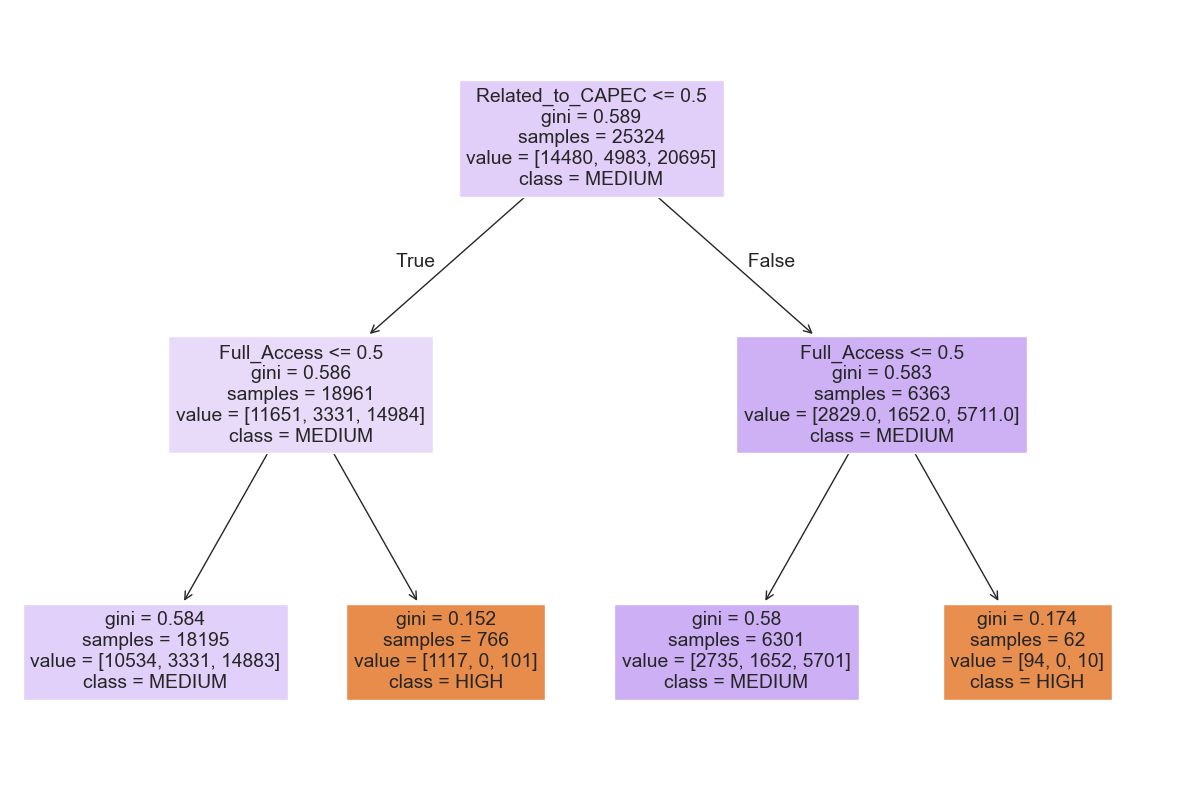

In [ ]:
from sklearn.tree import plot_tree

#graphing tree 1 of the forest
plt.figure(figsize=(15, 10))
plot_tree(rf[1], feature_names=X.columns, class_names = rf.classes_, filled=True)
plt.show()

With tree 1, the tree first made a decision on Attack Pattern relationship, whether the CVE had a relationship to CAPEC or not, it then used Full_Access to decide the severity. With all four leaves, whenever Full Access was false, the severity was listed as HIGH. When Full Access was listed as True, the severity was MEDIUM.

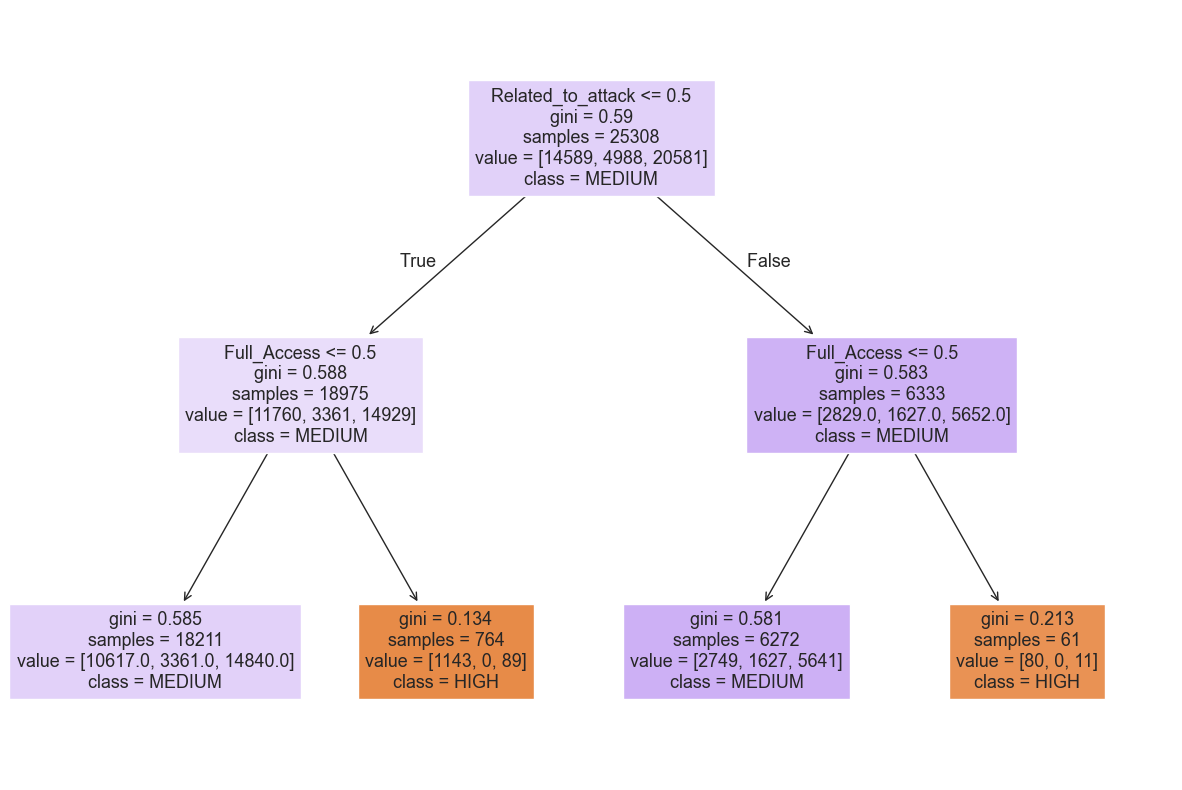

In [ ]:
#graphing tree 2 of the forest
plt.figure(figsize=(15, 10))
plot_tree(rf[2], feature_names=X.columns, class_names=rf.classes_, filled=True)
plt.show()

Tree 2 was relatively similar to tree 1. Tree 2 first made a decision based on the CVEs relationship to MITRE attack nodes. Whether one existed or not, the next decision made was on Full Access. Whenever Full access was false, the Severity was predicted to be HIGH. When full access was true, severity was predicted as MEDIUM. THis tree is pretty much the same as tree 1, with just the difference of what feature the first decision used.

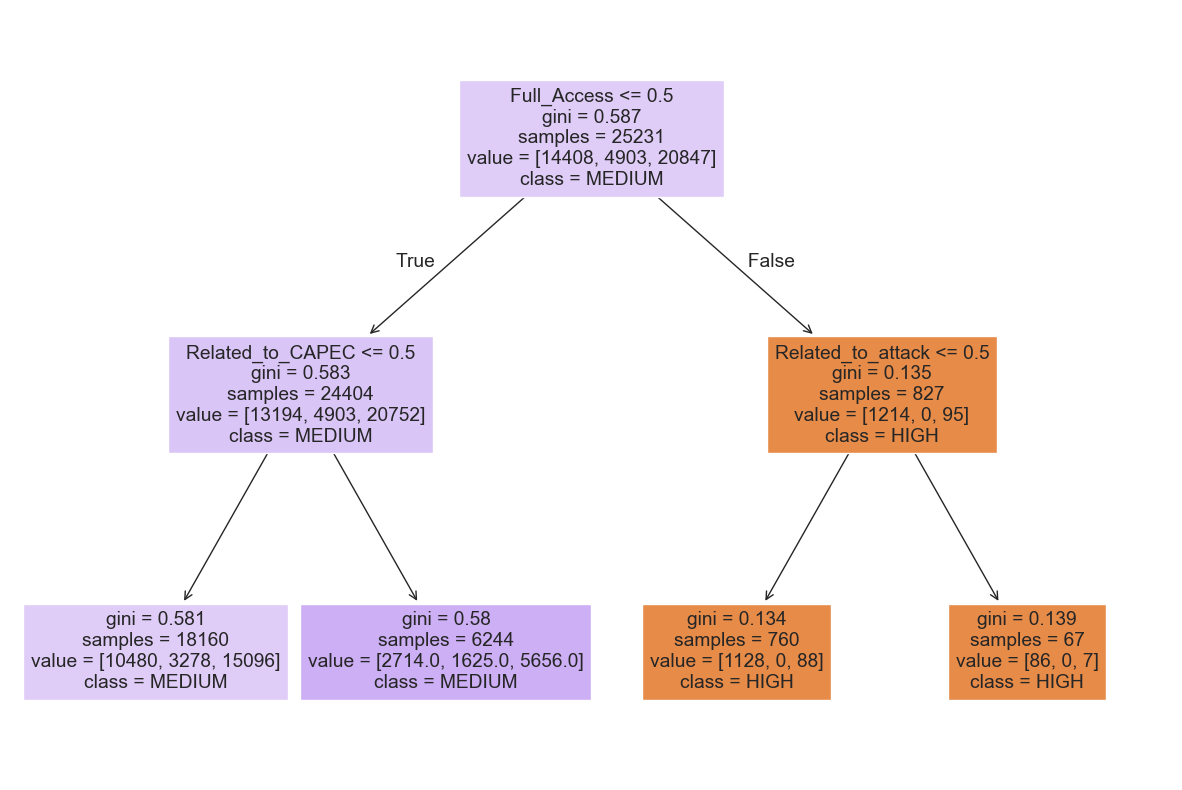

In [ ]:
#graphing tree 3 of the forest
plt.figure(figsize=(15, 10))
plot_tree(rf[3], feature_names=X.columns, class_names=rf.classes_, filled=True)
plt.show()

Tree 3 looks different compared to the others. Full Access is used to make the first decision. When Full Access was True, the next decision was based on CAPEC relationship. When Full Access was False, the next decision was made based on MITRE Attack relationship. The second decision didnt really matter, as whenever full access was True, Severity was predicted to be MEDIUM. When full access was False, the severity was predicted to be HIGH.

Based on these three trees, we can conclude the rest of the forest holds similar results. Clearly Full Access is the feature that provides the most information regarding a decision in a decision tree. However, none of the trees never predicted LOW once, which likely holds a portion of the error rate.

## Decision tree adjustments

So far we have concluded two things when using a decision tree and a forest
- user interaction was considered useless in a decision tree as it was never used
- none of the trees ever predicted LOW

THese conclusions bring a few questions.
- Would accuracy improve if the data points marked as LOW were removed?
- Would accuracy improve if the feature user_interaction was disregarded?

These two tests can be done on a single decision tree as they are simply tests to improve model performance. 
Firstly lets start with removing user_interaction from the dataset

In [271]:
#redefine the features and target, this time with user_interaction removed
X = df[['Full_Access', 'Related_to_Weakness', 'Related_to_CAPEC', 'Related_to_attack']] #features
y = df['Severity'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#define the decision tree model
regTree = DecisionTreeClassifier(max_depth = None, random_state=42)
regTree.fit(X_train, y_train)

#export the tree structure to see how it made its decisions
print(export_text(regTree, feature_names=X.columns.to_list()))

#show the accuracy of the decision tree
accuracy = regTree.score(X_test, y_test)
print("Accuracy:", accuracy)

|--- Full_Access <= 0.50
|   |--- Related_to_Weakness <= 0.50
|   |   |--- class: MEDIUM
|   |--- Related_to_Weakness >  0.50
|   |   |--- class: MEDIUM
|--- Full_Access >  0.50
|   |--- Related_to_attack <= 0.50
|   |   |--- class: HIGH
|   |--- Related_to_attack >  0.50
|   |   |--- class: HIGH

Accuracy: 0.5418326693227091


As seen above the accuracy was still at a 54%. Removing User_interaction from the dataset had no affect on the overall performance. This is because since the feature was never utilized, the model's training and testing didnt change.

Next we can test what would happen if all CVEs listed as LOW were removed

In [ ]:
#grab the required data, this time disregarding all data points classified as LOW
query = """
MATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> '' AND v.ucobaseSeverity <> 'LOW'
OPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)
                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)
                 -[r:UCOHASWEAKNESS]->(w:UcoCWE)
                 <-[s:UCOEXHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
                 -[t:UCOEXHASTAXONOMYMAPPING]->(b:UcoexMITREATTACK)
RETURN DISTINCT
    v.label AS CVE, 
    CASE 
        WHEN v.ucoobtainAllPrivilege = 'true' THEN 1 
        ELSE 0 
    END AS Full_Access,
    CASE 
        WHEN v.userInteractionRequired = 'true' THEN 1 
        ELSE 0 
    END AS User_Interaction,
    CASE 
        WHEN w IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_Weakness,
    CASE 
        WHEN c IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_CAPEC,
    CASE
        WHEN b IS NOT NULL THEN 1
        ELSE 0
    END AS Related_to_attack,
    v.ucobaseSeverity as Severity
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: userInteractionRequired)} {position: line: 16, column: 16, offset: 605} for query: "\nMATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)\nWHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> '' AND v.ucobaseSeverity <> 'LOW'\nOPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)\n                 <-[UCOHASVULNERABILITY]-(e

,CVE,Full_Access,User_Interaction,Related_to_Weakness,Related_to_CAPEC,Related_to_attack,Severity
0,CVE-2021-45484,0,0,0,0,0,MEDIUM
1,CVE-2021-45489,0,0,0,0,0,MEDIUM
2,CVE-2021-45487,0,0,1,1,1,MEDIUM
3,CVE-2021-45488,0,0,1,1,1,MEDIUM
4,CVE-2017-1000374,0,0,0,0,0,HIGH
...,...,...,...,...,...,...,...
44012,CVE-2025-9781,0,0,0,0,0,HIGH
44013,CVE-2025-9782,0,0,0,0,0,HIGH
44014,CVE-2025-9783,0,0,0,0,0,HIGH
44015,CVE-2025-9779,0,0,0,0,0,HIGH


This action takes out 7 thousand data points. Now we will see if the decision tree improves

In [ ]:
#redefine the features and target
X = df[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'Related_to_attack']] #features
y = df['Severity'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#define the decision tree model
regTree = DecisionTreeClassifier(max_depth = None, random_state=42)
regTree.fit(X_train, y_train)

#export the tree structure to see how it made its decisions
print(export_text(regTree, feature_names=X.columns.to_list()))

#show the accuracy of the decision tree
accuracy = regTree.score(X_test, y_test)
print("Accuracy:", accuracy)

|--- Full_Access <= 0.50
|   |--- Related_to_CAPEC <= 0.50
|   |   |--- class: MEDIUM
|   |--- Related_to_CAPEC >  0.50
|   |   |--- class: MEDIUM
|--- Full_Access >  0.50
|   |--- Related_to_Weakness <= 0.50
|   |   |--- class: HIGH
|   |--- Related_to_Weakness >  0.50
|   |   |--- class: HIGH

Accuracy: 0.6257383007723762


As seen above, the accuracy actually improved from a 54% to a 62%. This means the tree was much more accurate without including the datapoints listed as LOW. Further more, this means that when the decision tree was given two classes instead of three, the accuracy was better.

However, that is still seven thousand points disregarded. Would it be better to instead combine them with a different class instead? To test this, the LOW points will be combined with MEDIUM as the class 'NOT HIGH' to signify they are not HIGH severity

In [275]:
#grab the required data, this time combining LOW points with MEDIUM points
query = """
MATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)
WHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''
OPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)
                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)
                 -[r:UCOHASWEAKNESS]->(w:UcoCWE)
                 <-[s:UCOEXHASRELATEDWEAKNESS]-(c:UcoexCAPEC)
                 -[t:UCOEXHASTAXONOMYMAPPING]->(b:UcoexMITREATTACK)
RETURN DISTINCT
    v.label AS CVE, 
    CASE 
        WHEN v.ucoobtainAllPrivilege = 'true' THEN 1 
        ELSE 0 
    END AS Full_Access,
    CASE 
        WHEN v.userInteractionRequired = 'true' THEN 1 
        ELSE 0 
    END AS User_Interaction,
    CASE 
        WHEN w IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_Weakness,
    CASE 
        WHEN c IS NOT NULL THEN 1 
        ELSE 0 
    END AS Related_to_CAPEC,
    CASE
        WHEN b IS NOT NULL THEN 1
        ELSE 0
    END AS Related_to_attack,
    CASE
        WHEN v.ucobaseSeverity = 'HIGH' THEN 'HIGH'
        ELSE 'NOT HIGH'
    END AS Severity
"""

params = {}
count = run_query(query, parameters=params)

#creates a dataframe to output the results
df = pd.DataFrame(count)
df

C:\Users\peyto\AppData\Local\Temp\ipykernel_36436\4091205277.py:24: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: userInteractionRequired)} {position: line: 16, column: 16, offset: 574} for query: "\nMATCH (n:UcoexCPE)<-[UCOEXHASCPE]-(v:UcoCVE)\nWHERE split(n.cpeName, ':')[2] = 'o' AND v.ucobaseSeverity <> ''\nOPTIONAL MATCH (v)<-[UCOHASCVE_ID]-(y:UcoVulnerability)\n                 <-[UCOHASVULNERABILITY]-(e:UcoExploitTarget)\n           

,CVE,Full_Access,User_Interaction,Related_to_Weakness,Related_to_CAPEC,Related_to_attack,Severity
0,CVE-2021-45484,0,0,0,0,0,NOT HIGH
1,CVE-2021-45489,0,0,0,0,0,NOT HIGH
2,CVE-2021-45487,0,0,1,1,1,NOT HIGH
3,CVE-2021-45488,0,0,1,1,1,NOT HIGH
4,CVE-2017-1000374,0,0,0,0,0,HIGH
...,...,...,...,...,...,...,...
50193,CVE-2025-9781,0,0,0,0,0,HIGH
50194,CVE-2025-9782,0,0,0,0,0,HIGH
50195,CVE-2025-9783,0,0,0,0,0,HIGH
50196,CVE-2025-9779,0,0,0,0,0,HIGH


Now that LOW and MEDIUM points have been combined, we can test the decision tree again

In [276]:
#redefine the features and target
X = df[['Full_Access', 'User_Interaction', 'Related_to_Weakness', 'Related_to_CAPEC', 'Related_to_attack']] #features
y = df['Severity'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#define the decision tree model
regTree = DecisionTreeClassifier(max_depth = None, random_state=42)
regTree.fit(X_train, y_train)

#export the tree structure to see how it made its decisions
print(export_text(regTree, feature_names=X.columns.to_list()))

#show the accuracy of the decision tree
accuracy = regTree.score(X_test, y_test)
print("Accuracy:", accuracy)

|--- Full_Access <= 0.50
|   |--- Related_to_CAPEC <= 0.50
|   |   |--- class: NOT HIGH
|   |--- Related_to_CAPEC >  0.50
|   |   |--- class: NOT HIGH
|--- Full_Access >  0.50
|   |--- Related_to_Weakness <= 0.50
|   |   |--- class: HIGH
|   |--- Related_to_Weakness >  0.50
|   |   |--- class: HIGH

Accuracy: 0.6667330677290837


Surprisingly, the accuracy was better than when the LOW class data was removed. The accuracy was at a 67% which is higher than when the LOW class was removed, which was at a 62%. This means that the model performed better when all data classified as LOW was combined with a different class instead of removed.

## Conclusion
Overall, Using decision trees were shown to be much better at predicting severity without using severities direct features, which was a vast improvement compared to regression models. Decision trees showed that:
- A normal tree, while prone to error, performed much better than a regression model with the same data
- Full Access was considered the most important feature, with feature importance varying for the remaining features except User Interaction
- A random forest showed that full access, even when not the first decision, still held the most importance when classifying points.
- User Interaction was never used in both a single decision tree and a random forest. However, removing this feature held no consequence due to its lack of use
- Removing all data points classified as LOW helped to improve model performance, however it was that seen that it was better to instead combine two of the three classes instead of removing one as accuracy was better overall.

Overall, this section helped to improve a prediction set using previous data from a regression model and reapplying it into a different model showing that indirect features can predict severity, but the features work better in classification and decision models.

# Conclusion

This section will summarize all of the work done in each of the previous sections and state all important findings

## Exploration

Exploration allowed me to fully investigate the questions presented at the beginning of the project about operating systems. From using different types of graphs to investigate each dataset separated and together, the following results were shown:
- From using the label property in CVEs to see what year the vulnerability was reported, it was shown that Operating System CVEs have seen a rapid increase in modern years since 2017 
- When observing the severity of vulnerabilities, Most OS CVEs ranked Medium or higher in severity, meaning they were often serious in damage and danger
- The Impact and Exploit score contribute greatly to the severity score, and specific scores were more related to specific severities. These scores were analyzed in a varierty of different graphs to further visualize this relationship and the overall layout of the score's data.
- Most OS vulnerabilities did not allow for full administrator access or required user interaction, so while they couldn't obtain full control they did not need to trick the user to carry out the exploit. A heat map was able to fully visualize ths majority
- Most OS Vulnerabilities were related to both weaknesses and attack patterns, meaning there were other factors in play to the vulnerability. A heat map also showed that no OS CVE could be related to a CAPEC without having a prior relationship to a weakness based on the graphs structure.
- Most weaknesses attributed to OS vulnerabilities were not specific to one application but contained documentation. This documentation mainly explained what the weakness was.
- Most attack patterns related to OS vulnerabilities were easy to execute, highly likely to occur, and were often considered severe. This was seen by analyzing the properties of CAPECs that were related to OS CVEs.

Seeing these features that have been derived, conclusions can be made that 
- Operating system vulnerabilities have been increasing
- They contain characteristics that make them highly dangerous, including a high vulnerability severity along with relationships to weaknesses and attack patterns, which also contain severe properties
- There are trends seen that OS vulnerabilities are highly related to weaknesses and attack patterns. The high relationship counts was able to show this connection.

Exploration helped to show the answers to the questions, and current trends with Operating system vulnerabilities.

## Regression

When using Regression, it became clear that regression was not the ideal model to be utilized for this data, however there were some usage it had.
- Exploit and Impact scores were the direct features related to the CVEs severity. Linear regression, while not exactly linear due to data layout, was highly accurate at predicting severity to be MEDIUM or higher.
- This was also able to be utilized in a 2d and 3d fashion.
- attempts to include other features, including full access, user interaction, and more were unable to be seen as more important than exploit and impact score
- Logistic Regression also showed the following boundary line where:
-- The higher the Exploit score, the lower Impact score can be for a higher severity
-- the lower the exploit score, the higher impact needs to be to be a high severity

Overall, while Regression was clearly not the best choice, it help to better show what features were tied to severity and how it could be utilized to predict severity.

## Comparing Models

This section was used to show the regression model's improvements and if it was possible to make a model that did not use exploit or impact score.
- the linear model that only used direct features to calculate severity overall had less error rates than a linear model that did not use direct features
- the logistic model performed perfectly and was able to make a good boundary of the severities from low to medium or higher
- The cross validation and bootstrap model were unable to improve the error rate of the linear model not using impact and exploit score meaning that model is not the best option for severity prediction. Cross model validation used multiple amounts of folds, but it failed to improve performance.
- When applying the one standard error on the linear model using impact and exploit score, degree 3 was able to give the smallest mean squared error while giving the minimal values for the standard deviation. This shows the ideal degree to use the model with.

This helped to show that using only indirect features to the OS CVE severity in a Regression model would not work and only lead to a poorly performing model, but also showed how to obtain the most ideal Regression model just using Exploit and Impact Score.

## Un/Supervised Learning

This section was switching from Regression to Classification models. Both KNN models and K Cluster models were utilized. The models used different data to see if there were other ways to predict severity differently as they did still require numerical features. The following was concluded:
- Creating a K neighbors algorithm predicting CVE severity using total scope and impact from CWEs proved to be decently accurate but not fully reliable due to the unsteady boundary lines of the classes
- Recreating the same model using a K cluster algorithm that proved to be much more accurate and better define the data's severity
- Create a second cluster model for the total scope and impact of CAPECs and finding that not only was the model more accurate, but the data structure was unusual and may be better for linear models.

Overall it showed that unsupervised classification models work much better on the dataset than regression models and would be considered more ideal. Supervised models did contain decent results but would need to find different ways to be used.

## Decision Trees

Finally, this section took the conclusion from the Comparing MOdels section and tried to see if it was possible to switch the model to improve performance. The results ended up showing that:
- A normal tree, while prone to error, performed much better than a regression model with the same data
- Full Access was considered the most important feature, with feature importance varying for the remaining features except User Interaction
- A random forest showed that full access, even when not the first decision, still held the most importance when classifying points.
- User Interaction was never used in both a single decision tree and a random forest. However, removing this feature held no consequence due to its lack of use
- Removing all data points classified as LOW helped to improve model performance, however it was that seen that it was better to instead combine two of the three classes instead of removing one as accuracy was better overall.

Overall, this was able to prove that using indirect features to predict OS CVE severity, while having poor performance using Regression, was able to be utilized in a model that performed much more efficiently and accurately, showing that using indirect features is much better suited for classification models.

This analysis of operating system related vulnerabilities have been becoming more severe and that several alarming trends of these vulnerabilities have been observed. It was also observed that several different types of machine learning models can be utilized with the data to predict severities of OS vulnerabilities. While Regression models usually were not well performing, Classification models were able to be both accurate and compare features not fully related to predict severity. This project overall helped to answer all of the questions asked at the start of this project, and also show how models can be used to make future predictions about future operating system vulnerabilities.